# **Customer Churn Prediction**


---

### **Problem Statement**

Customer churn refers to customers who stop using a company's products or services. High customer churn can result in revenue loss, reduced customer lifetime value, and increased customer acquisition costs.

The objective of this project is to analyze historical customer data and identify patterns associated with customer churn. A machine learning classification model will be developed to predict whether a customer is likely to churn or remain with the company.

The project also aims to estimate the probability of churn for each customer, allowing customers to be categorized based on their churn risk.

---

### **Project Objective**

The main objective of this project is to build an accurate and reliable machine learning model for customer churn prediction.

The project aims to:

- Perform data understanding and data quality analysis.
- Explore customer characteristics and identify patterns related to churn.
- Perform data preprocessing and feature engineering.
- Train and compare multiple classification models.
- Evaluate models using metrics such as Accuracy, Precision, Recall, F1-Score, ROC-AUC and PR-AUC.
- Select the most suitable model based on the evaluation results.
- Analyze important features influencing customer churn.
- Use SHAP explainability to understand model predictions.
- Perform threshold analysis to understand the effect of different classification thresholds.
- Generate churn probability and final churn predictions for customers.

---

### **Business Understanding**

Customer retention is important for maintaining stable revenue and reducing the cost of acquiring new customers. Identifying customers who are at a higher risk of leaving can help businesses take preventive actions before churn occurs.

The churn prediction model can support the business by:

- Identifying customers who are likely to churn.
- Estimating the probability of churn for each customer.
- Understanding the key factors associated with customer churn.
- Supporting targeted customer retention campaigns.
- Helping prioritize high-risk customers for retention efforts.
- Reducing potential revenue loss caused by customer churn.
- Supporting data-driven customer relationship management decisions.

The final model is intended to act as a decision-support tool that helps the business identify potential churn risks and take appropriate retention actions.

## 1. Import Libraries

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocessing & pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Model selection
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)

# Feature selection / interpretation
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
import shap

# Persistence
import joblib

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Warnings & display
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

print("Libraries imported successfully.")

c:\Users\Nishanth\anaconda3\envs\sales_lstm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully.


## 2. Load Dataset

In [2]:
df = pd.read_excel("Customer_Churn_Dataset.xlsx")
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Customer_ID,Age,Gender,City,Income_Level,Tenure_Months,Signup_Date,Contract_Type,Plan_Type,Payment_Method,Auto_Renewal_Flag,Usage_Frequency,Days_Since_Last_Activity,Feature_Usage_Count,Avg_Session_Duration_Min,Monthly_Charges,Total_Charges,Discount_Applied_Pct,Late_Payment_Count,Support_Tickets_Raised,Complaint_Count,Avg_Resolution_Time_Hrs,Satisfaction_Score,Referral_Count,Loyalty_Program_Member,Upsell_Downgrade_History,Email_Open_Rate_Pct,Churn_Flag
0,CUST00001,38,Male,Delhi,High,7,2026-01-12,Annual,Basic,UPI,1,28,129,6,9.2,303.99,2053.55,0,2,0,0,0.0,4,0,1,No History,5.9,0
1,CUST00002,32,Other,Pune,High,8,2025-11-27,Annual,Basic,Debit Card,1,19,34,9,8.2,1372.59,10773.22,15,0,1,0,22.9,3,1,1,No History,63.9,0
2,CUST00003,53,Other,Chennai,High,8,2025-11-26,Monthly,Premium,Wallet,1,19,80,14,12.7,1838.57,14237.56,0,0,2,0,18.6,3,1,0,Downgraded,8.2,0
3,CUST00004,49,Female,Pune,Medium,37,2023-07-10,Prepaid,Basic,Wallet,1,13,87,4,1.0,2812.16,100226.58,20,1,2,0,6.5,9,0,0,No History,34.0,0
4,CUST00005,49,Other,Kolkata,Medium,9,2025-10-20,Monthly,Standard,Net Banking,0,0,16,1,8.0,2246.25,19133.49,15,1,2,1,71.5,8,1,1,No History,88.7,1


## 3. Dataset Overview

In [3]:
rows, columns = df.shape
print("Number of rows    :", rows)
print("Number of columns :", columns)
print()
print("Columns:")
for i, c in enumerate(df.columns, start=1):
    print(f"{i:>2}. {c}")

Number of rows    : 3216
Number of columns : 28

Columns:
 1. Customer_ID
 2. Age
 3. Gender
 4. City
 5. Income_Level
 6. Tenure_Months
 7. Signup_Date
 8. Contract_Type
 9. Plan_Type
10. Payment_Method
11. Auto_Renewal_Flag
12. Usage_Frequency
13. Days_Since_Last_Activity
14. Feature_Usage_Count
15. Avg_Session_Duration_Min
16. Monthly_Charges
17. Total_Charges
18. Discount_Applied_Pct
19. Late_Payment_Count
20. Support_Tickets_Raised
21. Complaint_Count
22. Avg_Resolution_Time_Hrs
23. Satisfaction_Score
24. Referral_Count
25. Loyalty_Program_Member
26. Upsell_Downgrade_History
27. Email_Open_Rate_Pct
28. Churn_Flag


## 4. Data Understanding

We inspect structure, data types, and basic statistics before touching the data in any way.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3216 entries, 0 to 3215
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               3216 non-null   str    
 1   Age                       3216 non-null   int64  
 2   Gender                    3216 non-null   str    
 3   City                      3216 non-null   str    
 4   Income_Level              3216 non-null   str    
 5   Tenure_Months             3216 non-null   int64  
 6   Signup_Date               3216 non-null   str    
 7   Contract_Type             3216 non-null   str    
 8   Plan_Type                 3216 non-null   str    
 9   Payment_Method            3216 non-null   str    
 10  Auto_Renewal_Flag         3216 non-null   int64  
 11  Usage_Frequency           3216 non-null   int64  
 12  Days_Since_Last_Activity  3216 non-null   int64  
 13  Feature_Usage_Count       3216 non-null   int64  
 14  Avg_Session_Duratio

In [5]:
df.describe(include=np.number).T

,count,mean,std,min,25%,50%,75%,max
Age,3216.0,43.670087,15.541516,18.000000,31.000000,44.000000,57.000000,70.000000
Tenure_Months,3216.0,36.201493,21.272295,1.000000,18.000000,35.000000,55.000000,72.000000
Auto_Renewal_Flag,3216.0,0.603234,0.489303,0.000000,0.000000,1.000000,1.000000,1.000000
Usage_Frequency,3216.0,13.998756,7.568947,0.000000,9.000000,14.000000,19.000000,40.000000
Days_Since_Last_Activity,3216.0,92.732898,51.468825,0.000000,49.000000,94.000000,136.000000,188.000000
Feature_Usage_Count,3216.0,9.526741,5.964219,0.000000,4.000000,10.000000,15.000000,21.000000
Avg_Session_Duration_Min,3216.0,11.896616,7.134990,1.000000,6.420802,11.700000,16.700000,41.195925
Monthly_Charges,3216.0,1565.058028,791.644984,202.640000,846.287423,1571.794587,2241.345352,2996.614645
Total_Charges,3216.0,56989.671187,47389.533071,234.766967,18730.236976,43321.249698,84809.716659,215756.254465
Discount_Applied_Pct,3216.0,8.067475,7.844412,0.000000,0.000000,7.000000,15.000000,24.000000


In [6]:
df.describe(include="object").T

,count,unique,top,freq
Customer_ID,3216,3216,CUST00001,1
Gender,3216,3,Other,1107
City,3216,7,Bengaluru,557
Income_Level,3216,3,Low,1107
Signup_Date,3216,755,2026-07-25,99
Contract_Type,3216,3,Monthly,1545
Plan_Type,3216,3,Standard,1158
Payment_Method,3216,5,Debit Card,698
Upsell_Downgrade_History,3216,3,No History,1889


## 5. Data Quality Assessment

A single, professional "before cleaning" data-quality summary, covering missing values,
duplicate rows, duplicate IDs, and out-of-domain values for every column. This table is
recomputed **after** cleaning later in the notebook so that the two can be compared directly.

In [7]:
def data_quality_summary(data):
    """Build a per-column data-quality summary table."""
    summary = []
    for col in data.columns:
        s = data[col]
        n_missing = s.isnull().sum()
        n_unique = s.nunique()
        n_duplicates = s.duplicated().sum()
        dtype = str(s.dtype)
        if pd.api.types.is_numeric_dtype(s):
            n_negative = (s < 0).sum()
            min_val, max_val = s.min(), s.max()
        else:
            n_negative = np.nan
            min_val, max_val = np.nan, np.nan
        summary.append({
            "Column": col,
            "Dtype": dtype,
            "Missing": n_missing,
            "Missing_%": round(n_missing / len(data) * 100, 2),
            "Unique": n_unique,
            "Duplicates": n_duplicates,
            "Negative_Values": n_negative,
            "Min": min_val,
            "Max": max_val
        })
    return pd.DataFrame(summary)

quality_before = data_quality_summary(df)
quality_before

,Column,Dtype,Missing,Missing_%,Unique,Duplicates,Negative_Values,Min,Max
0,Customer_ID,str,0,0.0,3216,0,NaN,NaN,NaN
1,Age,int64,0,0.0,53,3163,0.0,18.000000,70.000000
2,Gender,str,0,0.0,3,3213,NaN,NaN,NaN
3,City,str,0,0.0,7,3209,NaN,NaN,NaN
4,Income_Level,str,0,0.0,3,3213,NaN,NaN,NaN
5,Tenure_Months,int64,0,0.0,72,3144,0.0,1.000000,72.000000
6,Signup_Date,str,0,0.0,755,2461,NaN,NaN,NaN
7,Contract_Type,str,0,0.0,3,3213,NaN,NaN,NaN
8,Plan_Type,str,0,0.0,3,3213,NaN,NaN,NaN
9,Payment_Method,str,0,0.0,5,3211,NaN,NaN,NaN


## 6. Data Cleaning

Data cleaning is carried out in stages: missing values, duplicates, data types, domain-range
validation (age, percentages, binary flags), and outlier analysis. Each step reports what was
found **before** deciding whether any correction is warranted — nothing is changed speculatively.

### 6.1 Missing Value Analysis


In [8]:
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage.round(2)
}).sort_values(by="Missing Values", ascending=False)

print("Total missing values in dataset:", df.isnull().sum().sum())
missing_summary

Total missing values in dataset: 0


,Missing Values,Missing Percentage
Customer_ID,0,0.0
Age,0,0.0
Gender,0,0.0
City,0,0.0
Income_Level,0,0.0
Tenure_Months,0,0.0
Signup_Date,0,0.0
Contract_Type,0,0.0
Plan_Type,0,0.0
Payment_Method,0,0.0


### 6.2 Duplicate Analysis

In [9]:
duplicate_rows = df.duplicated().sum()
duplicate_ids = df["Customer_ID"].duplicated().sum()

print("Duplicate full rows      :", duplicate_rows)
print("Duplicate Customer_IDs   :", duplicate_ids)
print("Unique Customer_IDs      :", df["Customer_ID"].nunique(), "/", len(df))

if duplicate_rows == 0 and duplicate_ids == 0:
    print("\nNo duplicate rows or duplicate customer IDs found — no rows need to be dropped.")

Duplicate full rows      : 0
Duplicate Customer_IDs   : 0
Unique Customer_IDs      : 3216 / 3216

No duplicate rows or duplicate customer IDs found — no rows need to be dropped.


### 6.3 Data Type Validation

In [10]:
print(df.dtypes)
print()

# Signup_Date should parse cleanly to datetime
parsed_dates = pd.to_datetime(df["Signup_Date"], errors="coerce")
invalid_dates = parsed_dates.isna().sum()
print("Invalid / unparseable Signup_Date values:", invalid_dates)
print("Signup_Date range:", parsed_dates.min().date(), "to", parsed_dates.max().date())

future_signups = (parsed_dates > pd.Timestamp.today()).sum()
print("Signup dates in the future:", future_signups)

Customer_ID                     str
Age                           int64
Gender                          str
City                            str
Income_Level                    str
Tenure_Months                 int64
Signup_Date                     str
Contract_Type                   str
Plan_Type                       str
Payment_Method                  str
Auto_Renewal_Flag             int64
Usage_Frequency               int64
Days_Since_Last_Activity      int64
Feature_Usage_Count           int64
Avg_Session_Duration_Min    float64
Monthly_Charges             float64
Total_Charges               float64
Discount_Applied_Pct          int64
Late_Payment_Count            int64
Support_Tickets_Raised        int64
Complaint_Count               int64
Avg_Resolution_Time_Hrs     float64
Satisfaction_Score            int64
Referral_Count                int64
Loyalty_Program_Member        int64
Upsell_Downgrade_History        str
Email_Open_Rate_Pct         float64
Churn_Flag                  

### 6.4 Domain / Range Validation

Every categorical column's allowed values, and every numeric column's plausible range, are
checked explicitly.

In [11]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
categorical_columns.remove("Customer_ID")

print("Categorical value sets:")
for col in categorical_columns:
    print(f"\n{col}: {sorted(df[col].unique())}")

Categorical value sets:

Gender: ['Female', 'Male', 'Other']

City: ['Bengaluru', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai', 'Pune']

Income_Level: ['High', 'Low', 'Medium']

Signup_Date: ['2020-08-14', '2020-08-15', '2020-08-16', '2020-08-24', '2020-08-27', '2020-08-29', '2020-08-30', '2020-08-31', '2020-09-03', '2020-09-07', '2020-09-09', '2020-09-10', '2020-09-11', '2020-09-13', '2020-09-15', '2020-09-19', '2020-09-24', '2020-09-27', '2020-09-30', '2020-10-03', '2020-10-06', '2020-10-07', '2020-10-08', '2020-10-09', '2020-10-10', '2020-10-14', '2020-10-18', '2020-10-19', '2020-10-20', '2020-10-21', '2020-10-22', '2020-10-24', '2020-10-29', '2020-11-02', '2020-11-05', '2020-11-08', '2020-11-14', '2020-11-16', '2020-11-22', '2020-11-23', '2020-11-24', '2020-11-27', '2020-11-29', '2020-11-30', '2020-12-02', '2020-12-05', '2020-12-06', '2020-12-07', '2020-12-09', '2020-12-10', '2020-12-11', '2020-12-17', '2020-12-18', '2020-12-22', '2020-12-23', '2020-12-25', '2021-01-02', '2

In [12]:
binary_columns = ["Auto_Renewal_Flag", "Loyalty_Program_Member", "Churn_Flag"]
print("Binary column validation (expect only {0, 1}):")
for col in binary_columns:
    invalid = (~df[col].isin([0, 1])).sum()
    print(f"  {col}: invalid values = {invalid}")

percentage_columns = ["Discount_Applied_Pct", "Email_Open_Rate_Pct"]
print("\nPercentage column validation (expect 0-100):")
for col in percentage_columns:
    out_of_range = ((df[col] < 0) | (df[col] > 100)).sum()
    print(f"  {col}: min={df[col].min()}, max={df[col].max()}, out-of-range={out_of_range}")

print("\nAge validation (plausible adult range, e.g. 18-100):")
invalid_age = ((df["Age"] < 18) | (df["Age"] > 100)).sum()
print(f"  Age: min={df['Age'].min()}, max={df['Age'].max()}, out-of-range={invalid_age}")

print("\nSatisfaction_Score validation (expect 1-10):")
invalid_sat = (~df["Satisfaction_Score"].between(1, 10)).sum()
print(f"  min={df['Satisfaction_Score'].min()}, max={df['Satisfaction_Score'].max()}, invalid={invalid_sat}")

print("\nNegative-value check across all numeric columns:")
num_cols_all = df.select_dtypes(include=np.number).columns
neg_report = {c: int((df[c] < 0).sum()) for c in num_cols_all}
neg_report = {k: v for k, v in neg_report.items() if v > 0}
print("  Columns with negative values:", neg_report if neg_report else "None")

Binary column validation (expect only {0, 1}):
  Auto_Renewal_Flag: invalid values = 0
  Loyalty_Program_Member: invalid values = 0
  Churn_Flag: invalid values = 0

Percentage column validation (expect 0-100):
  Discount_Applied_Pct: min=0, max=24, out-of-range=0
  Email_Open_Rate_Pct: min=0.1, max=99.9, out-of-range=0

Age validation (plausible adult range, e.g. 18-100):
  Age: min=18, max=70, out-of-range=0

Satisfaction_Score validation (expect 1-10):
  min=1, max=10, invalid=0

Negative-value check across all numeric columns:
  Columns with negative values: None


### 6.5 Outlier Analysis

IQR-based outlier detection is applied to every continuous/count numeric column. Each flagged
column is then judged individually: is the extreme value a **plausible customer behavior**
(e.g. a customer with many support tickets) or an **invalid data-entry error** (e.g. a
negative charge, an age of 300)? Only the latter would be corrected — and the domain-range
checks above already found none. Right-skewed count columns such as `Referral_Count`,
`Late_Payment_Count`, `Support_Tickets_Raised`, and `Complaint_Count` are expected to have a
long tail of "IQR outliers" simply because most customers have low counts and a minority have
several — this is genuine behavioral variation, not an error, and is retained because it is
plausibly informative about churn risk.

In [13]:
outlier_candidate_cols = [
    "Referral_Count", "Support_Tickets_Raised", "Late_Payment_Count", "Total_Charges",
    "Complaint_Count", "Avg_Session_Duration_Min", "Usage_Frequency"
]

outlier_rows = []
for col in outlier_candidate_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        "Column": col, "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "Lower_Bound": round(lower, 2), "Upper_Bound": round(upper, 2),
        "Outlier_Count": n_out, "Outlier_%": round(n_out / len(df) * 100, 2),
        "Min_Observed": df[col].min(), "Max_Observed": df[col].max()
    })

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%,Min_Observed,Max_Observed
0,Referral_Count,0.000000,0.000000,0.000000,0.00,0.00,772,24.00,0.000000,4.000000
1,Support_Tickets_Raised,1.000000,2.000000,1.000000,-0.50,3.50,209,6.50,0.000000,8.000000
2,Late_Payment_Count,0.000000,1.000000,1.000000,-1.50,2.50,207,6.44,0.000000,6.000000
3,Total_Charges,18730.236976,84809.716659,66079.479683,-80388.98,183928.94,52,1.62,234.766967,215756.254465
4,Complaint_Count,0.000000,1.000000,1.000000,-1.50,2.50,32,1.00,0.000000,4.000000
5,Avg_Session_Duration_Min,6.420802,16.700000,10.279198,-9.00,32.12,17,0.53,1.000000,41.195925
6,Usage_Frequency,9.000000,19.000000,10.000000,-6.00,34.00,8,0.25,0.000000,40.000000


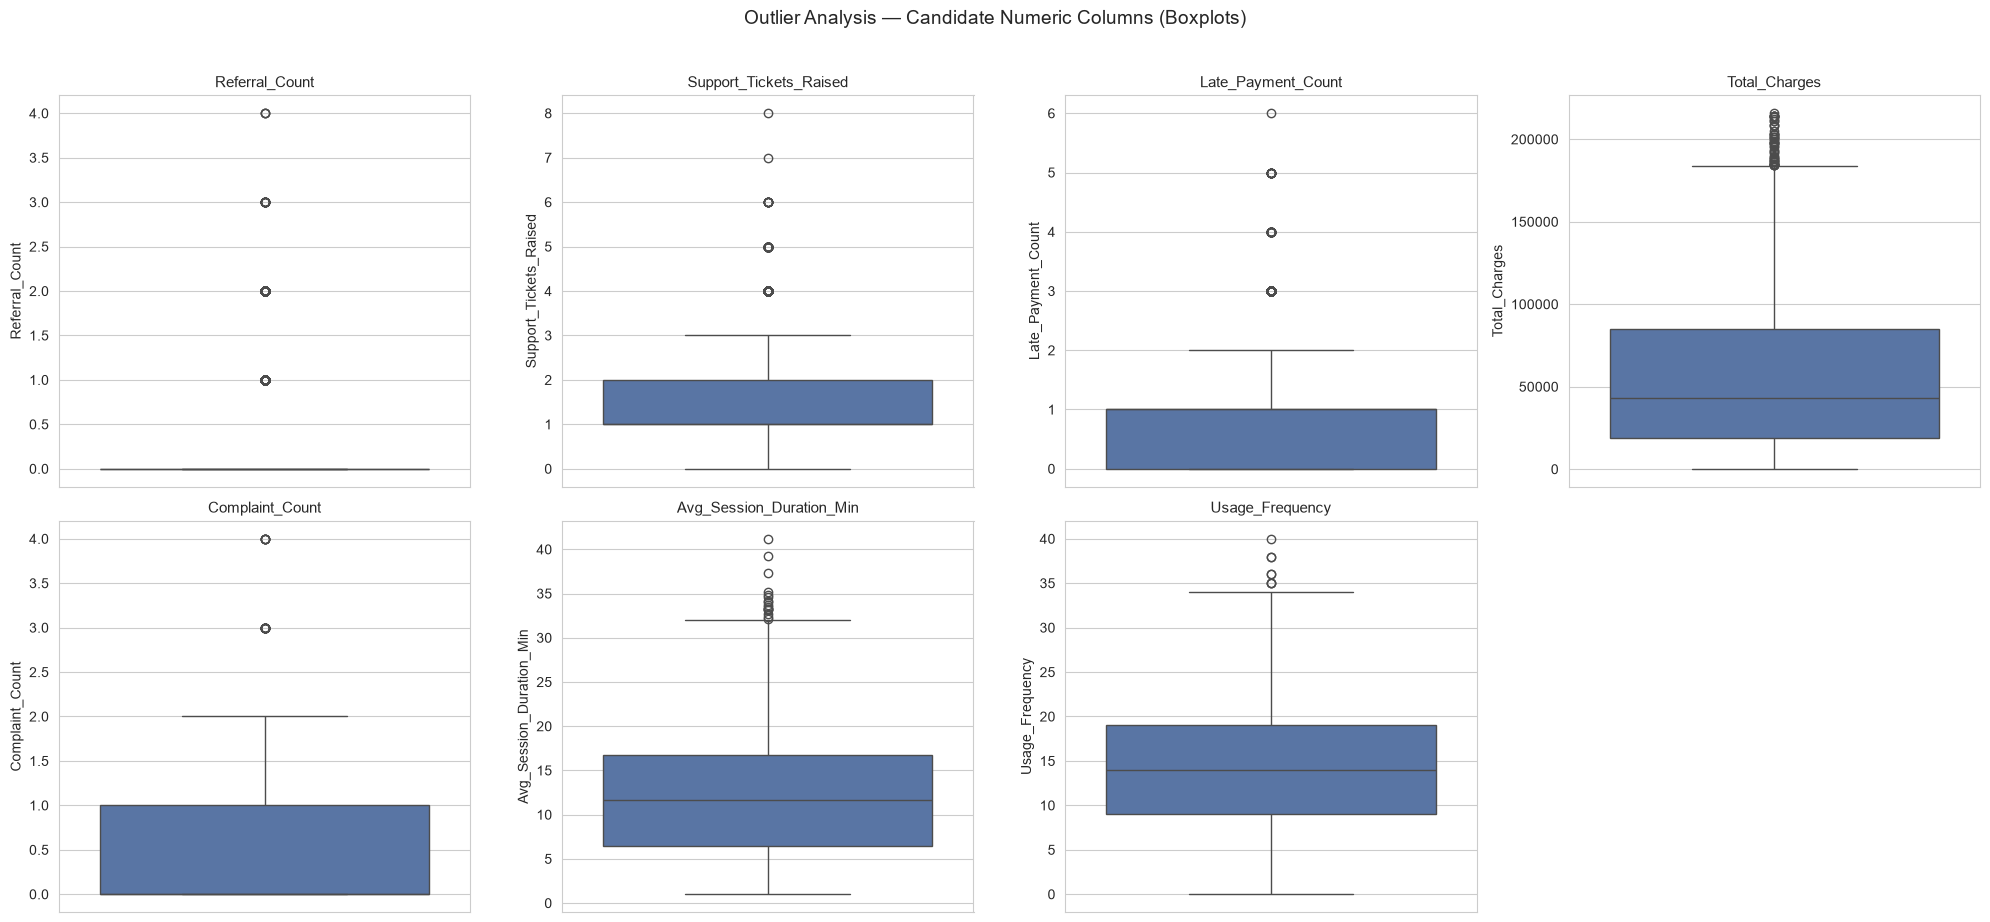

Conclusion: all flagged values fall within the plausible, non-negative domain for each
variable (e.g. Late_Payment_Count 0-6, Complaint_Count 0-4). None are corrected or removed;
they are retained as genuine behavioral signal.


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(outlier_candidate_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"{col}", fontsize=11)
    axes[i].set_ylabel(col)
axes[-1].axis("off")
fig.suptitle("Outlier Analysis — Candidate Numeric Columns (Boxplots)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Conclusion: all flagged values fall within the plausible, non-negative domain for each")
print("variable (e.g. Late_Payment_Count 0-6, Complaint_Count 0-4). None are corrected or removed;")
print("they are retained as genuine behavioral signal.")

### 6.6 Data Quality Summary — Before vs. After Cleaning

In [15]:
df_clean = df.copy()  # no invalid rows/values were identified, so cleaning is a no-op here
quality_after = data_quality_summary(df_clean)

quality_comparison = pd.DataFrame({
    "Column": quality_before["Column"],
    "Missing_Before": quality_before["Missing"],
    "Missing_After": quality_after["Missing"],
    "Negative_Before": quality_before["Negative_Values"],
    "Negative_After": quality_after["Negative_Values"],
})
quality_comparison["Rows_Before"] = len(df)
quality_comparison["Rows_After"] = len(df_clean)
quality_comparison

,Column,Missing_Before,Missing_After,Negative_Before,Negative_After,Rows_Before,Rows_After
0,Customer_ID,0,0,NaN,NaN,3216,3216
1,Age,0,0,0.0,0.0,3216,3216
2,Gender,0,0,NaN,NaN,3216,3216
3,City,0,0,NaN,NaN,3216,3216
4,Income_Level,0,0,NaN,NaN,3216,3216
5,Tenure_Months,0,0,0.0,0.0,3216,3216
6,Signup_Date,0,0,NaN,NaN,3216,3216
7,Contract_Type,0,0,NaN,NaN,3216,3216
8,Plan_Type,0,0,NaN,NaN,3216,3216
9,Payment_Method,0,0,NaN,NaN,3216,3216


## 7. Exploratory Data Analysis (EDA)

All EDA below uses the full dataset (`df_clean`) purely for **understanding** — no statistic
computed here is fitted into the modeling pipeline. Anything that touches the model (scaling,
imputation) is refit later, strictly on the training fold only.

### 7.1 Churn Distribution

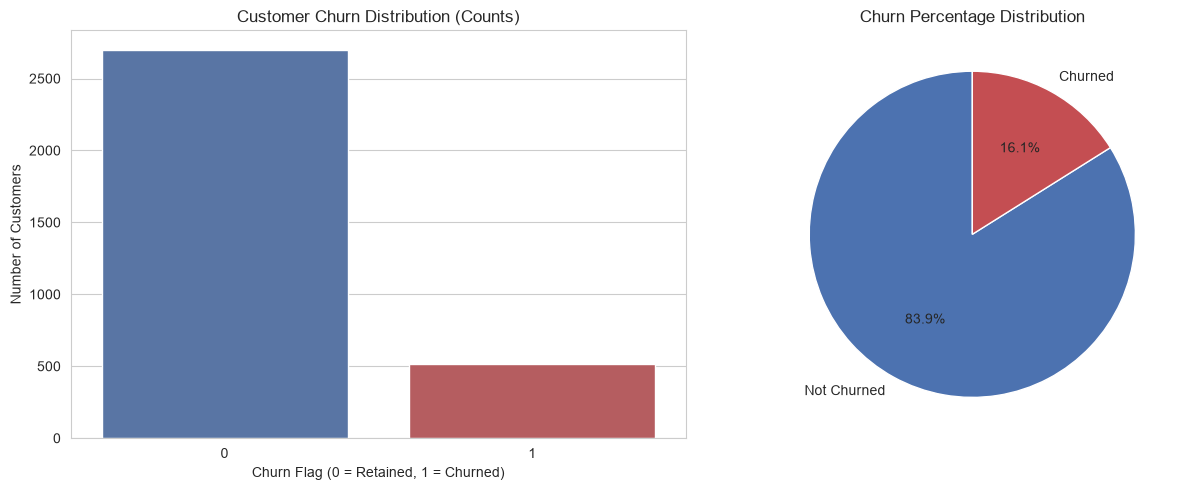

,Count,Percentage
Churn_Flag,,
0,2699,83.92
1,517,16.08


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df_clean, x="Churn_Flag", hue="Churn_Flag", palette=["#4C72B0", "#C44E52"],
              legend=False, ax=axes[0])
axes[0].set_title("Customer Churn Distribution (Counts)")
axes[0].set_xlabel("Churn Flag (0 = Retained, 1 = Churned)")
axes[0].set_ylabel("Number of Customers")

churn_counts = df_clean["Churn_Flag"].value_counts().sort_index()
axes[1].pie(churn_counts, labels=["Not Churned", "Churned"], autopct="%1.1f%%",
            colors=["#4C72B0", "#C44E52"], startangle=90)
axes[1].set_title("Churn Percentage Distribution")

plt.tight_layout()
plt.show()

churn_summary = pd.DataFrame({
    "Count": df_clean["Churn_Flag"].value_counts(),
    "Percentage": df_clean["Churn_Flag"].value_counts(normalize=True).mul(100).round(2)
})
churn_summary

### 7.2 Univariate Analysis — Numerical Variables

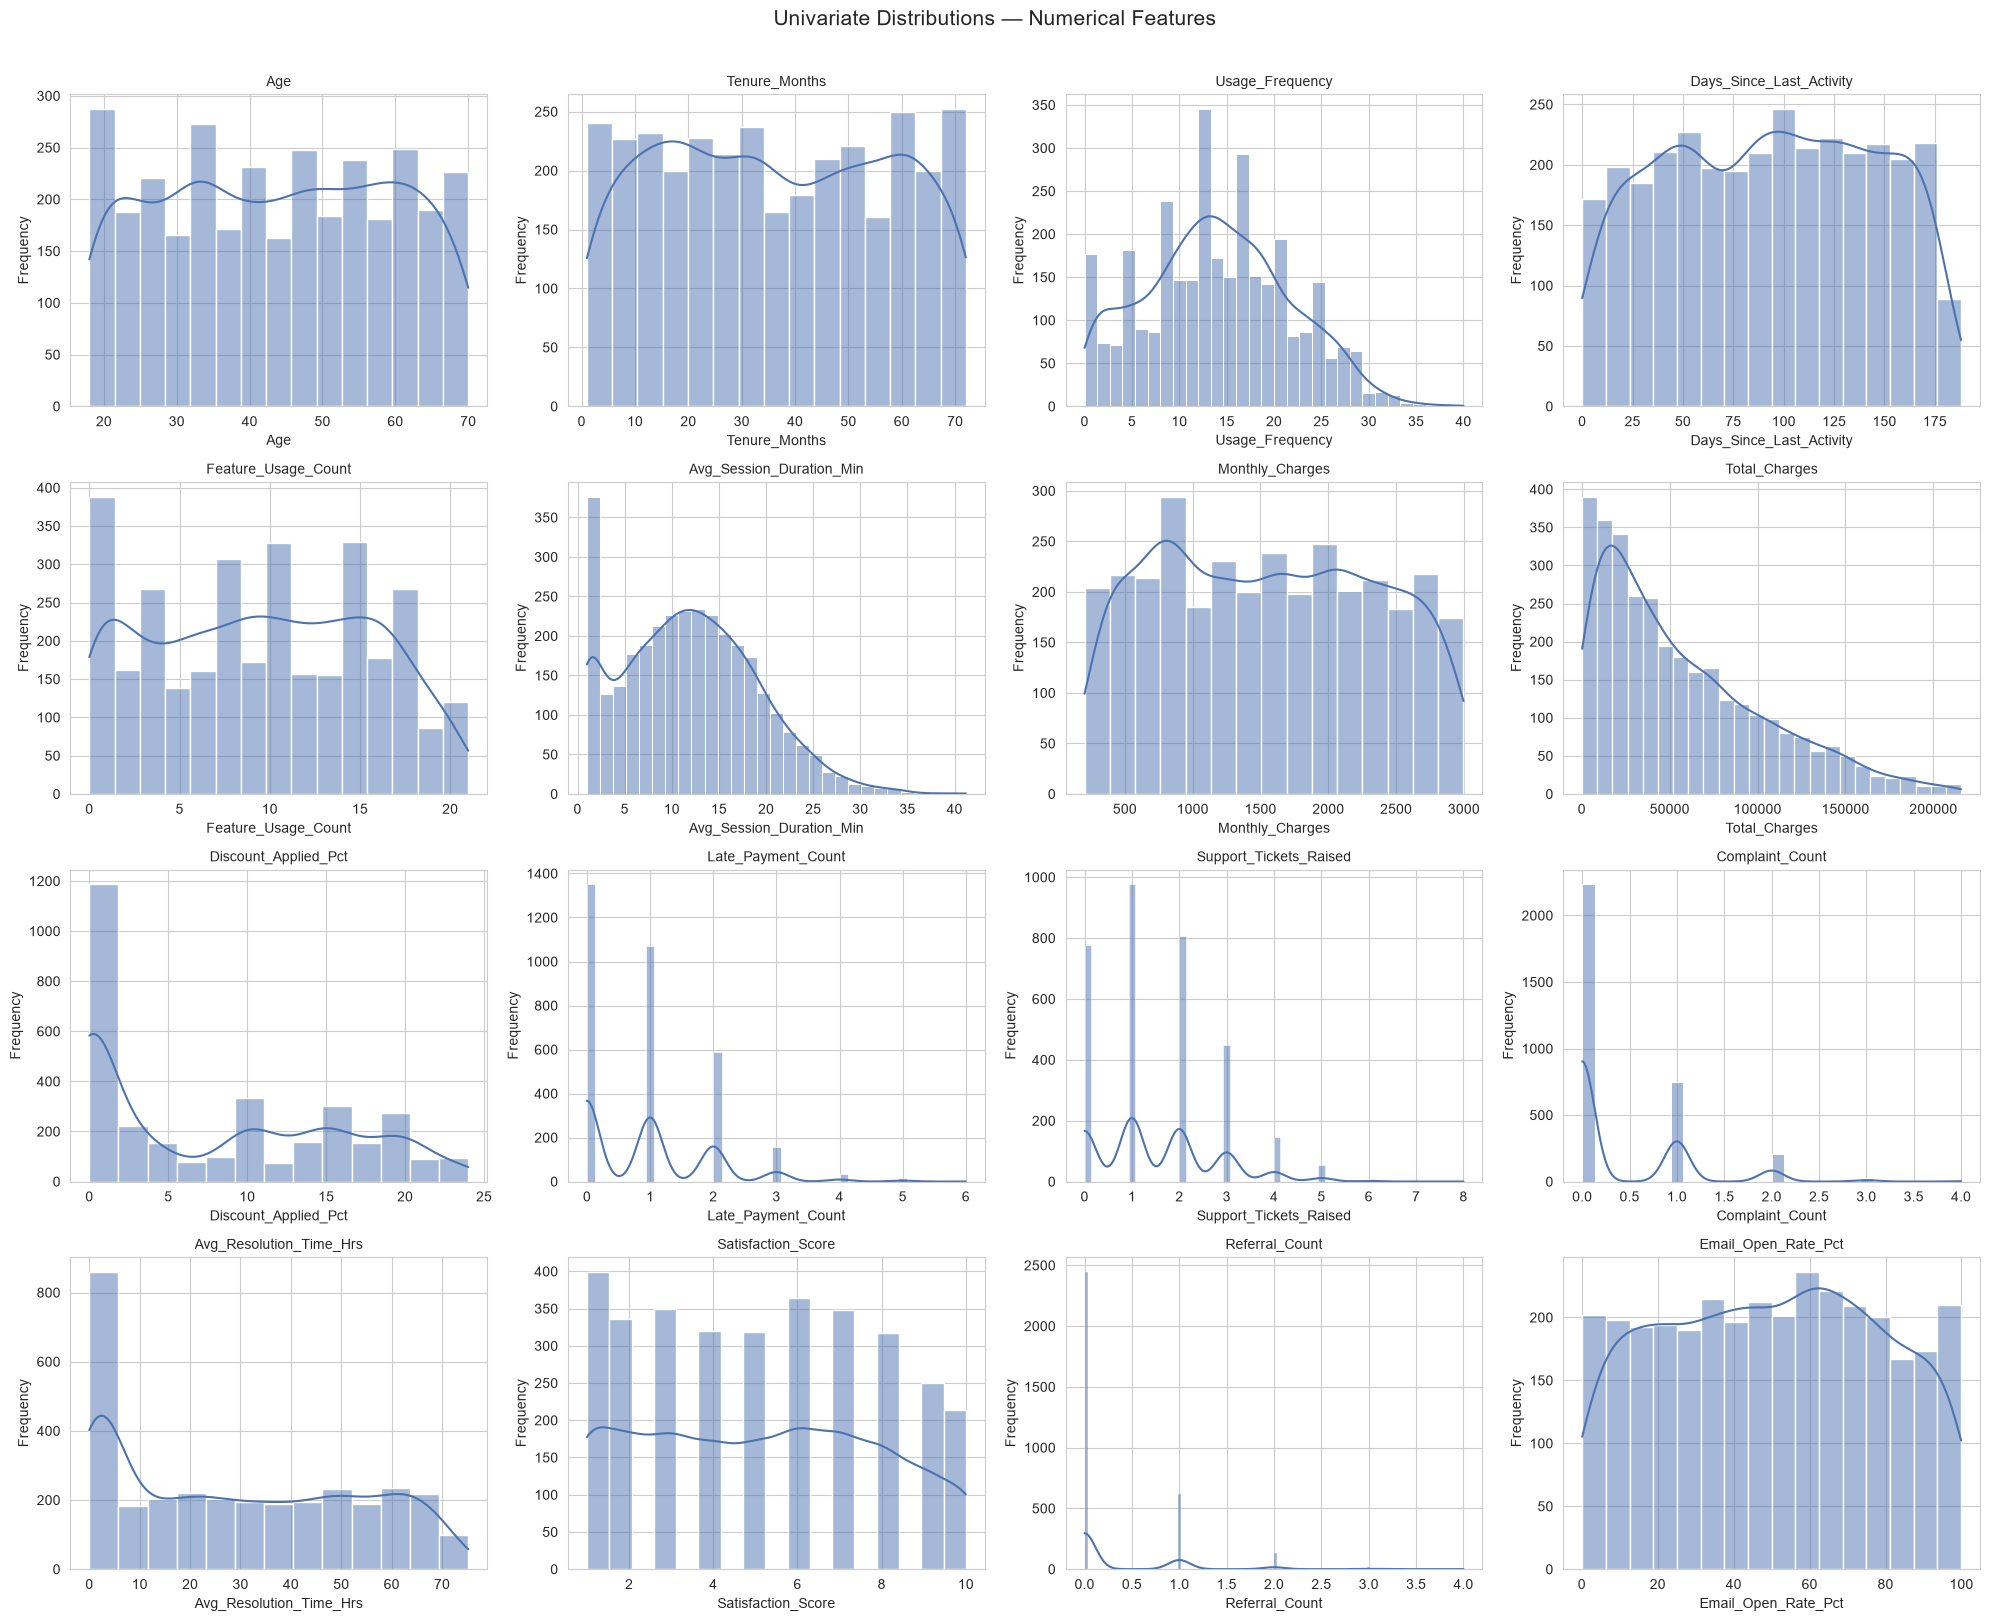

In [17]:
numerical_columns = [
    "Age", "Tenure_Months", "Usage_Frequency", "Days_Since_Last_Activity",
    "Feature_Usage_Count", "Avg_Session_Duration_Min", "Monthly_Charges", "Total_Charges",
    "Discount_Applied_Pct", "Late_Payment_Count", "Support_Tickets_Raised", "Complaint_Count",
    "Avg_Resolution_Time_Hrs", "Satisfaction_Score", "Referral_Count", "Email_Open_Rate_Pct"
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
fig.suptitle("Univariate Distributions — Numerical Features", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 7.3 Univariate Analysis — Categorical Variables

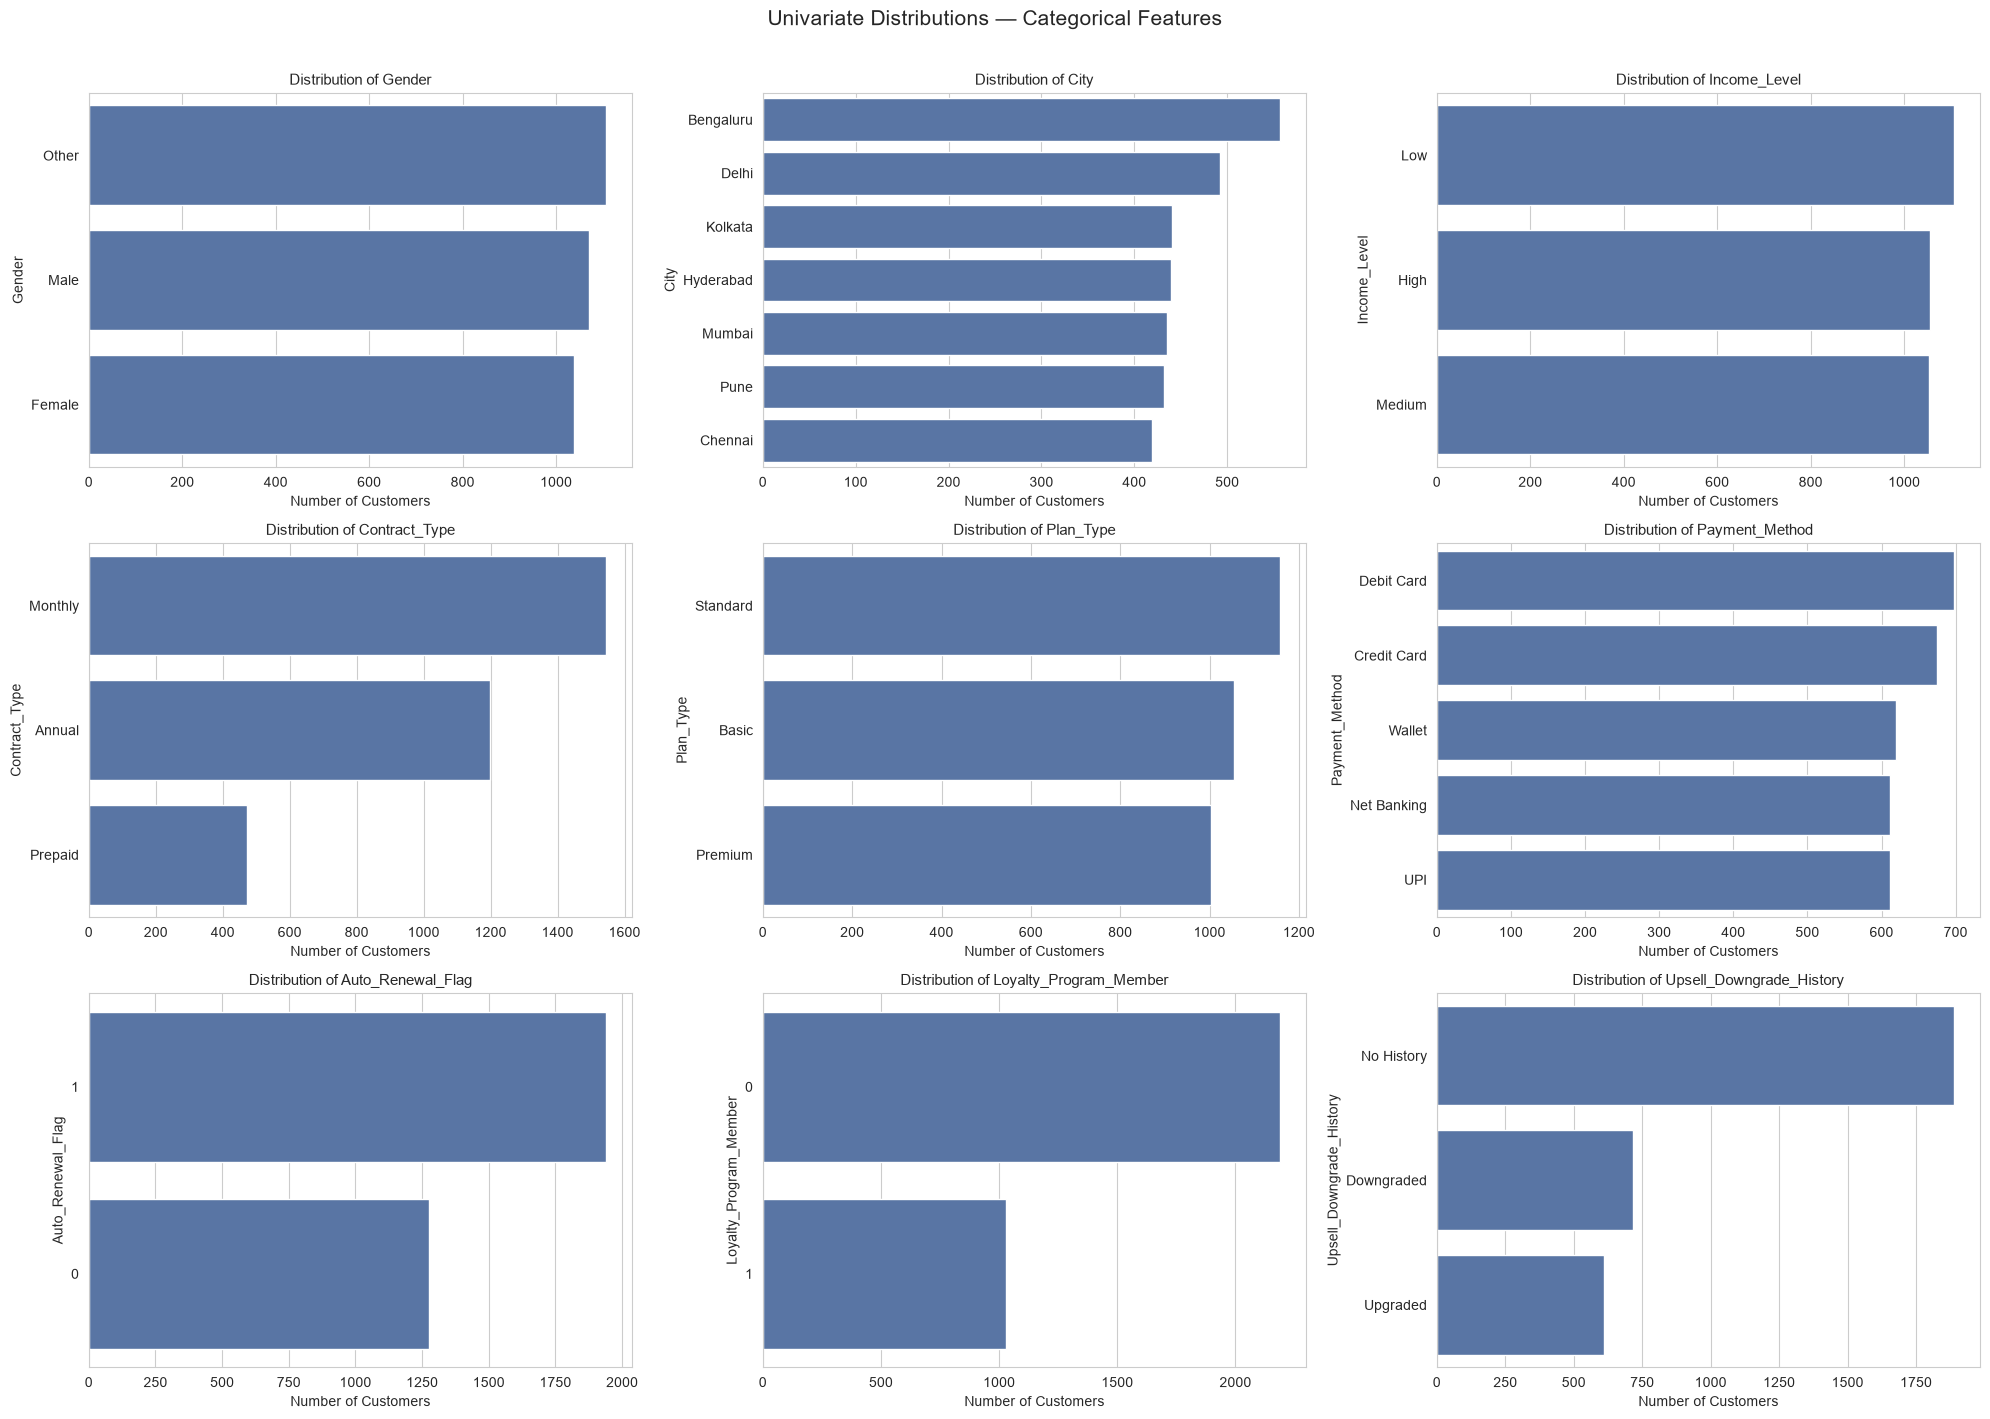

In [18]:
categorical_columns = [
    "Gender", "City", "Income_Level", "Contract_Type", "Plan_Type", "Payment_Method",
    "Auto_Renewal_Flag", "Loyalty_Program_Member", "Upsell_Downgrade_History"
]

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(categorical_columns):
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, y=col, order=order, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution of {col}", fontsize=11)
    axes[i].set_xlabel("Number of Customers")
fig.suptitle("Univariate Distributions — Categorical Features", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 7.4 Bivariate Analysis — Churn vs. Categorical Variables

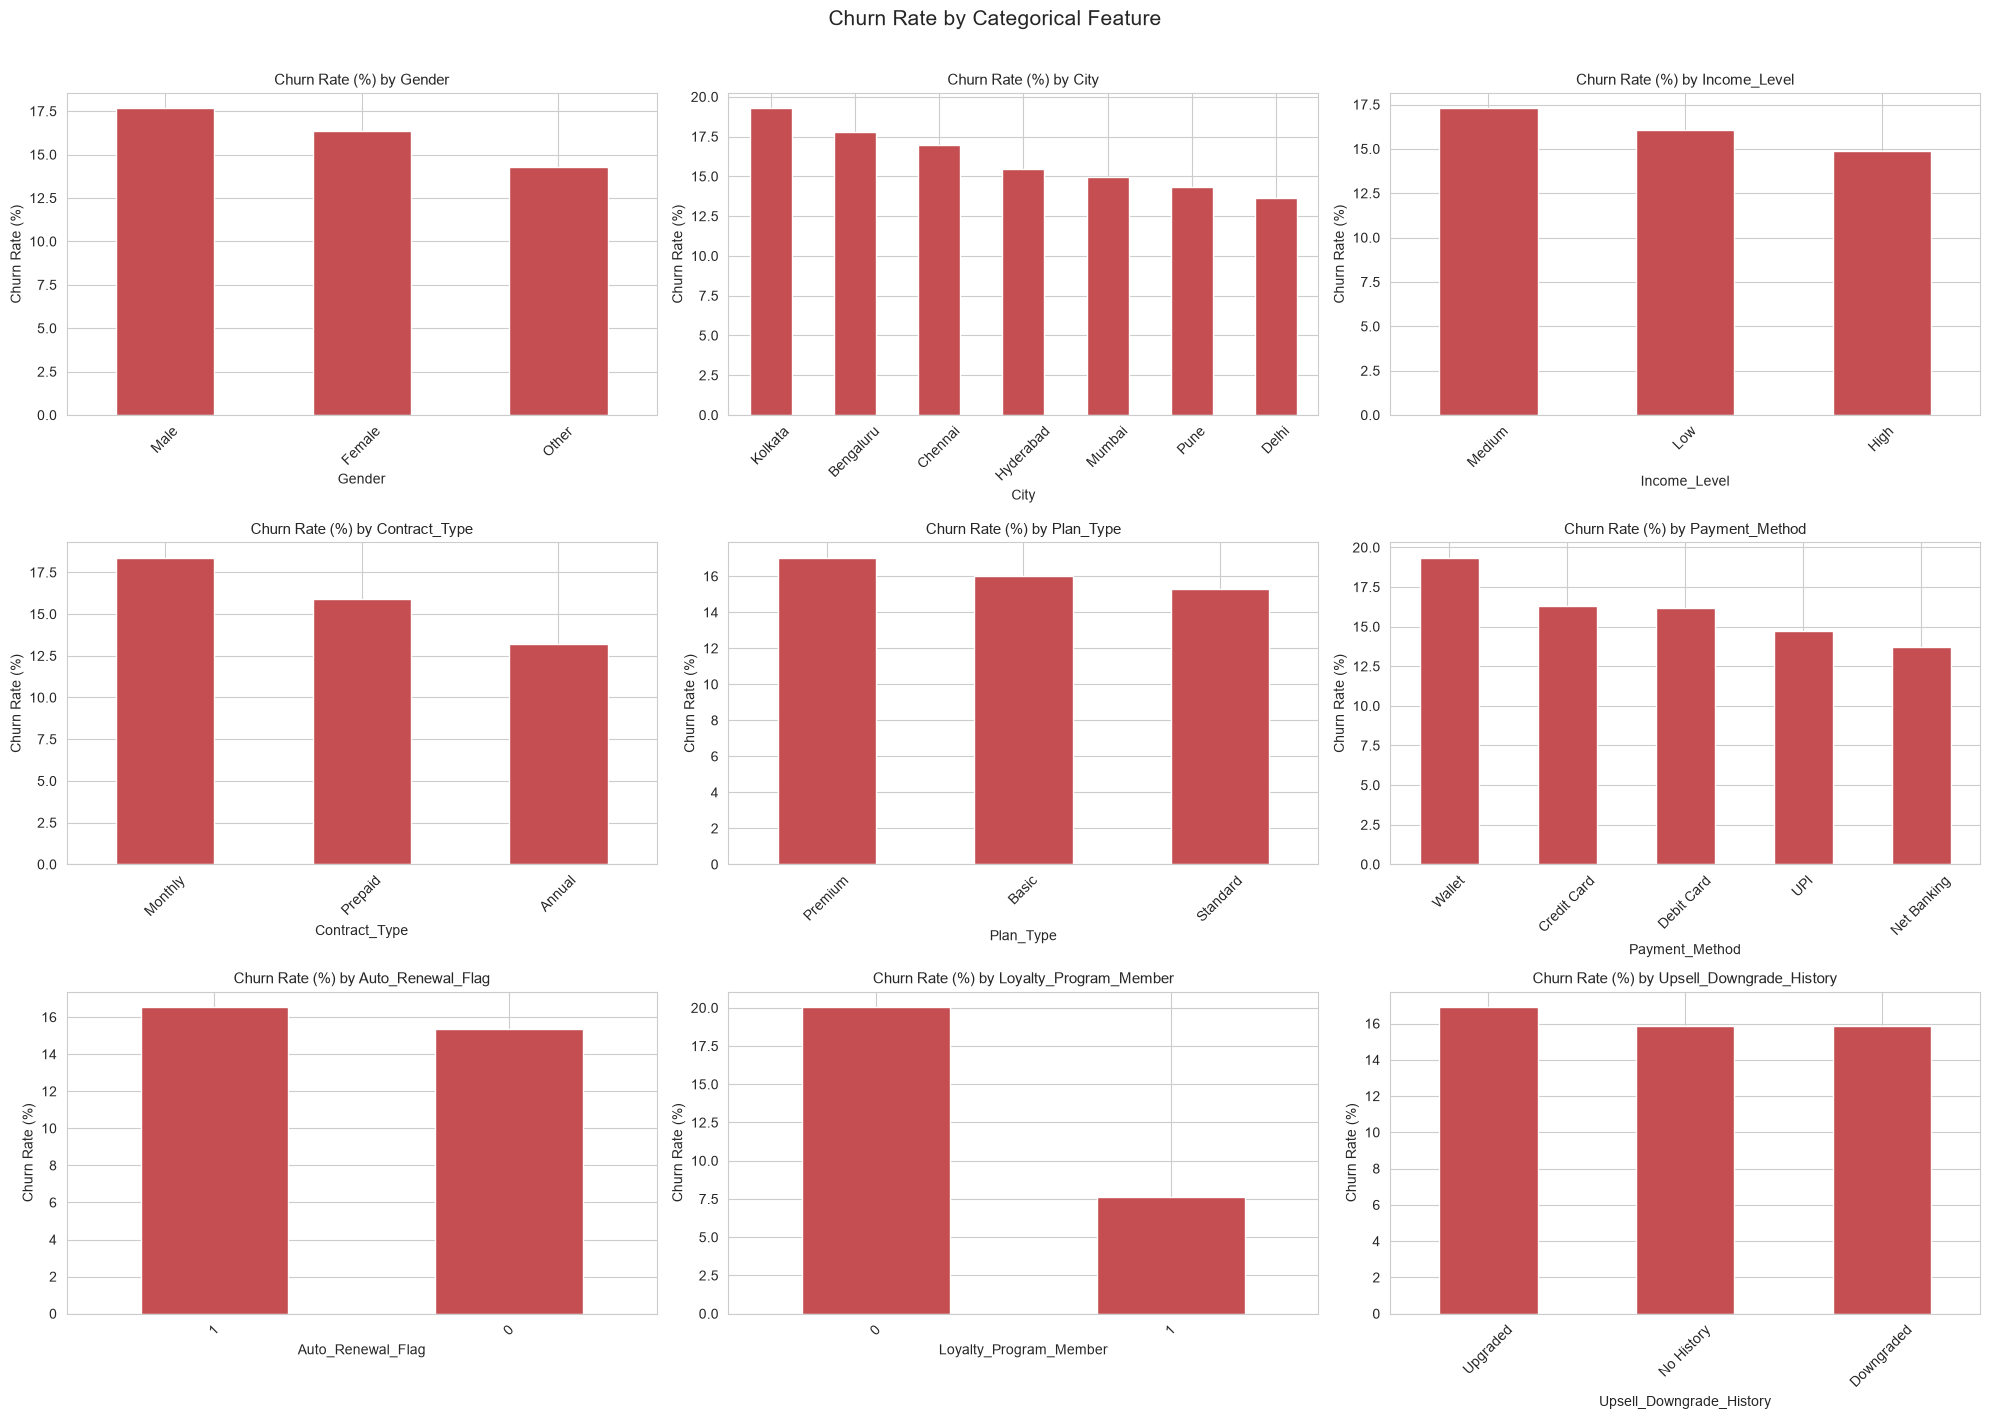


Churn rate (%) by Gender:
Gender
Male      17.66
Female    16.36
Other     14.27
Name: Churn_Flag, dtype: float64

Churn rate (%) by City:
City
Kolkata      19.27
Bengaluru    17.77
Chennai      16.95
Hyderabad    15.45
Mumbai       14.94
Pune         14.35
Delhi        13.62
Name: Churn_Flag, dtype: float64

Churn rate (%) by Income_Level:
Income_Level
Medium    17.28
Low       16.08
High      14.87
Name: Churn_Flag, dtype: float64

Churn rate (%) by Contract_Type:
Contract_Type
Monthly    18.38
Prepaid    15.89
Annual     13.18
Name: Churn_Flag, dtype: float64

Churn rate (%) by Plan_Type:
Plan_Type
Premium     17.03
Basic       16.03
Standard    15.28
Name: Churn_Flag, dtype: float64

Churn rate (%) by Payment_Method:
Payment_Method
Wallet         19.35
Credit Card    16.30
Debit Card     16.19
UPI            14.73
Net Banking    13.73
Name: Churn_Flag, dtype: float64

Churn rate (%) by Auto_Renewal_Flag:
Auto_Renewal_Flag
1    16.55
0    15.36
Name: Churn_Flag, dtype: float64

Chu

In [19]:
churn_rate_tables = {}
for col in categorical_columns:
    rate = (df_clean.groupby(col)["Churn_Flag"].mean() * 100).sort_values(ascending=False)
    churn_rate_tables[col] = rate

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(categorical_columns):
    churn_rate_tables[col].plot(kind="bar", ax=axes[i], color="#C44E52")
    axes[i].set_title(f"Churn Rate (%) by {col}", fontsize=11)
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].tick_params(axis="x", rotation=45)
fig.suptitle("Churn Rate by Categorical Feature", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

for col in categorical_columns:
    print(f"\nChurn rate (%) by {col}:")
    print(churn_rate_tables[col].round(2))

### 7.5 Bivariate Analysis — Churn vs. Numerical Variables

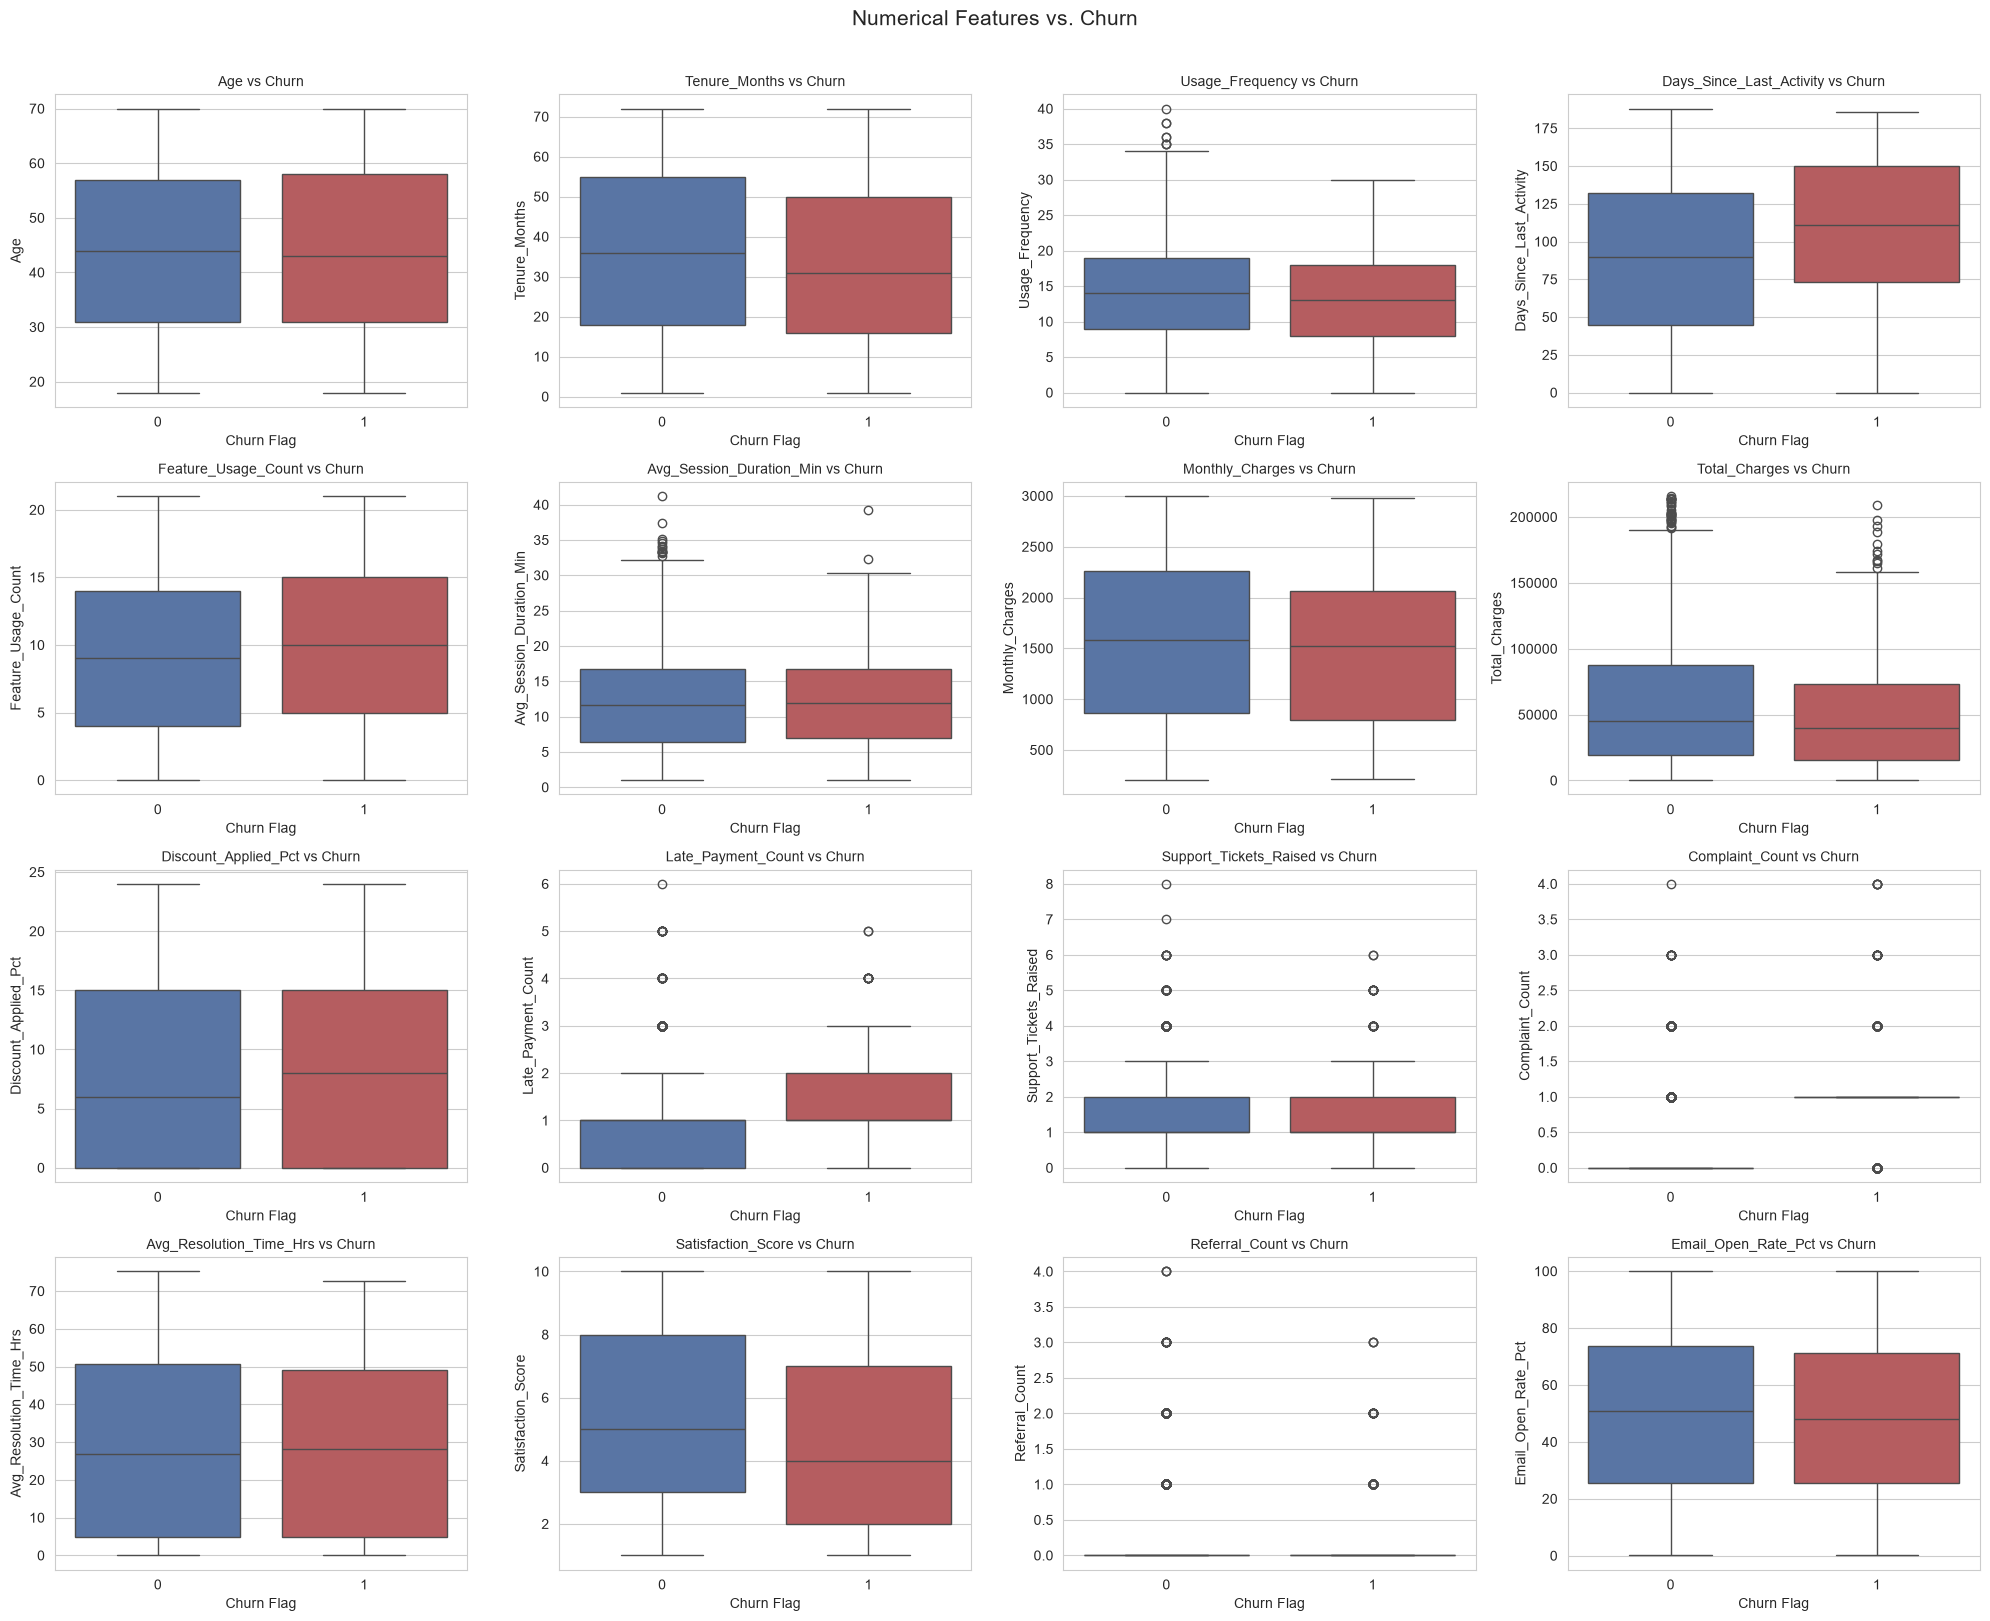

In [20]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(numerical_columns):
    sns.boxplot(data=df_clean, x="Churn_Flag", y=col, hue="Churn_Flag",
                palette=["#4C72B0", "#C44E52"], legend=False, ax=axes[i])
    axes[i].set_title(f"{col} vs Churn", fontsize=10)
    axes[i].set_xlabel("Churn Flag")
fig.suptitle("Numerical Features vs. Churn", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 7.6 Correlation Analysis

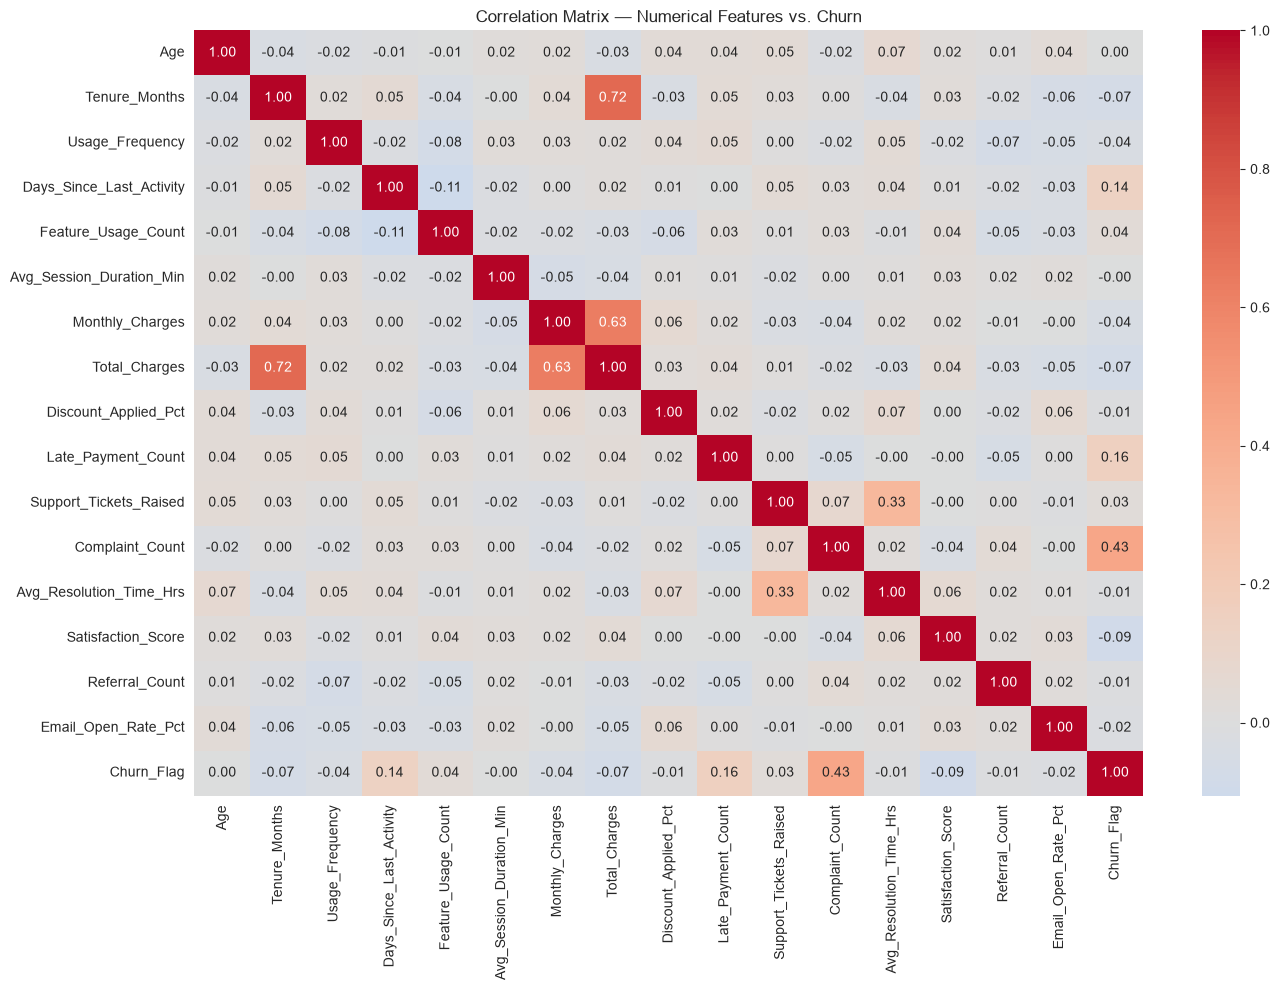

Correlation of each numerical feature with Churn_Flag (sorted):
Churn_Flag                  1.000000
Complaint_Count             0.432036
Late_Payment_Count          0.156339
Days_Since_Last_Activity    0.140356
Feature_Usage_Count         0.039987
Support_Tickets_Raised      0.027893
Age                         0.000467
Avg_Session_Duration_Min   -0.000998
Discount_Applied_Pct       -0.008946
Avg_Resolution_Time_Hrs    -0.009154
Referral_Count             -0.013159
Email_Open_Rate_Pct        -0.015803
Usage_Frequency            -0.035165
Monthly_Charges            -0.039414
Tenure_Months              -0.065044
Total_Charges              -0.071747
Satisfaction_Score         -0.090385
Name: Churn_Flag, dtype: float64


In [21]:
correlation_matrix = df_clean[numerical_columns + ["Churn_Flag"]].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numerical Features vs. Churn")
plt.tight_layout()
plt.show()

print("Correlation of each numerical feature with Churn_Flag (sorted):")
print(correlation_matrix["Churn_Flag"].sort_values(ascending=False))

## 8. Feature Engineering

A working copy `df_fe` is created so the cleaned dataset (`df_clean`) is never mutated. Every
new feature below is built **only from information already present for that customer at the
time of prediction** — nothing uses `Churn_Flag`, nothing uses "today's date" as a proxy for
customer status, and nothing is scaled/normalized against full-dataset statistics (that is
deferred to the modeling pipeline, fitted only on the training fold, later in the notebook).

### 8.1 Working Copy

In [22]:
df_fe = df_clean.copy()
df_fe["Signup_Date"] = pd.to_datetime(df_fe["Signup_Date"])
print("Working copy created. Shape:", df_fe.shape)

Working copy created. Shape: (3216, 28)


### 8.2 Signup Date Features

`Signup_Date` itself is not directly usable by most models, but its calendar components (year,
month, quarter, day-of-week) can capture cohort or seasonal signup effects.

In [23]:
df_fe["Signup_Year"] = df_fe["Signup_Date"].dt.year
df_fe["Signup_Month"] = df_fe["Signup_Date"].dt.month
df_fe["Signup_Quarter"] = df_fe["Signup_Date"].dt.quarter
df_fe["Signup_DayOfWeek"] = df_fe["Signup_Date"].dt.dayofweek

df_fe[["Signup_Date", "Signup_Year", "Signup_Month", "Signup_Quarter", "Signup_DayOfWeek"]].head()

,Signup_Date,Signup_Year,Signup_Month,Signup_Quarter,Signup_DayOfWeek
0,2026-01-12,2026,1,1,0
1,2025-11-27,2025,11,4,3
2,2025-11-26,2025,11,4,2
3,2023-07-10,2023,7,3,0
4,2025-10-20,2025,10,4,0


### 8.3 Tenure Category

`Tenure_Months` (the company's own recorded tenure — never recalculated from today's date, per
the earlier data-quality discussion) is binned into meaningful lifecycle stages. Tenure = 0 does
not occur in this dataset (minimum is 1), but the leftmost bin edge is set below 0 regardless,
so a tenure of exactly 0 would still be classified correctly as "New" if it appeared.

In [24]:
df_fe["Tenure_Category"] = pd.cut(
    df_fe["Tenure_Months"],
    bins=[-1, 6, 12, 24, 48, np.inf],
    labels=["New", "Short_Term", "Medium_Term", "Long_Term", "Very_Long_Term"]
)
df_fe["Tenure_Category"].value_counts().sort_index()

Tenure_Category
New                286
Short_Term         267
Medium_Term        574
Long_Term         1005
Very_Long_Term    1084
Name: count, dtype: int64

### 8.4 Financial Features

Three candidate financial features are investigated. As shown below, `Total_Charges` is
almost perfectly explained by `Monthly_Charges × Tenure_Months` (r ≈ 0.999), so two of the
three derived ratios turn out to be near-duplicates of `Monthly_Charges` and are dropped again
in the Feature Selection step to avoid multicollinearity — they are computed here for
completeness and transparency, and the decision to drop them is justified with numbers rather
than removed silently.

In [25]:
df_fe["Avg_Monthly_Charge_From_Total"] = (
    df_fe["Total_Charges"] / df_fe["Tenure_Months"].replace(0, np.nan)
).fillna(df_fe["Monthly_Charges"])

df_fe["Charge_Difference"] = df_fe["Total_Charges"] - (df_fe["Monthly_Charges"] * df_fe["Tenure_Months"])

df_fe["Charge_Per_Tenure"] = df_fe["Total_Charges"] / (df_fe["Tenure_Months"] + 1)

financial_corr = df_fe[[
    "Monthly_Charges", "Avg_Monthly_Charge_From_Total", "Charge_Per_Tenure", "Charge_Difference"
]].corr()
financial_corr.round(3)

,Monthly_Charges,Avg_Monthly_Charge_From_Total,Charge_Per_Tenure,Charge_Difference
Monthly_Charges,1.000,0.998,0.978,-0.097
Avg_Monthly_Charge_From_Total,0.998,1.000,0.979,-0.049
Charge_Per_Tenure,0.978,0.979,1.000,-0.063
Charge_Difference,-0.097,-0.049,-0.063,1.000


### 8.5 Payment Risk Feature

In [26]:
df_fe["Payment_Risk"] = pd.cut(
    df_fe["Late_Payment_Count"],
    bins=[-1, 0, 2, np.inf],
    labels=["Low", "Medium", "High"]
)
df_fe["Payment_Risk"].value_counts()

Payment_Risk
Medium    1659
Low       1350
High       207
Name: count, dtype: int64

### 8.6 Customer Issue Feature

In [27]:
df_fe["Total_Customer_Issues"] = df_fe["Support_Tickets_Raised"] + df_fe["Complaint_Count"]
df_fe[["Support_Tickets_Raised", "Complaint_Count", "Total_Customer_Issues"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Support_Tickets_Raised,3216.0,1.506530,1.248310,0.0,1.0,1.0,2.0,8.0
Complaint_Count,3216.0,0.390858,0.660291,0.0,0.0,0.0,1.0,4.0
Total_Customer_Issues,3216.0,1.897388,1.454562,0.0,1.0,2.0,3.0,8.0


### 8.7 Inactivity Category

In [28]:
df_fe["Inactivity_Level"] = pd.cut(
    df_fe["Days_Since_Last_Activity"],
    bins=[-1, 7, 30, 90, np.inf],
    labels=["Active", "Recently_Inactive", "Inactive", "Highly_Inactive"]
)
df_fe["Inactivity_Level"].value_counts().sort_index()

Inactivity_Level
Active                107
Recently_Inactive     373
Inactive             1056
Highly_Inactive      1680
Name: count, dtype: int64

### 8.8 Satisfaction Level

In [29]:
df_fe["Satisfaction_Level"] = pd.cut(
    df_fe["Satisfaction_Score"],
    bins=[0, 3, 7, 10],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)
df_fe["Satisfaction_Level"].value_counts().sort_index()

Satisfaction_Level
Low       1084
Medium    1351
High       781
Name: count, dtype: int64

### 8.9 Age Group

In [30]:
df_fe["Age_Group"] = pd.cut(
    df_fe["Age"],
    bins=[0, 25, 35, 50, 65, np.inf],
    labels=["Young", "Adult", "Middle_Aged", "Senior", "Older"]
)
df_fe["Age_Group"].value_counts().sort_index()

Age_Group
Young          532
Adult          603
Middle_Aged    873
Senior         931
Older          277
Name: count, dtype: int64

### 8.10 Contract / Renewal Feature

In [31]:
df_fe["Contract_Renewal_Status"] = (
    df_fe["Contract_Type"].astype(str) + "_" +
    np.where(df_fe["Auto_Renewal_Flag"] == 1, "AutoRenew", "Manual")
)
df_fe["Contract_Renewal_Status"].value_counts()

Contract_Renewal_Status
Monthly_AutoRenew    949
Annual_AutoRenew     692
Monthly_Manual       596
Annual_Manual        507
Prepaid_AutoRenew    299
Prepaid_Manual       173
Name: count, dtype: int64

### 8.11 Feature Engineering Summary

In [32]:
print("Rows:", df_fe.shape[0], " | Columns after feature engineering:", df_fe.shape[1])
new_feature_cols = [c for c in df_fe.columns if c not in df_clean.columns]
print("\nNewly engineered columns:")
for c in new_feature_cols:
    print(" -", c)

print("\nMissing values introduced by feature engineering:")
print(df_fe[new_feature_cols].isnull().sum())

Rows: 3216  | Columns after feature engineering: 42

Newly engineered columns:
 - Signup_Year
 - Signup_Month
 - Signup_Quarter
 - Signup_DayOfWeek
 - Tenure_Category
 - Avg_Monthly_Charge_From_Total
 - Charge_Difference
 - Charge_Per_Tenure
 - Payment_Risk
 - Total_Customer_Issues
 - Inactivity_Level
 - Satisfaction_Level
 - Age_Group
 - Contract_Renewal_Status

Missing values introduced by feature engineering:
Signup_Year                      0
Signup_Month                     0
Signup_Quarter                   0
Signup_DayOfWeek                 0
Tenure_Category                  0
Avg_Monthly_Charge_From_Total    0
Charge_Difference                0
Charge_Per_Tenure                0
Payment_Risk                     0
Total_Customer_Issues            0
Inactivity_Level                 0
Satisfaction_Level               0
Age_Group                        0
Contract_Renewal_Status          0
dtype: int64


| New Feature | Purpose |
|---|---|
| `Signup_Year/Month/Quarter/DayOfWeek` | Capture cohort / seasonal signup effects |
| `Tenure_Category` | Non-linear lifecycle stage grouping of tenure |
| `Avg_Monthly_Charge_From_Total`, `Charge_Per_Tenure` | Investigated; dropped in Feature Selection (near-duplicate of `Monthly_Charges`) |
| `Charge_Difference` | Residual gap between actual and expected billing (captures discount/adjustment effects) |
| `Payment_Risk` | Categorical risk tier from late-payment count |
| `Total_Customer_Issues` | Combined support-ticket + complaint burden |
| `Inactivity_Level` | Categorical tier from days since last activity |
| `Satisfaction_Level` | Categorical tier from satisfaction score |
| `Age_Group` | Demographic segment |
| `Contract_Renewal_Status` | Joint contract-type × auto-renewal commitment signal |

## 9. Feature Selection

Remove identifier, target, raw date, and feature-engineering helper columns
that should not be directly used for model training.

In [33]:
# Columns that should not be used directly for modeling
drop_columns = [
    "Customer_ID",
    "Churn_Flag",
    "Signup_Date",

    # Full-dataset scaled helper features
    "Usage_Frequency_Scaled",
    "Feature_Usage_Scaled",
    "Session_Duration_Scaled",
    "Engagement_Score",
    "Engagement_Score_Scaled",

    # Full-dataset financial scaling
    "Total_Charges_Scaled",
    "Engagement_Score_Scaled",
    "Customer_Value_Score",

    # Diagnostic feature
    "Calculated_Tenure_Months"
]

X = df_fe.drop(columns=drop_columns, errors="ignore")
y = df_fe["Churn_Flag"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (3216, 39)
Target shape: (3216,)

Features:
['Age', 'Gender', 'City', 'Income_Level', 'Tenure_Months', 'Contract_Type', 'Plan_Type', 'Payment_Method', 'Auto_Renewal_Flag', 'Usage_Frequency', 'Days_Since_Last_Activity', 'Feature_Usage_Count', 'Avg_Session_Duration_Min', 'Monthly_Charges', 'Total_Charges', 'Discount_Applied_Pct', 'Late_Payment_Count', 'Support_Tickets_Raised', 'Complaint_Count', 'Avg_Resolution_Time_Hrs', 'Satisfaction_Score', 'Referral_Count', 'Loyalty_Program_Member', 'Upsell_Downgrade_History', 'Email_Open_Rate_Pct', 'Signup_Year', 'Signup_Month', 'Signup_Quarter', 'Signup_DayOfWeek', 'Tenure_Category', 'Avg_Monthly_Charge_From_Total', 'Charge_Difference', 'Charge_Per_Tenure', 'Payment_Risk', 'Total_Customer_Issues', 'Inactivity_Level', 'Satisfaction_Level', 'Age_Group', 'Contract_Renewal_Status']


### 9.1 Selected Features Check

In [34]:
print("Numerical Features:")
print(X.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical Features:")
print(X.select_dtypes(include=["object", "category"]).columns.tolist())

print("\nTotal Features:", X.shape[1])

Numerical Features:
['Age', 'Tenure_Months', 'Auto_Renewal_Flag', 'Usage_Frequency', 'Days_Since_Last_Activity', 'Feature_Usage_Count', 'Avg_Session_Duration_Min', 'Monthly_Charges', 'Total_Charges', 'Discount_Applied_Pct', 'Late_Payment_Count', 'Support_Tickets_Raised', 'Complaint_Count', 'Avg_Resolution_Time_Hrs', 'Satisfaction_Score', 'Referral_Count', 'Loyalty_Program_Member', 'Email_Open_Rate_Pct', 'Signup_Year', 'Signup_Month', 'Signup_Quarter', 'Signup_DayOfWeek', 'Avg_Monthly_Charge_From_Total', 'Charge_Difference', 'Charge_Per_Tenure', 'Total_Customer_Issues']

Categorical Features:
['Gender', 'City', 'Income_Level', 'Contract_Type', 'Plan_Type', 'Payment_Method', 'Upsell_Downgrade_History', 'Tenure_Category', 'Payment_Risk', 'Inactivity_Level', 'Satisfaction_Level', 'Age_Group', 'Contract_Renewal_Status']

Total Features: 39


## 10. Train-Test Split

Split the dataset into training and testing sets.

Stratification is used to maintain the same churn class distribution
in both training and testing data.

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (2572, 39)
y_train: (2572,)

Testing set:
X_test: (644, 39)
y_test: (644,)


## 11. Class Imbalance Analysis

Training set class distribution:
            Count  Percentage
Churn_Flag                   
0            2159       83.94
1             413       16.06

Testing set class distribution:
            Count  Percentage
Churn_Flag                   
0             540       83.85
1             104       16.15


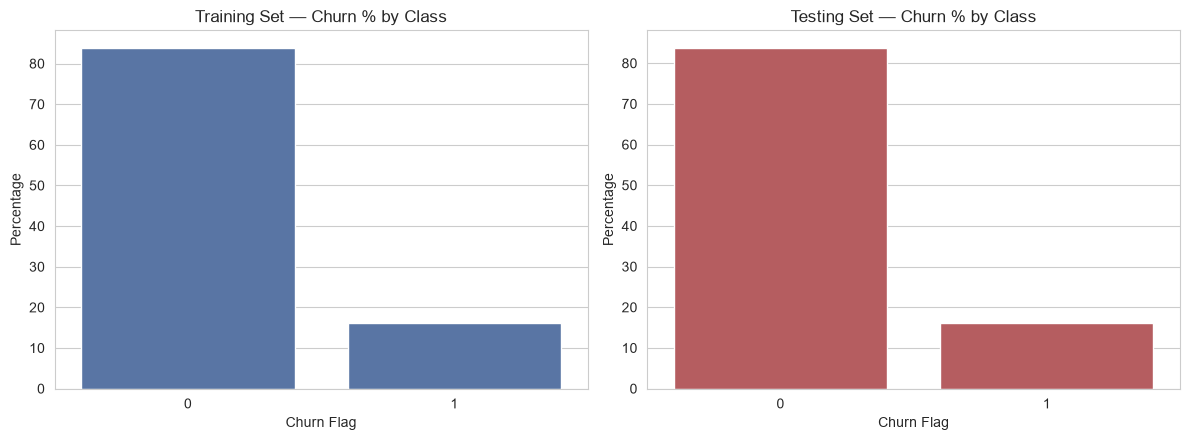


Stratified splitting has preserved the ~16% churn rate in both sets — good.


In [36]:
train_distribution = pd.DataFrame({
    "Count": y_train.value_counts().sort_index(),
    "Percentage": y_train.value_counts(normalize=True).sort_index().mul(100).round(2)
})
test_distribution = pd.DataFrame({
    "Count": y_test.value_counts().sort_index(),
    "Percentage": y_test.value_counts(normalize=True).sort_index().mul(100).round(2)
})

print("Training set class distribution:")
print(train_distribution)
print("\nTesting set class distribution:")
print(test_distribution)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(x=train_distribution.index, y=train_distribution["Percentage"], ax=axes[0], color="#4C72B0")
axes[0].set_title("Training Set — Churn % by Class")
axes[0].set_xlabel("Churn Flag"); axes[0].set_ylabel("Percentage")
sns.barplot(x=test_distribution.index, y=test_distribution["Percentage"], ax=axes[1], color="#C44E52")
axes[1].set_title("Testing Set — Churn % by Class")
axes[1].set_xlabel("Churn Flag"); axes[1].set_ylabel("Percentage")
plt.tight_layout()
plt.show()

print("\nStratified splitting has preserved the ~16% churn rate in both sets — good.")

## 12. Class Imbalance Handling

The target variable is imbalanced, with fewer churned customers than non-churned customers.

Class weights are used so that the model gives additional importance
to the minority churn class during training.

The test set is kept unchanged.

In [37]:
class_weight="balanced"

## 13. Data Preprocessing

Separate numerical and categorical features.

Numerical features are imputed using the median and standardized.

Categorical features are imputed using the most frequent value
and converted into numerical form using One-Hot Encoding.

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Identify numerical and categorical columns
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 26
Number of categorical features: 13

Numerical features:
['Age', 'Tenure_Months', 'Auto_Renewal_Flag', 'Usage_Frequency', 'Days_Since_Last_Activity', 'Feature_Usage_Count', 'Avg_Session_Duration_Min', 'Monthly_Charges', 'Total_Charges', 'Discount_Applied_Pct', 'Late_Payment_Count', 'Support_Tickets_Raised', 'Complaint_Count', 'Avg_Resolution_Time_Hrs', 'Satisfaction_Score', 'Referral_Count', 'Loyalty_Program_Member', 'Email_Open_Rate_Pct', 'Signup_Year', 'Signup_Month', 'Signup_Quarter', 'Signup_DayOfWeek', 'Avg_Monthly_Charge_From_Total', 'Charge_Difference', 'Charge_Per_Tenure', 'Total_Customer_Issues']

Categorical features:
['Gender', 'City', 'Income_Level', 'Contract_Type', 'Plan_Type', 'Payment_Method', 'Upsell_Downgrade_History', 'Tenure_Category', 'Payment_Risk', 'Inactivity_Level', 'Satisfaction_Level', 'Age_Group', 'Contract_Renewal_Status']


### 13.1 Numerical Preprocessing

In [39]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

### 13.2 Categorical Preprocessing

In [40]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

### 13.3 Combine Preprocessing

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 14. Models

### 14.1 Logistic Regression Model

Logistic Regression is used as the first baseline classification model for customer churn prediction.

The model uses the preprocessing pipeline already created above:

* Numerical features → median imputation + standardization
* Categorical features → most-frequent imputation + one-hot encoding
* `class_weight="balanced"` → gives additional importance to the minority churn class

The model outputs both:

* Predicted churn class
* Churn probability

The churn probability is required for ROC-AUC, PR-AUC, Log Loss, Brier Score, Lift & Gain analysis, and cost-sensitive evaluation.


In [42]:
# Logistic Regression model

logistic_regression = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                max_iter=2000
            )
        )
    ]
)

# Train the model
logistic_regression.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


#### 14.1.1 Logistic Regression Predictions

Generate both class predictions and churn probabilities on the unseen test set.

The probability of class `1` represents the predicted probability that a customer will churn.


In [43]:
# Predicted class
y_pred = logistic_regression.predict(X_test)

# Predicted probability of churn
y_proba = logistic_regression.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of test predictions:", len(y_pred))

Predictions generated successfully.
Number of test predictions: 644


#### 14.1.2 Logistic Regression Evaluation

The model is evaluated using multiple complementary classification metrics:

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
* PR-AUC
* Confusion Matrix
* Log Loss / Cross-Entropy
* Brier Score
* Lift
* Gain
* Cost-Sensitive Metrics

Because the dataset is imbalanced, accuracy is not considered sufficient by itself. Precision, Recall, F1-score, PR-AUC, and the confusion matrix are especially useful for understanding churn-class performance.


In [44]:
# 1. Basic Classification Metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


# 2. Probability-Based Metrics

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

pr_auc = average_precision_score(
    y_test,
    y_proba
)

logloss = log_loss(
    y_test,
    y_proba
)

brier = brier_score_loss(
    y_test,
    y_proba
)


# 3. Confusion Matrix

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
).ravel()


# 4. Lift & Gain at Top 10%


# Create evaluation dataframe
evaluation_data = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Churn_Probability": y_proba
})

# Sort customers from highest to lowest churn probability
evaluation_data = evaluation_data.sort_values(
    by="Churn_Probability",
    ascending=False
).reset_index(drop=True)

# Top 10% customers
top_10_count = max(
    1,
    int(np.ceil(len(evaluation_data) * 0.10))
)

top_10 = evaluation_data.iloc[:top_10_count]

# Overall churn rate
overall_churn_rate = evaluation_data["Actual"].mean()

# Churn rate in top 10%
top_10_churn_rate = top_10["Actual"].mean()

# Lift
lift_at_10 = (
    top_10_churn_rate / overall_churn_rate
    if overall_churn_rate > 0
    else np.nan
)

# Gain
total_churners = evaluation_data["Actual"].sum()

gain_at_10 = (
    top_10["Actual"].sum() / total_churners
    if total_churners > 0
    else np.nan
)

# Convert gain to percentage
gain_at_10_pct = gain_at_10 * 100


# 5. Cost-Sensitive Metrics

# You can change these business costs according to your project.

COST_FALSE_POSITIVE = 1
COST_FALSE_NEGATIVE = 5

false_positive_cost = fp * COST_FALSE_POSITIVE
false_negative_cost = fn * COST_FALSE_NEGATIVE

total_cost = (
    false_positive_cost +
    false_negative_cost
)

average_cost_per_customer = (
    total_cost / len(y_test)
)

# Cost if we did nothing and allowed all actual churners
baseline_cost = (
    total_churners * COST_FALSE_NEGATIVE
)

# Cost savings compared with the baseline
cost_savings = baseline_cost - total_cost

# 6. Single Evaluation DataFrame

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "True Positive (TP)",
        "Log Loss / Cross-Entropy",
        "Brier Score",
        "Lift @ 10%",
        "Gain @ 10%",
        "False Positive Cost",
        "False Negative Cost",
        "Total Cost",
        "Average Cost per Customer",
        "Baseline Cost",
        "Cost Savings"
    ],

    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc,
        tn,
        fp,
        fn,
        tp,
        logloss,
        brier,
        lift_at_10,
        gain_at_10_pct,
        false_positive_cost,
        false_negative_cost,
        total_cost,
        average_cost_per_customer,
        baseline_cost,
        cost_savings
    ]
})

# Display rounded values
metrics_df["Value"] = metrics_df["Value"].round(4)

metrics_df

,Metric,Value
0,Accuracy,0.8323
1,Precision,0.4880
2,Recall,0.7788
3,F1-Score,0.6000
4,ROC-AUC,0.8803
5,PR-AUC,0.6729
6,True Negative (TN),455.0000
7,False Positive (FP),85.0000
8,False Negative (FN),23.0000
9,True Positive (TP),81.0000


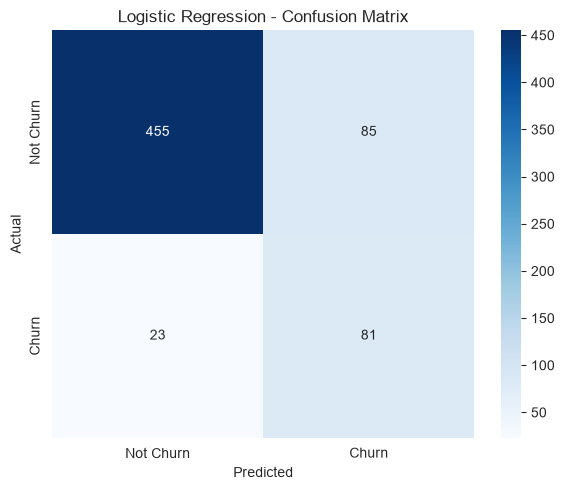

In [45]:
# Confusion Matrix Visualization

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

#### 14.1.3 Lift & Gain Charts

Lift and Gain analysis evaluates how effectively the model identifies customers with a high probability of churn.

Customers are sorted from highest to lowest predicted churn probability and divided into cumulative population percentages.

* **Gain** shows the percentage of all actual churners captured.
* **Lift** compares the captured churn rate against the overall churn rate.


In [46]:
# Create Cumulative Gain and Lift Data

lift_gain_df = evaluation_data.copy()

lift_gain_df["Population_%"] = (
    (np.arange(1, len(lift_gain_df) + 1) / len(lift_gain_df)) * 100
)

lift_gain_df["Cumulative_Churners"] = (
    lift_gain_df["Actual"].cumsum()
)

lift_gain_df["Gain_%"] = (
    lift_gain_df["Cumulative_Churners"] / total_churners
) * 100

lift_gain_df["Cumulative_Churn_Rate"] = (
    lift_gain_df["Cumulative_Churners"] /
    np.arange(1, len(lift_gain_df) + 1)
)

lift_gain_df["Lift"] = (
    lift_gain_df["Cumulative_Churn_Rate"] /
    overall_churn_rate
)

# Sample points at every 10%
lift_chart_data = (
    lift_gain_df
    .assign(
        Population_Bin=lambda x:
        (x["Population_%"] // 10) * 10
    )
    .groupby("Population_Bin", as_index=False)
    .agg({
        "Gain_%": "max",
        "Lift": "max"
    })
)

lift_chart_data

,Population_Bin,Gain_%,Lift
0,0.0,46.153846,6.192308
1,10.0,73.076923,4.644231
2,20.0,79.807692,3.696184
3,30.0,85.576923,2.649286
4,40.0,87.500000,2.136106
5,50.0,95.192308,1.782925
6,60.0,98.076923,1.584079
7,70.0,99.038462,1.400478
8,80.0,100.000000,1.236061
9,90.0,100.000000,1.110345


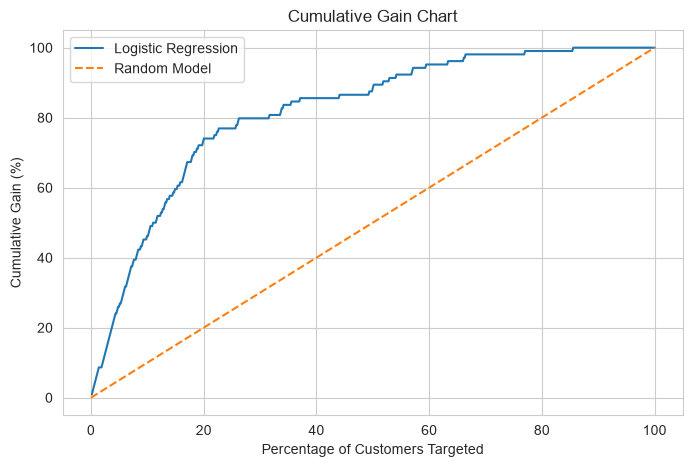

In [47]:
# Gain Chart Visualization

plt.figure(figsize=(8, 5))

plt.plot(
    lift_gain_df["Population_%"],
    lift_gain_df["Gain_%"],
    label="Logistic Regression"
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Random Model"
)

plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Cumulative Gain (%)")
plt.title("Cumulative Gain Chart")
plt.legend()
plt.grid(True)
plt.show()

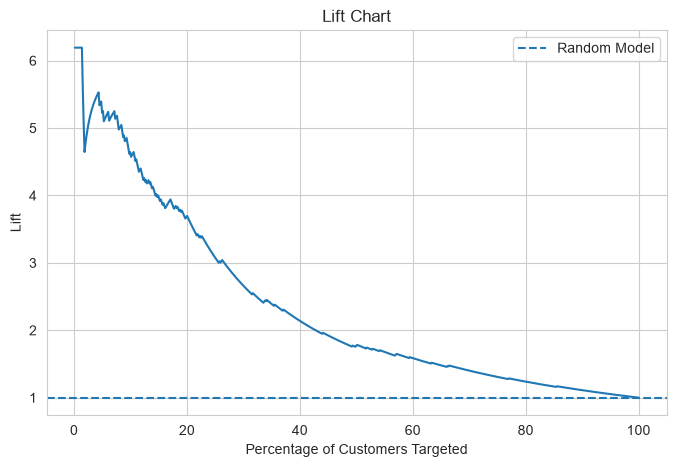

In [48]:
# Lift Chart

plt.figure(figsize=(8, 5))

plt.plot(
    lift_gain_df["Population_%"],
    lift_gain_df["Lift"]
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Random Model"
)

plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Lift")
plt.title("Lift Chart")
plt.legend()
plt.grid(True)
plt.show()

#### 14.1.4 Final Logistic Regression Evaluation

The table below provides a single consolidated view of all important Logistic Regression evaluation results.

This table can later be reused when comparing Logistic Regression with Random Forest and XGBoost.


In [49]:
# Final evaluation table

metrics_df

,Metric,Value
0,Accuracy,0.8323
1,Precision,0.4880
2,Recall,0.7788
3,F1-Score,0.6000
4,ROC-AUC,0.8803
5,PR-AUC,0.6729
6,True Negative (TN),455.0000
7,False Positive (FP),85.0000
8,False Negative (FN),23.0000
9,True Positive (TP),81.0000


#### 14.1.5 Logistic Regression Hyperparameter Tuning

Hyperparameter tuning is performed using cross-validation on the training dataset.

The following parameters are tuned:

* `C` — controls regularization strength
* `penalty` — L1 or L2 regularization
* `solver` — optimization algorithm
* `class_weight` — handles class imbalance

Because customer churn is commonly an imbalanced classification problem, **PR-AUC is used as the primary tuning metric**.

The test set is not used during hyperparameter selection.


In [50]:
# Hyperparameter Tuning Imports

from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.linear_model import LogisticRegression

from scipy.stats import loguniform

import numpy as np
import pandas as pd

In [51]:
# Logistic Regression Hyperparameter Search Space

param_distributions = {
    
    # Regularization strength
    "classifier__C": loguniform(1e-4, 1e3),

    # Regularization type
    "classifier__penalty": ["l1", "l2"],

    # Solvers compatible with L1 and L2
    "classifier__solver": ["liblinear", "saga"],

    # Class imbalance handling
    "classifier__class_weight": [
        "balanced",
        None,
        {0: 1, 1: 1.5},
        {0: 1, 1: 2},
        {0: 1, 1: 2.5},
        {0: 1, 1: 3},
        {0: 1, 1: 4},
        {0: 1, 1: 5}
    ],

    # Maximum iterations
    "classifier__max_iter": [1000, 2000, 3000, 5000]
}

In [52]:
# Stratified Cross Validation

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [53]:
# Base Logistic Regression Pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                random_state=RANDOM_STATE
            )
        )
    ]
)

# Randomized Search

logistic_random_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=param_distributions,

    # Stronger search
    n_iter=60,

    # 5-fold stratified CV
    cv=cv_strategy,

    # Primary optimization metric
    scoring="average_precision",

    # Use all CPU cores
    n_jobs=-1,

    # Store training scores
    return_train_score=True,

    # Reproducibility
    random_state=RANDOM_STATE,

    verbose=2
)


# Fit Search on TRAINING Data Only

logistic_random_search.fit(
    X_train,
    y_train
)

print("Hyperparameter tuning completed.")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Hyperparameter tuning completed.


In [54]:
# Best Hyperparameters

print("Best PR-AUC Score:")
print(logistic_random_search.best_score_)

print("\nBest Hyperparameters:")
print(logistic_random_search.best_params_)

Best PR-AUC Score:
0.6276442295688758

Best Hyperparameters:
{'classifier__C': np.float64(26.664274004676844), 'classifier__class_weight': None, 'classifier__max_iter': 2000, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}


In [55]:
# Extract Best Model

best_logistic_model = logistic_random_search.best_estimator_

print("Best Logistic Regression model selected.")

Best Logistic Regression model selected.


In [56]:
# Predictions from Tuned Model

y_pred_tuned = best_logistic_model.predict(X_test)

y_proba_tuned = best_logistic_model.predict_proba(X_test)[:, 1]


# Classification Metrics

accuracy_tuned = accuracy_score(
    y_test,
    y_pred_tuned
)

precision_tuned = precision_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

recall_tuned = recall_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

f1_tuned = f1_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)


# Probability Metrics

roc_auc_tuned = roc_auc_score(
    y_test,
    y_proba_tuned
)

pr_auc_tuned = average_precision_score(
    y_test,
    y_proba_tuned
)

logloss_tuned = log_loss(
    y_test,
    y_proba_tuned
)

brier_tuned = brier_score_loss(
    y_test,
    y_proba_tuned
)


# Confusion Matrix

tn_tuned, fp_tuned, fn_tuned, tp_tuned = confusion_matrix(
    y_test,
    y_pred_tuned,
    labels=[0, 1]
).ravel()


# Lift & Gain @ 10%

tuned_eval = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": y_pred_tuned,
    "Churn_Probability": y_proba_tuned
})

tuned_eval = tuned_eval.sort_values(
    "Churn_Probability",
    ascending=False
).reset_index(drop=True)

top_10_count_tuned = max(
    1,
    int(np.ceil(len(tuned_eval) * 0.10))
)

top_10_tuned = tuned_eval.iloc[:top_10_count_tuned]

overall_churn_rate_tuned = tuned_eval["Actual"].mean()

top_10_churn_rate_tuned = top_10_tuned["Actual"].mean()

lift_at_10_tuned = (
    top_10_churn_rate_tuned /
    overall_churn_rate_tuned
    if overall_churn_rate_tuned > 0
    else np.nan
)

total_churners_tuned = tuned_eval["Actual"].sum()

gain_at_10_tuned = (
    top_10_tuned["Actual"].sum() /
    total_churners_tuned
    if total_churners_tuned > 0
    else np.nan
)

gain_at_10_tuned_pct = gain_at_10_tuned * 100


# Cost-Sensitive Metrics

COST_FALSE_POSITIVE = 1
COST_FALSE_NEGATIVE = 5

false_positive_cost_tuned = (
    fp_tuned * COST_FALSE_POSITIVE
)

false_negative_cost_tuned = (
    fn_tuned * COST_FALSE_NEGATIVE
)

total_cost_tuned = (
    false_positive_cost_tuned +
    false_negative_cost_tuned
)

average_cost_tuned = (
    total_cost_tuned / len(y_test)
)

baseline_cost_tuned = (
    total_churners_tuned *
    COST_FALSE_NEGATIVE
)

cost_savings_tuned = (
    baseline_cost_tuned -
    total_cost_tuned
)

In [57]:
# FINAL TUNED LOGISTIC REGRESSION METRICS

tuned_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",

        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "True Positive (TP)",

        "Log Loss / Cross-Entropy",
        "Brier Score",

        "Lift @ 10%",
        "Gain @ 10%",

        "False Positive Cost",
        "False Negative Cost",
        "Total Cost",
        "Average Cost per Customer",
        "Baseline Cost",
        "Cost Savings"
    ],

    "Value": [
        accuracy_tuned,
        precision_tuned,
        recall_tuned,
        f1_tuned,
        roc_auc_tuned,
        pr_auc_tuned,

        tn_tuned,
        fp_tuned,
        fn_tuned,
        tp_tuned,

        logloss_tuned,
        brier_tuned,

        lift_at_10_tuned,
        gain_at_10_tuned_pct,

        false_positive_cost_tuned,
        false_negative_cost_tuned,
        total_cost_tuned,
        average_cost_tuned,
        baseline_cost_tuned,
        cost_savings_tuned
    ]
})

tuned_metrics_df["Value"] = tuned_metrics_df["Value"].round(4)

tuned_metrics_df

,Metric,Value
0,Accuracy,0.8913
1,Precision,0.7742
2,Recall,0.4615
3,F1-Score,0.5783
4,ROC-AUC,0.8864
5,PR-AUC,0.6858
6,True Negative (TN),526.0000
7,False Positive (FP),14.0000
8,False Negative (FN),56.0000
9,True Positive (TP),48.0000


In [58]:
# Baseline vs Tuned Comparison

baseline_vs_tuned = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score"
    ],

    "Baseline Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc,
        logloss,
        brier
    ],

    "Tuned Logistic Regression": [
        accuracy_tuned,
        precision_tuned,
        recall_tuned,
        f1_tuned,
        roc_auc_tuned,
        pr_auc_tuned,
        logloss_tuned,
        brier_tuned
    ]
})

baseline_vs_tuned["Improvement"] = (
    baseline_vs_tuned["Tuned Logistic Regression"] -
    baseline_vs_tuned["Baseline Logistic Regression"]
)

baseline_vs_tuned.round(4)

,Metric,Baseline Logistic Regression,Tuned Logistic Regression,Improvement
0,Accuracy,0.8323,0.8913,0.0590
1,Precision,0.4880,0.7742,0.2862
2,Recall,0.7788,0.4615,-0.3173
3,F1-Score,0.6000,0.5783,-0.0217
4,ROC-AUC,0.8803,0.8864,0.0061
5,PR-AUC,0.6729,0.6858,0.0128
6,Log Loss,0.3989,0.2793,-0.1195
7,Brier Score,0.1250,0.0818,-0.0431


### 14.2 Random Forest Classifier

Random Forest is an ensemble classification algorithm that combines multiple decision trees to make predictions.

It is useful for customer churn prediction because it can capture:

* Non-linear relationships
* Feature interactions
* Complex decision boundaries
* Different patterns between churn and non-churn customers

The model uses the preprocessing pipeline already created in the notebook.


In [59]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

# Train Random Forest
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [60]:
# Random Forest Predictions

y_pred_rf = random_forest_model.predict(X_test)

y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


In [61]:
# 1. Basic Classification Metrics

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)


# 2. Probability-Based Metrics

roc_auc_rf = roc_auc_score(
    y_test,
    y_proba_rf
)

pr_auc_rf = average_precision_score(
    y_test,
    y_proba_rf
)

logloss_rf = log_loss(
    y_test,
    y_proba_rf
)

brier_rf = brier_score_loss(
    y_test,
    y_proba_rf
)


# 3. Confusion Matrix

tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=[0, 1]
).ravel()


# 4. Lift & Gain @ 10%

rf_eval = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": y_pred_rf,
    "Churn_Probability": y_proba_rf
})

rf_eval = rf_eval.sort_values(
    by="Churn_Probability",
    ascending=False
).reset_index(drop=True)

top_10_count_rf = max(
    1,
    int(np.ceil(len(rf_eval) * 0.10))
)

top_10_rf = rf_eval.iloc[:top_10_count_rf]

overall_churn_rate_rf = rf_eval["Actual"].mean()

top_10_churn_rate_rf = top_10_rf["Actual"].mean()

lift_at_10_rf = (
    top_10_churn_rate_rf / overall_churn_rate_rf
    if overall_churn_rate_rf > 0
    else np.nan
)

total_churners_rf = rf_eval["Actual"].sum()

gain_at_10_rf = (
    top_10_rf["Actual"].sum() / total_churners_rf
    if total_churners_rf > 0
    else np.nan
)

gain_at_10_rf_pct = gain_at_10_rf * 100


# 5. Cost-Sensitive Metrics

COST_FALSE_POSITIVE = 1
COST_FALSE_NEGATIVE = 5

false_positive_cost_rf = (
    fp_rf * COST_FALSE_POSITIVE
)

false_negative_cost_rf = (
    fn_rf * COST_FALSE_NEGATIVE
)

total_cost_rf = (
    false_positive_cost_rf +
    false_negative_cost_rf
)

average_cost_rf = (
    total_cost_rf / len(y_test)
)

baseline_cost_rf = (
    total_churners_rf *
    COST_FALSE_NEGATIVE
)

cost_savings_rf = (
    baseline_cost_rf -
    total_cost_rf
)


# 6. Single Evaluation DataFrame

rf_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",

        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "True Positive (TP)",

        "Log Loss / Cross-Entropy",
        "Brier Score",

        "Lift @ 10%",
        "Gain @ 10%",

        "False Positive Cost",
        "False Negative Cost",
        "Total Cost",
        "Average Cost per Customer",
        "Baseline Cost",
        "Cost Savings"
    ],

    "Value": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf,
        pr_auc_rf,

        tn_rf,
        fp_rf,
        fn_rf,
        tp_rf,

        logloss_rf,
        brier_rf,

        lift_at_10_rf,
        gain_at_10_rf_pct,

        false_positive_cost_rf,
        false_negative_cost_rf,
        total_cost_rf,
        average_cost_rf,
        baseline_cost_rf,
        cost_savings_rf
    ]
})

rf_metrics_df["Value"] = rf_metrics_df["Value"].round(4)

rf_metrics_df

,Metric,Value
0,Accuracy,0.9130
1,Precision,0.8158
2,Recall,0.5962
3,F1-Score,0.6889
4,ROC-AUC,0.9459
5,PR-AUC,0.7997
6,True Negative (TN),526.0000
7,False Positive (FP),14.0000
8,False Negative (FN),42.0000
9,True Positive (TP),62.0000


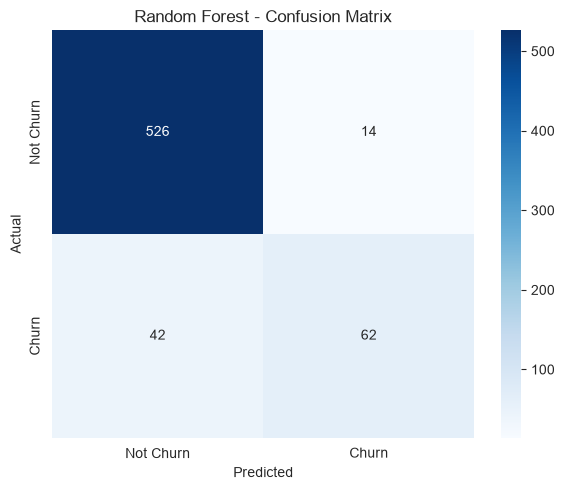

In [62]:
# Random Forest Confusion Matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [63]:
# Cumulative Gain and Lift Data

rf_lift_gain = rf_eval.copy()

rf_lift_gain["Population_%"] = (
    np.arange(1, len(rf_lift_gain) + 1)
    / len(rf_lift_gain)
) * 100

rf_lift_gain["Cumulative_Churners"] = (
    rf_lift_gain["Actual"].cumsum()
)

rf_lift_gain["Gain_%"] = (
    rf_lift_gain["Cumulative_Churners"]
    / total_churners_rf
) * 100

rf_lift_gain["Cumulative_Churn_Rate"] = (
    rf_lift_gain["Cumulative_Churners"]
    / np.arange(1, len(rf_lift_gain) + 1)
)

rf_lift_gain["Lift"] = (
    rf_lift_gain["Cumulative_Churn_Rate"]
    / overall_churn_rate_rf
)

rf_lift_gain.head()

,Actual,Predicted,Churn_Probability,Population_%,Cumulative_Churners,Gain_%,Cumulative_Churn_Rate,Lift
0,1,1,0.964,0.155280,1,0.961538,1.0,6.192308
1,1,1,0.934,0.310559,2,1.923077,1.0,6.192308
2,1,1,0.910,0.465839,3,2.884615,1.0,6.192308
3,1,1,0.904,0.621118,4,3.846154,1.0,6.192308
4,1,1,0.898,0.776398,5,4.807692,1.0,6.192308


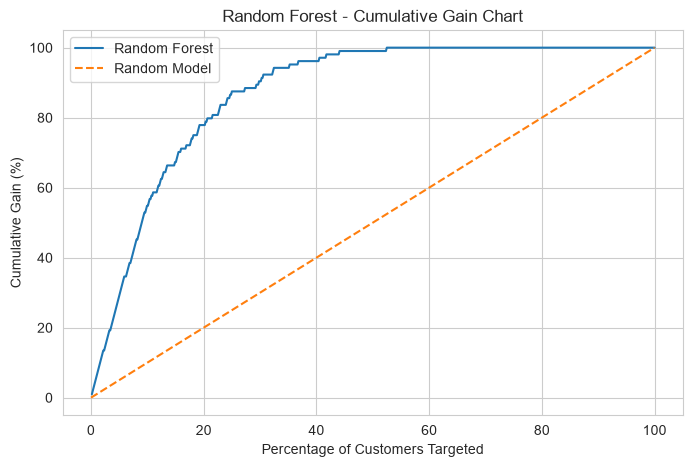

In [64]:
# Random Forest Gain Chart

plt.figure(figsize=(8, 5))

plt.plot(
    rf_lift_gain["Population_%"],
    rf_lift_gain["Gain_%"],
    label="Random Forest"
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Random Model"
)

plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Cumulative Gain (%)")
plt.title("Random Forest - Cumulative Gain Chart")

plt.legend()
plt.grid(True)
plt.show()

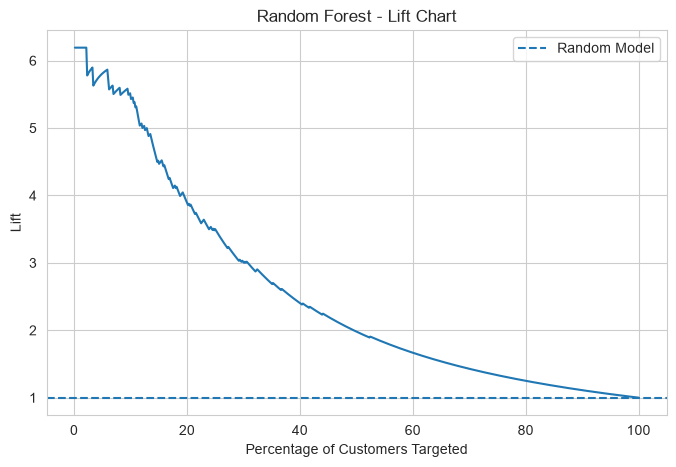

In [65]:
# Random Forest Lift Chart

plt.figure(figsize=(8, 5))

plt.plot(
    rf_lift_gain["Population_%"],
    rf_lift_gain["Lift"]
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Random Model"
)

plt.xlabel("Percentage of Customers Targeted")
plt.ylabel("Lift")
plt.title("Random Forest - Lift Chart")

plt.legend()
plt.grid(True)
plt.show()

#### 14.2.1 Random Forest Hyperparameter Tuning

Hyperparameter tuning is performed to find a better Random Forest configuration using cross-validation on the training dataset.

The following parameters are tuned:

* Number of trees
* Maximum tree depth
* Minimum samples required for splitting
* Minimum samples required at a leaf
* Maximum features considered at each split
* Class weights
* Bootstrap sampling

PR-AUC is used as the primary optimization metric because it is useful for imbalanced customer churn classification.

The test dataset is not used during hyperparameter tuning.


In [66]:
# Random Forest Hyperparameter Tuning Imports

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

In [67]:
# Random Forest Hyperparameter Search Space

rf_param_distributions = {
    
    # Number of trees
    "classifier__n_estimators": randint(300, 1201),

    # Maximum depth of each tree
    "classifier__max_depth": [
        None,
        5,
        8,
        10,
        12,
        15,
        20,
        25,
        30,
        40
    ],

    # Minimum samples required to split a node
    "classifier__min_samples_split": randint(2, 21),

    # Minimum samples required at a leaf
    "classifier__min_samples_leaf": randint(1, 11),

    # Number of features considered at each split
    "classifier__max_features": [
        "sqrt",
        "log2",
        0.3,
        0.5,
        0.7,
        None
    ],

    # Class imbalance handling
    "classifier__class_weight": [
        None,
        "balanced",
        "balanced_subsample",
        {0: 1, 1: 1.5},
        {0: 1, 1: 2},
        {0: 1, 1: 2.5},
        {0: 1, 1: 3},
        {0: 1, 1: 4},
        {0: 1, 1: 5}
    ],

    # Bootstrap sampling
    "classifier__bootstrap": [
        True,
        False
    ],

    # Criterion used to measure split quality
    "classifier__criterion": [
        "gini",
        "entropy",
        "log_loss"
    ]
}

In [68]:
# Stratified K-Fold Cross Validation

rf_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [69]:
# Random Forest Pipeline

rf_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

# Randomized Search

rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,

    param_distributions=rf_param_distributions,

    # Number of random combinations
    n_iter=80,

    # 5-fold stratified CV
    cv=rf_cv,

    # Optimize PR-AUC
    scoring="average_precision",

    # Use all CPU cores
    n_jobs=-1,

    # Store training scores
    return_train_score=True,

    # Reproducibility
    random_state=RANDOM_STATE,

    verbose=2
)

# Train Search

rf_random_search.fit(
    X_train,
    y_train
)

print("Random Forest hyperparameter tuning completed.")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Random Forest hyperparameter tuning completed.


In [70]:
# Best Random Forest Parameters

print("Best Cross-Validated PR-AUC:")
print(rf_random_search.best_score_)

print("\nBest Hyperparameters:")
for parameter, value in rf_random_search.best_params_.items():
    print(f"{parameter}: {value}")

Best Cross-Validated PR-AUC:
0.8279898663796423

Best Hyperparameters:
classifier__bootstrap: False
classifier__class_weight: {0: 1, 1: 1.5}
classifier__criterion: entropy
classifier__max_depth: 25
classifier__max_features: 0.5
classifier__min_samples_leaf: 3
classifier__min_samples_split: 17
classifier__n_estimators: 809


In [71]:
# Extract Best Random Forest Model

best_rf_model = rf_random_search.best_estimator_

print("Best tuned Random Forest model selected.")

Best tuned Random Forest model selected.


In [72]:
# Predictions from Tuned Random Forest

y_pred_rf_tuned = best_rf_model.predict(X_test)

y_proba_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

print("Tuned Random Forest predictions generated.")

Tuned Random Forest predictions generated.


In [73]:
# 1. Basic Classification Metrics

accuracy_rf_tuned = accuracy_score(
    y_test,
    y_pred_rf_tuned
)

precision_rf_tuned = precision_score(
    y_test,
    y_pred_rf_tuned,
    zero_division=0
)

recall_rf_tuned = recall_score(
    y_test,
    y_pred_rf_tuned,
    zero_division=0
)

f1_rf_tuned = f1_score(
    y_test,
    y_pred_rf_tuned,
    zero_division=0
)


# 2. Probability-Based Metrics

roc_auc_rf_tuned = roc_auc_score(
    y_test,
    y_proba_rf_tuned
)

pr_auc_rf_tuned = average_precision_score(
    y_test,
    y_proba_rf_tuned
)

logloss_rf_tuned = log_loss(
    y_test,
    y_proba_rf_tuned
)

brier_rf_tuned = brier_score_loss(
    y_test,
    y_proba_rf_tuned
)


# 3. Confusion Matrix

tn_rf_tuned, fp_rf_tuned, fn_rf_tuned, tp_rf_tuned = (
    confusion_matrix(
        y_test,
        y_pred_rf_tuned,
        labels=[0, 1]
    ).ravel()
)


# 4. Lift & Gain @ 10%

rf_tuned_eval = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": y_pred_rf_tuned,
    "Churn_Probability": y_proba_rf_tuned
})

rf_tuned_eval = rf_tuned_eval.sort_values(
    by="Churn_Probability",
    ascending=False
).reset_index(drop=True)

top_10_count_rf_tuned = max(
    1,
    int(np.ceil(len(rf_tuned_eval) * 0.10))
)

top_10_rf_tuned = rf_tuned_eval.iloc[
    :top_10_count_rf_tuned
]

overall_churn_rate_rf_tuned = (
    rf_tuned_eval["Actual"].mean()
)

top_10_churn_rate_rf_tuned = (
    top_10_rf_tuned["Actual"].mean()
)

lift_at_10_rf_tuned = (
    top_10_churn_rate_rf_tuned /
    overall_churn_rate_rf_tuned
    if overall_churn_rate_rf_tuned > 0
    else np.nan
)

total_churners_rf_tuned = (
    rf_tuned_eval["Actual"].sum()
)

gain_at_10_rf_tuned = (
    top_10_rf_tuned["Actual"].sum() /
    total_churners_rf_tuned
    if total_churners_rf_tuned > 0
    else np.nan
)

gain_at_10_rf_tuned_pct = (
    gain_at_10_rf_tuned * 100
)


# 5. Cost-Sensitive Metrics

COST_FALSE_POSITIVE = 1
COST_FALSE_NEGATIVE = 5

false_positive_cost_rf_tuned = (
    fp_rf_tuned *
    COST_FALSE_POSITIVE
)

false_negative_cost_rf_tuned = (
    fn_rf_tuned *
    COST_FALSE_NEGATIVE
)

total_cost_rf_tuned = (
    false_positive_cost_rf_tuned +
    false_negative_cost_rf_tuned
)

average_cost_rf_tuned = (
    total_cost_rf_tuned /
    len(y_test)
)

baseline_cost_rf_tuned = (
    total_churners_rf_tuned *
    COST_FALSE_NEGATIVE
)

cost_savings_rf_tuned = (
    baseline_cost_rf_tuned -
    total_cost_rf_tuned
)


# 6. Final Evaluation DataFrame

rf_tuned_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",

        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "True Positive (TP)",

        "Log Loss / Cross-Entropy",
        "Brier Score",

        "Lift @ 10%",
        "Gain @ 10%",

        "False Positive Cost",
        "False Negative Cost",
        "Total Cost",
        "Average Cost per Customer",
        "Baseline Cost",
        "Cost Savings"
    ],

    "Value": [
        accuracy_rf_tuned,
        precision_rf_tuned,
        recall_rf_tuned,
        f1_rf_tuned,
        roc_auc_rf_tuned,
        pr_auc_rf_tuned,

        tn_rf_tuned,
        fp_rf_tuned,
        fn_rf_tuned,
        tp_rf_tuned,

        logloss_rf_tuned,
        brier_rf_tuned,

        lift_at_10_rf_tuned,
        gain_at_10_rf_tuned_pct,

        false_positive_cost_rf_tuned,
        false_negative_cost_rf_tuned,
        total_cost_rf_tuned,
        average_cost_rf_tuned,
        baseline_cost_rf_tuned,
        cost_savings_rf_tuned
    ]
})

rf_tuned_metrics_df["Value"] = (
    rf_tuned_metrics_df["Value"].round(4)
)

rf_tuned_metrics_df

,Metric,Value
0,Accuracy,0.9146
1,Precision,0.8182
2,Recall,0.6058
3,F1-Score,0.6961
4,ROC-AUC,0.9629
5,PR-AUC,0.8544
6,True Negative (TN),526.0000
7,False Positive (FP),14.0000
8,False Negative (FN),41.0000
9,True Positive (TP),63.0000


In [74]:
# Baseline vs Tuned Random Forest

rf_baseline_vs_tuned = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score"
    ],

    "Baseline Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf,
        pr_auc_rf,
        logloss_rf,
        brier_rf
    ],

    "Tuned Random Forest": [
        accuracy_rf_tuned,
        precision_rf_tuned,
        recall_rf_tuned,
        f1_rf_tuned,
        roc_auc_rf_tuned,
        pr_auc_rf_tuned,
        logloss_rf_tuned,
        brier_rf_tuned
    ]
})

rf_baseline_vs_tuned["Improvement"] = (
    rf_baseline_vs_tuned["Tuned Random Forest"] -
    rf_baseline_vs_tuned["Baseline Random Forest"]
)

rf_baseline_vs_tuned.round(4)

,Metric,Baseline Random Forest,Tuned Random Forest,Improvement
0,Accuracy,0.9130,0.9146,0.0016
1,Precision,0.8158,0.8182,0.0024
2,Recall,0.5962,0.6058,0.0096
3,F1-Score,0.6889,0.6961,0.0072
4,ROC-AUC,0.9459,0.9629,0.0170
5,PR-AUC,0.7997,0.8544,0.0547
6,Log Loss,0.2595,0.1680,-0.0915
7,Brier Score,0.0709,0.0548,-0.0160


### 14.3 XGBoost Model

XGBoost (Extreme Gradient Boosting) is a powerful tree-based ensemble algorithm that builds multiple decision trees sequentially.

For this churn prediction problem, XGBoost is used to predict whether a customer will churn (`1`) or not churn (`0`).

The model uses the preprocessed training data and is evaluated using classification metrics such as Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC, Log Loss, Brier Score, Confusion Matrix, Lift, Gain, and Cost-Sensitive Metrics.


In [75]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=6,
                min_child_weight=1,
                subsample=0.8,
                colsample_bytree=0.8,
                gamma=0,
                reg_alpha=0,
                reg_lambda=1,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['Age','Gender','City',...,'Satisfaction_Level','Age_Group', 'Contract_Renewal_Status']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

In [76]:
y_pred_xgb = xgb_model.predict(X_test)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix
)
import pandas as pd
import numpy as np

# Basic classification metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

roc_auc_xgb = roc_auc_score(
    y_test,
    y_proba_xgb
)

pr_auc_xgb = average_precision_score(
    y_test,
    y_proba_xgb
)

log_loss_xgb = log_loss(
    y_test,
    y_proba_xgb
)

brier_xgb = brier_score_loss(
    y_test,
    y_proba_xgb
)

# Confusion matrix
tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
).ravel()

# Lift and Gain at Top 10%

xgb_results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_proba_xgb
})

xgb_results = xgb_results.sort_values(
    "Probability",
    ascending=False
).reset_index(drop=True)

top_10_count_xgb = max(
    1,
    int(len(xgb_results) * 0.10)
)

top_10_xgb = xgb_results.iloc[:top_10_count_xgb]

total_churn_xgb = xgb_results["Actual"].sum()
top_10_churn_xgb = top_10_xgb["Actual"].sum()

if total_churn_xgb > 0:
    lift_10_xgb = (
        (top_10_churn_xgb / top_10_count_xgb)
        / (total_churn_xgb / len(xgb_results))
    )
else:
    lift_10_xgb = np.nan

gain_10_xgb = (
    top_10_churn_xgb / total_churn_xgb
    if total_churn_xgb > 0
    else np.nan
)

# Cost-Sensitive Metrics

COST_FALSE_POSITIVE = 1
COST_FALSE_NEGATIVE = 5

total_cost_xgb = (
    fp_xgb * COST_FALSE_POSITIVE
    + fn_xgb * COST_FALSE_NEGATIVE
)

cost_per_customer_xgb = total_cost_xgb / len(y_test)


# Single Metrics DataFrame

xgb_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score",
        "True Negatives (TN)",
        "False Positives (FP)",
        "False Negatives (FN)",
        "True Positives (TP)",
        "Lift @ 10%",
        "Gain @ 10%",
        "Total Cost",
        "Cost per Customer"
    ],
    "Value": [
        accuracy_xgb,
        precision_xgb,
        recall_xgb,
        f1_xgb,
        roc_auc_xgb,
        pr_auc_xgb,
        log_loss_xgb,
        brier_xgb,
        tn_xgb,
        fp_xgb,
        fn_xgb,
        tp_xgb,
        lift_10_xgb,
        gain_10_xgb,
        total_cost_xgb,
        cost_per_customer_xgb
    ]
})

xgb_metrics_df

,Metric,Value
0,Accuracy,0.920807
1,Precision,0.863014
2,Recall,0.605769
3,F1-Score,0.711864
4,ROC-AUC,0.961485
5,PR-AUC,0.846465
6,Log Loss,0.208808
7,Brier Score,0.060447
8,True Negatives (TN),530.000000
9,False Positives (FP),10.000000


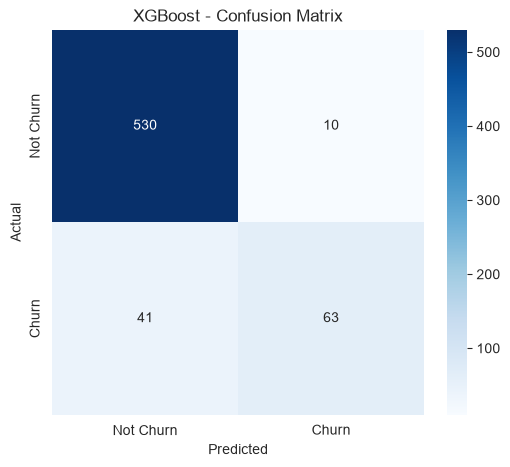

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [79]:
# Create cumulative lift and gain data

xgb_results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_proba_xgb
})

xgb_results = xgb_results.sort_values(
    "Probability",
    ascending=False
).reset_index(drop=True)

xgb_results["Cumulative Churn"] = (
    xgb_results["Actual"].cumsum()
)

xgb_results["Percentage of Customers"] = (
    np.arange(1, len(xgb_results) + 1)
    / len(xgb_results)
)

total_churn = xgb_results["Actual"].sum()

xgb_results["Cumulative Gain"] = (
    xgb_results["Cumulative Churn"] / total_churn
)

xgb_results["Cumulative Lift"] = (
    xgb_results["Cumulative Gain"]
    / xgb_results["Percentage of Customers"]
)

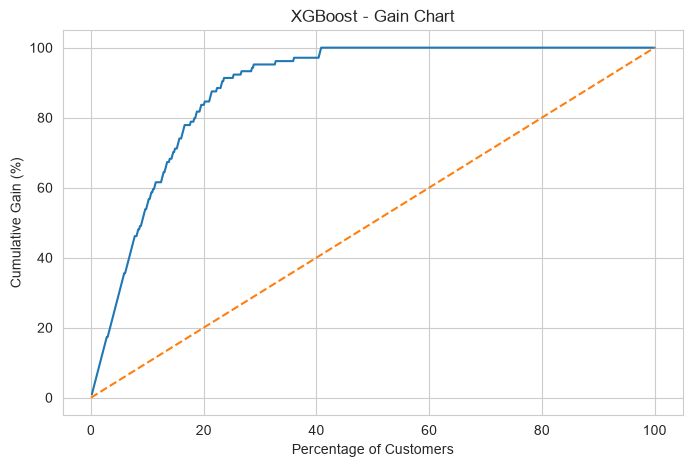

In [80]:
plt.figure(figsize=(8, 5))

plt.plot(
    xgb_results["Percentage of Customers"] * 100,
    xgb_results["Cumulative Gain"] * 100
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Percentage of Customers")
plt.ylabel("Cumulative Gain (%)")
plt.title("XGBoost - Gain Chart")

plt.show()

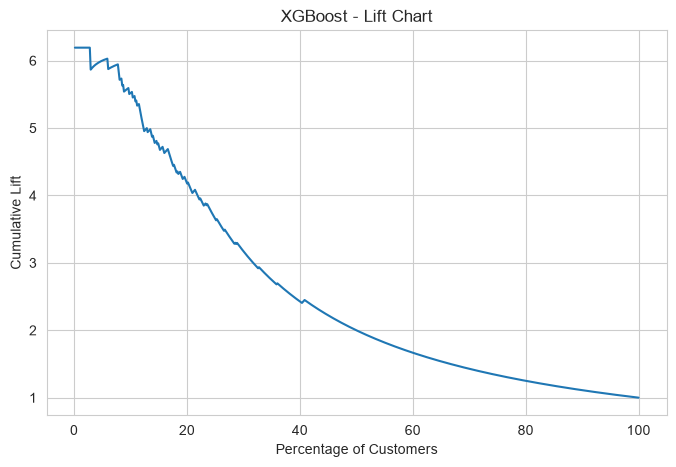

In [81]:
plt.figure(figsize=(8, 5))

plt.plot(
    xgb_results["Percentage of Customers"] * 100,
    xgb_results["Cumulative Lift"]
)

plt.xlabel("Percentage of Customers")
plt.ylabel("Cumulative Lift")
plt.title("XGBoost - Lift Chart")

plt.show()

#### 14.3.1 XGBoost Hyperparameter Tuning

Hyperparameter tuning is performed to search for a better combination of XGBoost parameters.

The tuning process uses Stratified K-Fold Cross-Validation and RandomizedSearchCV.

The primary optimization metric is **PR-AUC (Average Precision)** because churn datasets can be imbalanced and identifying churn customers is important.

The test set is kept separate and is not used during hyperparameter tuning.


In [82]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform, loguniform
from sklearn.pipeline import Pipeline

In [83]:
xgb_param_distributions = {
    "classifier__n_estimators": randint(300, 1501),

    "classifier__learning_rate": loguniform(
        0.01,
        0.3
    ),

    "classifier__max_depth": randint(
        3,
        13
    ),

    "classifier__min_child_weight": randint(
        1,
        11
    ),

    "classifier__subsample": uniform(
        0.6,
        0.4
    ),

    "classifier__colsample_bytree": uniform(
        0.6,
        0.4
    ),

    "classifier__gamma": loguniform(
        1e-8,
        5
    ),

    "classifier__reg_alpha": loguniform(
        1e-8,
        10
    ),

    "classifier__reg_lambda": loguniform(
        0.1,
        20
    )
}

In [84]:
xgb_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [85]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [86]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_distributions,

    n_iter=80,

    cv=xgb_cv,

    scoring="average_precision",

    n_jobs=-1,

    return_train_score=True,

    random_state=RANDOM_STATE,

    verbose=2
)

xgb_random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': <scipy.stats....0021B6EBBAFD0>, 'classifier__gamma': <scipy.stats....0021B6EDEF7D0>, 'classifier__learning_rate': <scipy.stats....0021B6EB8F2D0>, 'classifier__max_depth': <scipy.stats....0021B6EC362D0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",80
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trad

In [87]:
print("Best PR-AUC Score:")
print(xgb_random_search.best_score_)

print("\nBest Parameters:")
print(xgb_random_search.best_params_)

Best PR-AUC Score:
0.8331387447052613

Best Parameters:
{'classifier__colsample_bytree': np.float64(0.9921326334864182), 'classifier__gamma': np.float64(4.523085746134871e-08), 'classifier__learning_rate': np.float64(0.028284699212698362), 'classifier__max_depth': 9, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 427, 'classifier__reg_alpha': np.float64(2.2603818105733772e-05), 'classifier__reg_lambda': np.float64(0.8094628171962688), 'classifier__subsample': np.float64(0.9376852562905246)}


In [88]:
best_xgb_model = xgb_random_search.best_estimator_

In [89]:
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

y_proba_xgb_tuned = (
    best_xgb_model.predict_proba(X_test)[:, 1]
)

In [90]:
# Basic metrics

accuracy_xgb_tuned = accuracy_score(
    y_test,
    y_pred_xgb_tuned
)

precision_xgb_tuned = precision_score(
    y_test,
    y_pred_xgb_tuned,
    zero_division=0
)

recall_xgb_tuned = recall_score(
    y_test,
    y_pred_xgb_tuned,
    zero_division=0
)

f1_xgb_tuned = f1_score(
    y_test,
    y_pred_xgb_tuned,
    zero_division=0
)

roc_auc_xgb_tuned = roc_auc_score(
    y_test,
    y_proba_xgb_tuned
)

pr_auc_xgb_tuned = average_precision_score(
    y_test,
    y_proba_xgb_tuned
)

log_loss_xgb_tuned = log_loss(
    y_test,
    y_proba_xgb_tuned
)

brier_xgb_tuned = brier_score_loss(
    y_test,
    y_proba_xgb_tuned
)

# Confusion matrix

tn_xgb_tuned, fp_xgb_tuned, fn_xgb_tuned, tp_xgb_tuned = (
    confusion_matrix(
        y_test,
        y_pred_xgb_tuned
    ).ravel()
)

# Lift and Gain @ 10%

xgb_tuned_results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_proba_xgb_tuned
})

xgb_tuned_results = xgb_tuned_results.sort_values(
    "Probability",
    ascending=False
).reset_index(drop=True)

top_10_count_xgb_tuned = max(
    1,
    int(len(xgb_tuned_results) * 0.10)
)

top_10_xgb_tuned = xgb_tuned_results.iloc[
    :top_10_count_xgb_tuned
]

total_churn_xgb_tuned = (
    xgb_tuned_results["Actual"].sum()
)

top_10_churn_xgb_tuned = (
    top_10_xgb_tuned["Actual"].sum()
)

if total_churn_xgb_tuned > 0:

    lift_10_xgb_tuned = (
        (top_10_churn_xgb_tuned / top_10_count_xgb_tuned)
        /
        (total_churn_xgb_tuned / len(xgb_tuned_results))
    )

    gain_10_xgb_tuned = (
        top_10_churn_xgb_tuned
        / total_churn_xgb_tuned
    )

else:

    lift_10_xgb_tuned = np.nan
    gain_10_xgb_tuned = np.nan

# Cost-Sensitive Metrics

COST_FALSE_POSITIVE = 1
COST_FALSE_NEGATIVE = 5

total_cost_xgb_tuned = (
    fp_xgb_tuned * COST_FALSE_POSITIVE
    +
    fn_xgb_tuned * COST_FALSE_NEGATIVE
)

cost_per_customer_xgb_tuned = (
    total_cost_xgb_tuned / len(y_test)
)

# Single Metrics DataFrame

xgb_tuned_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score",
        "True Negatives (TN)",
        "False Positives (FP)",
        "False Negatives (FN)",
        "True Positives (TP)",
        "Lift @ 10%",
        "Gain @ 10%",
        "Total Cost",
        "Cost per Customer"
    ],

    "Value": [
        accuracy_xgb_tuned,
        precision_xgb_tuned,
        recall_xgb_tuned,
        f1_xgb_tuned,
        roc_auc_xgb_tuned,
        pr_auc_xgb_tuned,
        log_loss_xgb_tuned,
        brier_xgb_tuned,
        tn_xgb_tuned,
        fp_xgb_tuned,
        fn_xgb_tuned,
        tp_xgb_tuned,
        lift_10_xgb_tuned,
        gain_10_xgb_tuned,
        total_cost_xgb_tuned,
        cost_per_customer_xgb_tuned
    ]
})

xgb_tuned_metrics_df

,Metric,Value
0,Accuracy,0.913043
1,Precision,0.807692
2,Recall,0.605769
3,F1-Score,0.692308
4,ROC-AUC,0.960773
5,PR-AUC,0.848929
6,Log Loss,0.204388
7,Brier Score,0.060439
8,True Negatives (TN),525.000000
9,False Positives (FP),15.000000


In [91]:
xgb_baseline_vs_tuned = pd.DataFrame({
    "Metric": xgb_metrics_df["Metric"],


    "Normal XGBoost": xgb_metrics_df["Value"],

    "Tuned XGBoost": xgb_tuned_metrics_df["Value"]

})

xgb_baseline_vs_tuned["Improvement"] = (
    xgb_baseline_vs_tuned["Tuned XGBoost"] -
    xgb_baseline_vs_tuned["Normal XGBoost"]
)

xgb_baseline_vs_tuned.round(4)

,Metric,Normal XGBoost,Tuned XGBoost,Improvement
0,Accuracy,0.9208,0.9130,-0.0078
1,Precision,0.8630,0.8077,-0.0553
2,Recall,0.6058,0.6058,0.0000
3,F1-Score,0.7119,0.6923,-0.0196
4,ROC-AUC,0.9615,0.9608,-0.0007
5,PR-AUC,0.8465,0.8489,0.0025
6,Log Loss,0.2088,0.2044,-0.0044
7,Brier Score,0.0604,0.0604,-0.0000
8,True Negatives (TN),530.0000,525.0000,-5.0000
9,False Positives (FP),10.0000,15.0000,5.0000


## 14.4 CatBoost Classifier

CatBoost is a gradient boosting classification algorithm designed for structured/tabular data.

It is added as an additional churn prediction model to compare its performance with Logistic Regression, Random Forest, and XGBoost.

The existing preprocessing pipeline is used so that CatBoost follows the same train-test preprocessing workflow as the other models.

The model produces both:

* Churn class predictions
* Churn probabilities

The probabilities are used for ROC-AUC, PR-AUC, Log Loss, Brier Score, Lift and Gain analysis.


In [92]:
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline

print("CatBoost imported successfully.")

CatBoost imported successfully.


In [93]:
catboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            CatBoostClassifier(
                iterations=500,
                learning_rate=0.05,
                depth=6,
                l2_leaf_reg=3,
                loss_function="Logloss",
                eval_metric="AUC",
                random_seed=RANDOM_STATE,
                verbose=False,
                thread_count=-1,
                auto_class_weights="Balanced"
            )
        )
    ]
)

# Train CatBoost
catboost_model.fit(
    X_train,
    y_train
)

print("CatBoost model trained successfully.")

CatBoost model trained successfully.


In [94]:
# Predicted class
y_pred_catboost = catboost_model.predict(X_test)

# Convert predictions to 1-D array
y_pred_catboost = np.asarray(
    y_pred_catboost
).ravel()

# Predicted churn probability
y_proba_catboost = catboost_model.predict_proba(
    X_test
)[:, 1]

print("CatBoost predictions generated successfully.")
print("Number of test predictions:", len(y_pred_catboost))

CatBoost predictions generated successfully.
Number of test predictions: 644


In [95]:
# 1. Basic Classification Metrics

accuracy_catboost = accuracy_score(
    y_test,
    y_pred_catboost
)

precision_catboost = precision_score(
    y_test,
    y_pred_catboost,
    zero_division=0
)

recall_catboost = recall_score(
    y_test,
    y_pred_catboost,
    zero_division=0
)

f1_catboost = f1_score(
    y_test,
    y_pred_catboost,
    zero_division=0
)


# 2. Probability-Based Metrics

roc_auc_catboost = roc_auc_score(
    y_test,
    y_proba_catboost
)

pr_auc_catboost = average_precision_score(
    y_test,
    y_proba_catboost
)

logloss_catboost = log_loss(
    y_test,
    y_proba_catboost
)

brier_catboost = brier_score_loss(
    y_test,
    y_proba_catboost
)


# 3. Confusion Matrix

tn_catboost, fp_catboost, fn_catboost, tp_catboost = (
    confusion_matrix(
        y_test,
        y_pred_catboost,
        labels=[0, 1]
    ).ravel()
)


# 4. Lift & Gain @ 10%

catboost_eval = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": y_pred_catboost,
    "Churn_Probability": y_proba_catboost
})

catboost_eval = catboost_eval.sort_values(
    by="Churn_Probability",
    ascending=False
).reset_index(drop=True)

top_10_count_catboost = max(
    1,
    int(np.ceil(len(catboost_eval) * 0.10))
)

top_10_catboost = catboost_eval.iloc[
    :top_10_count_catboost
]

overall_churn_rate_catboost = (
    catboost_eval["Actual"].mean()
)

top_10_churn_rate_catboost = (
    top_10_catboost["Actual"].mean()
)

lift_at_10_catboost = (
    top_10_churn_rate_catboost
    / overall_churn_rate_catboost
    if overall_churn_rate_catboost > 0
    else np.nan
)

total_churners_catboost = (
    catboost_eval["Actual"].sum()
)

gain_at_10_catboost = (
    top_10_catboost["Actual"].sum()
    / total_churners_catboost
    if total_churners_catboost > 0
    else np.nan
)

gain_at_10_catboost_pct = (
    gain_at_10_catboost * 100
)


# 5. Cost-Sensitive Metrics

COST_FALSE_POSITIVE = 1
COST_FALSE_NEGATIVE = 5

total_cost_catboost = (
    fp_catboost * COST_FALSE_POSITIVE
    +
    fn_catboost * COST_FALSE_NEGATIVE
)

cost_per_customer_catboost = (
    total_cost_catboost / len(y_test)
)


# 6. Single Evaluation DataFrame

catboost_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score",
        "True Negatives (TN)",
        "False Positives (FP)",
        "False Negatives (FN)",
        "True Positives (TP)",
        "Lift @ 10%",
        "Gain @ 10%",
        "Total Cost",
        "Cost per Customer"
    ],

    "Value": [
        accuracy_catboost,
        precision_catboost,
        recall_catboost,
        f1_catboost,
        roc_auc_catboost,
        pr_auc_catboost,
        logloss_catboost,
        brier_catboost,
        tn_catboost,
        fp_catboost,
        fn_catboost,
        tp_catboost,
        lift_at_10_catboost,
        gain_at_10_catboost,
        total_cost_catboost,
        cost_per_customer_catboost
    ]
})

catboost_metrics_df

,Metric,Value
0,Accuracy,0.922360
1,Precision,0.787234
2,Recall,0.711538
3,F1-Score,0.747475
4,ROC-AUC,0.959491
5,PR-AUC,0.857471
6,Log Loss,0.186219
7,Brier Score,0.056840
8,True Negatives (TN),520.000000
9,False Positives (FP),20.000000


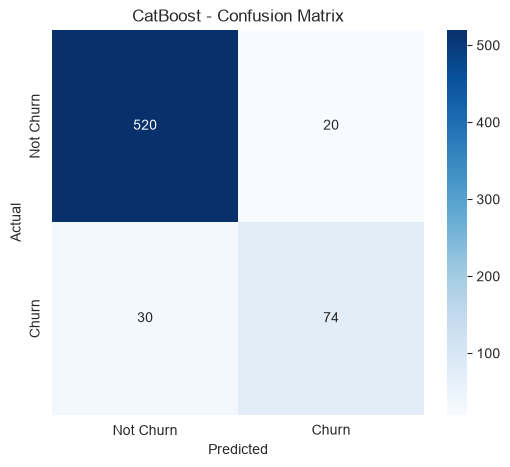

In [96]:
cm_catboost = confusion_matrix(
    y_test,
    y_pred_catboost,
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_catboost,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("CatBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [97]:
catboost_results = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Probability": y_proba_catboost
})

catboost_results = catboost_results.sort_values(
    "Probability",
    ascending=False
).reset_index(drop=True)

catboost_results["Cumulative Churn"] = (
    catboost_results["Actual"].cumsum()
)

catboost_results["Percentage of Customers"] = (
    np.arange(1, len(catboost_results) + 1)
    / len(catboost_results)
)

total_churn_catboost = (
    catboost_results["Actual"].sum()
)

catboost_results["Cumulative Gain"] = (
    catboost_results["Cumulative Churn"]
    / total_churn_catboost
)

catboost_results["Cumulative Lift"] = (
    catboost_results["Cumulative Gain"]
    / catboost_results["Percentage of Customers"]
)

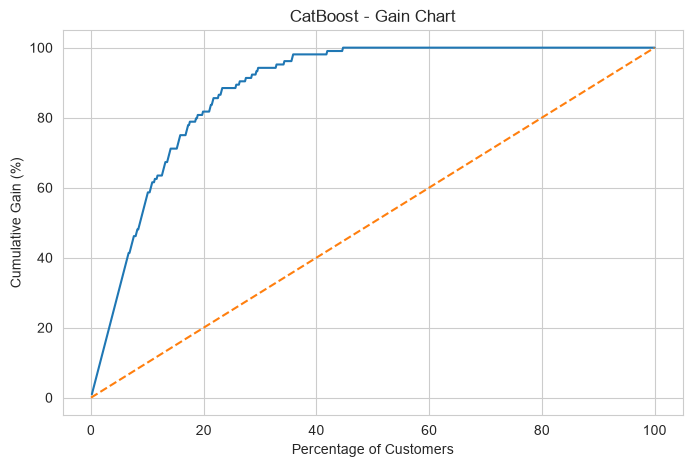

In [98]:
plt.figure(figsize=(8, 5))

plt.plot(
    catboost_results["Percentage of Customers"] * 100,
    catboost_results["Cumulative Gain"] * 100
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Percentage of Customers")
plt.ylabel("Cumulative Gain (%)")
plt.title("CatBoost - Gain Chart")

plt.show()

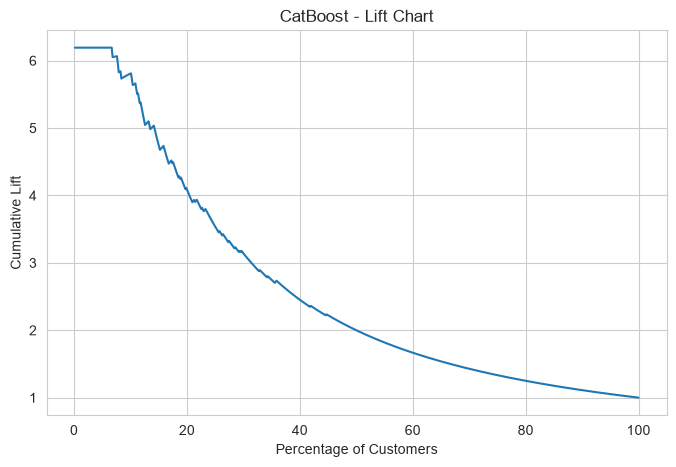

In [99]:
plt.figure(figsize=(8, 5))

plt.plot(
    catboost_results["Percentage of Customers"] * 100,
    catboost_results["Cumulative Lift"]
)

plt.xlabel("Percentage of Customers")
plt.ylabel("Cumulative Lift")
plt.title("CatBoost - Lift Chart")

plt.show()

## 14.4.2 CatBoost Hyperparameter Tuning

RandomizedSearchCV is used to search for a stronger combination of CatBoost hyperparameters.

The tuning objective is PR-AUC using 5-fold Stratified Cross-Validation.

The test set remains completely separate from the hyperparameter search.

Important CatBoost parameters being tuned include:

* Number of iterations
* Learning rate
* Tree depth
* L2 regularization
* Random strength
* Bagging temperature
* Border count


In [100]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform, loguniform

In [101]:
catboost_param_distributions = {

    "classifier__iterations": randint(
        300,
        1501
    ),

    "classifier__learning_rate": loguniform(
        0.01,
        0.3
    ),

    "classifier__depth": randint(
        4,
        11
    ),

    "classifier__l2_leaf_reg": loguniform(
        1,
        20
    ),

    "classifier__random_strength": uniform(
        0,
        3
    ),

    "classifier__bagging_temperature": uniform(
        0,
        3
    ),

    "classifier__border_count": randint(
        32,
        256
    )
}

In [102]:
catboost_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [103]:
catboost_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            CatBoostClassifier(
                loss_function="Logloss",
                eval_metric="AUC",
                random_seed=RANDOM_STATE,
                verbose=False,
                thread_count=-1,
                auto_class_weights="Balanced"
            )
        )
    ]
)

In [104]:
catboost_random_search = RandomizedSearchCV(
    estimator=catboost_tuning_pipeline,

    param_distributions=catboost_param_distributions,

    n_iter=80,

    cv=catboost_cv,

    scoring="average_precision",

    n_jobs=-1,

    return_train_score=True,

    random_state=RANDOM_STATE,

    verbose=2
)

catboost_random_search.fit(
    X_train,
    y_train
)

print("CatBoost hyperparameter tuning completed.")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
CatBoost hyperparameter tuning completed.


In [105]:
print("Best Cross-Validated PR-AUC:")
print(catboost_random_search.best_score_)

print("\nBest CatBoost Hyperparameters:")

for parameter, value in (
    catboost_random_search.best_params_.items()
):
    print(f"{parameter}: {value}")

Best Cross-Validated PR-AUC:
0.858996031578591

Best CatBoost Hyperparameters:
classifier__bagging_temperature: 1.349262400109297
classifier__border_count: 233
classifier__depth: 9
classifier__iterations: 1295
classifier__l2_leaf_reg: 5.996333882412659
classifier__learning_rate: 0.22999586428143728
classifier__random_strength: 0.2654775061557585


In [106]:
best_catboost_model = (
    catboost_random_search.best_estimator_
)

print("Best tuned CatBoost model selected.")

Best tuned CatBoost model selected.


In [107]:
y_pred_catboost_tuned = (
    best_catboost_model.predict(X_test)
)

y_pred_catboost_tuned = np.asarray(
    y_pred_catboost_tuned
).ravel()

y_proba_catboost_tuned = (
    best_catboost_model.predict_proba(X_test)[:, 1]
)

print("Tuned CatBoost predictions generated.")

Tuned CatBoost predictions generated.


In [108]:
# 1. Basic Classification Metrics

accuracy_catboost_tuned = accuracy_score(
    y_test,
    y_pred_catboost_tuned
)

precision_catboost_tuned = precision_score(
    y_test,
    y_pred_catboost_tuned,
    zero_division=0
)

recall_catboost_tuned = recall_score(
    y_test,
    y_pred_catboost_tuned,
    zero_division=0
)

f1_catboost_tuned = f1_score(
    y_test,
    y_pred_catboost_tuned,
    zero_division=0
)


# 2. Probability Metrics

roc_auc_catboost_tuned = roc_auc_score(
    y_test,
    y_proba_catboost_tuned
)

pr_auc_catboost_tuned = average_precision_score(
    y_test,
    y_proba_catboost_tuned
)

logloss_catboost_tuned = log_loss(
    y_test,
    y_proba_catboost_tuned
)

brier_catboost_tuned = brier_score_loss(
    y_test,
    y_proba_catboost_tuned
)


# 3. Confusion Matrix

tn_catboost_tuned, fp_catboost_tuned, fn_catboost_tuned, tp_catboost_tuned = (
    confusion_matrix(
        y_test,
        y_pred_catboost_tuned,
        labels=[0, 1]
    ).ravel()
)


# 4. Lift & Gain @ 10%

catboost_tuned_eval = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": y_pred_catboost_tuned,
    "Churn_Probability": y_proba_catboost_tuned
})

catboost_tuned_eval = catboost_tuned_eval.sort_values(
    by="Churn_Probability",
    ascending=False
).reset_index(drop=True)

top_10_count_catboost_tuned = max(
    1,
    int(np.ceil(len(catboost_tuned_eval) * 0.10))
)

top_10_catboost_tuned = catboost_tuned_eval.iloc[
    :top_10_count_catboost_tuned
]

overall_churn_rate_catboost_tuned = (
    catboost_tuned_eval["Actual"].mean()
)

top_10_churn_rate_catboost_tuned = (
    top_10_catboost_tuned["Actual"].mean()
)

lift_at_10_catboost_tuned = (
    top_10_churn_rate_catboost_tuned
    / overall_churn_rate_catboost_tuned
    if overall_churn_rate_catboost_tuned > 0
    else np.nan
)

total_churners_catboost_tuned = (
    catboost_tuned_eval["Actual"].sum()
)

gain_at_10_catboost_tuned = (
    top_10_catboost_tuned["Actual"].sum()
    / total_churners_catboost_tuned
    if total_churners_catboost_tuned > 0
    else np.nan
)


# 5. Cost-Sensitive Metrics

total_cost_catboost_tuned = (
    fp_catboost_tuned * COST_FALSE_POSITIVE
    +
    fn_catboost_tuned * COST_FALSE_NEGATIVE
)

cost_per_customer_catboost_tuned = (
    total_cost_catboost_tuned / len(y_test)
)


# 6. Final Tuned CatBoost Metrics DataFrame

catboost_tuned_metrics_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score",
        "True Negatives (TN)",
        "False Positives (FP)",
        "False Negatives (FN)",
        "True Positives (TP)",
        "Lift @ 10%",
        "Gain @ 10%",
        "Total Cost",
        "Cost per Customer"
    ],

    "Value": [
        accuracy_catboost_tuned,
        precision_catboost_tuned,
        recall_catboost_tuned,
        f1_catboost_tuned,
        roc_auc_catboost_tuned,
        pr_auc_catboost_tuned,
        logloss_catboost_tuned,
        brier_catboost_tuned,
        tn_catboost_tuned,
        fp_catboost_tuned,
        fn_catboost_tuned,
        tp_catboost_tuned,
        lift_at_10_catboost_tuned,
        gain_at_10_catboost_tuned,
        total_cost_catboost_tuned,
        cost_per_customer_catboost_tuned
    ]
})

catboost_tuned_metrics_df

,Metric,Value
0,Accuracy,0.922360
1,Precision,0.793478
2,Recall,0.701923
3,F1-Score,0.744898
4,ROC-AUC,0.962144
5,PR-AUC,0.861939
6,Log Loss,0.207622
7,Brier Score,0.059971
8,True Negatives (TN),521.000000
9,False Positives (FP),19.000000


In [109]:
catboost_baseline_vs_tuned = pd.DataFrame({

    "Metric": catboost_metrics_df["Metric"],

    "Normal CatBoost": catboost_metrics_df["Value"],

    "Tuned CatBoost": catboost_tuned_metrics_df["Value"]
})

catboost_baseline_vs_tuned["Improvement"] = (
    catboost_baseline_vs_tuned["Tuned CatBoost"]
    -
    catboost_baseline_vs_tuned["Normal CatBoost"]
)

catboost_baseline_vs_tuned.round(4)

,Metric,Normal CatBoost,Tuned CatBoost,Improvement
0,Accuracy,0.9224,0.9224,0.0000
1,Precision,0.7872,0.7935,0.0062
2,Recall,0.7115,0.7019,-0.0096
3,F1-Score,0.7475,0.7449,-0.0026
4,ROC-AUC,0.9595,0.9621,0.0027
5,PR-AUC,0.8575,0.8619,0.0045
6,Log Loss,0.1862,0.2076,0.0214
7,Brier Score,0.0568,0.0600,0.0031
8,True Negatives (TN),520.0000,521.0000,1.0000
9,False Positives (FP),20.0000,19.0000,-1.0000


### 14.5 LightGBM Classifier

LightGBM (Light Gradient Boosting Machine) is a gradient boosting algorithm designed for efficient and high-performance learning on structured/tabular datasets.

It is added as an additional churn classification model and will be evaluated using the same metrics used for Logistic Regression, Random Forest, XGBoost, and CatBoost.

The model will generate both class predictions and churn probabilities.


In [110]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

print("LightGBM imported successfully.")

LightGBM imported successfully.


In [111]:
lightgbm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LGBMClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=-1,
                num_leaves=31,
                min_child_samples=20,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0,
                reg_lambda=1,
                class_weight="balanced",
                objective="binary",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1
            )
        )
    ]
)

# Train model
lightgbm_model.fit(
    X_train,
    y_train
)

print("LightGBM model trained successfully.")

LightGBM model trained successfully.


In [112]:
y_pred_lgbm = lightgbm_model.predict(X_test)

y_pred_lgbm = np.asarray(
    y_pred_lgbm
).ravel()

y_proba_lgbm = (
    lightgbm_model.predict_proba(X_test)[:, 1]
)

print("LightGBM predictions generated successfully.")

LightGBM predictions generated successfully.


In [113]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix
)

import pandas as pd
import numpy as np

In [114]:
# 1. Classification Metrics

accuracy_lgbm = accuracy_score(
    y_test,
    y_pred_lgbm
)

precision_lgbm = precision_score(
    y_test,
    y_pred_lgbm,
    zero_division=0
)

recall_lgbm = recall_score(
    y_test,
    y_pred_lgbm,
    zero_division=0
)

f1_lgbm = f1_score(
    y_test,
    y_pred_lgbm,
    zero_division=0
)


# 2. Probability-Based Metrics

roc_auc_lgbm = roc_auc_score(
    y_test,
    y_proba_lgbm
)

pr_auc_lgbm = average_precision_score(
    y_test,
    y_proba_lgbm
)

logloss_lgbm = log_loss(
    y_test,
    y_proba_lgbm
)

brier_lgbm = brier_score_loss(
    y_test,
    y_proba_lgbm
)


# 3. Confusion Matrix

tn_lgbm, fp_lgbm, fn_lgbm, tp_lgbm = (
    confusion_matrix(
        y_test,
        y_pred_lgbm,
        labels=[0, 1]
    ).ravel()
)


# 4. Lift and Gain @ 10%

lgbm_eval = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": y_pred_lgbm,
    "Churn_Probability": y_proba_lgbm
})

lgbm_eval = lgbm_eval.sort_values(
    "Churn_Probability",
    ascending=False
).reset_index(drop=True)

top_10_count_lgbm = max(
    1,
    int(np.ceil(len(lgbm_eval) * 0.10))
)

top_10_lgbm = lgbm_eval.iloc[
    :top_10_count_lgbm
]

overall_churn_rate_lgbm = (
    lgbm_eval["Actual"].mean()
)

top_10_churn_rate_lgbm = (
    top_10_lgbm["Actual"].mean()
)

lift_10_lgbm = (
    top_10_churn_rate_lgbm
    / overall_churn_rate_lgbm
    if overall_churn_rate_lgbm > 0
    else np.nan
)

total_churn_lgbm = (
    lgbm_eval["Actual"].sum()
)

gain_10_lgbm = (
    top_10_lgbm["Actual"].sum()
    / total_churn_lgbm
    if total_churn_lgbm > 0
    else np.nan
)


# 5. Cost-Sensitive Metrics

COST_FALSE_POSITIVE = 1
COST_FALSE_NEGATIVE = 5

total_cost_lgbm = (
    fp_lgbm * COST_FALSE_POSITIVE
    +
    fn_lgbm * COST_FALSE_NEGATIVE
)

cost_per_customer_lgbm = (
    total_cost_lgbm / len(y_test)
)


# 6. Single Metrics DataFrame

lgbm_metrics_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score",
        "True Negatives (TN)",
        "False Positives (FP)",
        "False Negatives (FN)",
        "True Positives (TP)",
        "Lift @ 10%",
        "Gain @ 10%",
        "Total Cost",
        "Cost per Customer"
    ],

    "Value": [
        accuracy_lgbm,
        precision_lgbm,
        recall_lgbm,
        f1_lgbm,
        roc_auc_lgbm,
        pr_auc_lgbm,
        logloss_lgbm,
        brier_lgbm,
        tn_lgbm,
        fp_lgbm,
        fn_lgbm,
        tp_lgbm,
        lift_10_lgbm,
        gain_10_lgbm,
        total_cost_lgbm,
        cost_per_customer_lgbm
    ]
})

lgbm_metrics_df

,Metric,Value
0,Accuracy,0.909938
1,Precision,0.750000
2,Recall,0.663462
3,F1-Score,0.704082
4,ROC-AUC,0.956410
5,PR-AUC,0.835250
6,Log Loss,0.234794
7,Brier Score,0.067077
8,True Negatives (TN),517.000000
9,False Positives (FP),23.000000


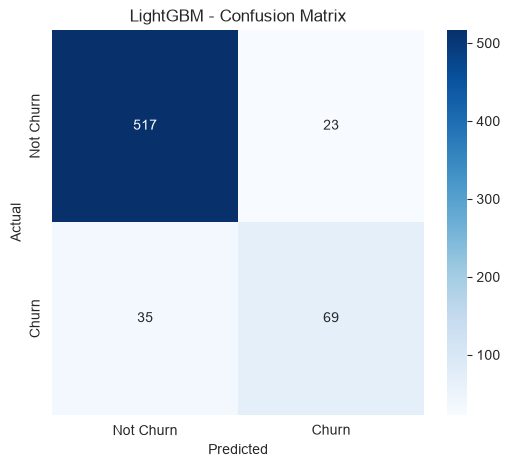

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_lgbm = confusion_matrix(
    y_test,
    y_pred_lgbm,
    labels=[0, 1]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("LightGBM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [116]:
lgbm_results = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Probability": y_proba_lgbm
})

lgbm_results = lgbm_results.sort_values(
    "Probability",
    ascending=False
).reset_index(drop=True)

lgbm_results["Cumulative Churn"] = (
    lgbm_results["Actual"].cumsum()
)

lgbm_results["Percentage of Customers"] = (
    np.arange(1, len(lgbm_results) + 1)
    / len(lgbm_results)
)

total_churn_lgbm = (
    lgbm_results["Actual"].sum()
)

lgbm_results["Cumulative Gain"] = (
    lgbm_results["Cumulative Churn"]
    / total_churn_lgbm
)

lgbm_results["Cumulative Lift"] = (
    lgbm_results["Cumulative Gain"]
    / lgbm_results["Percentage of Customers"]
)

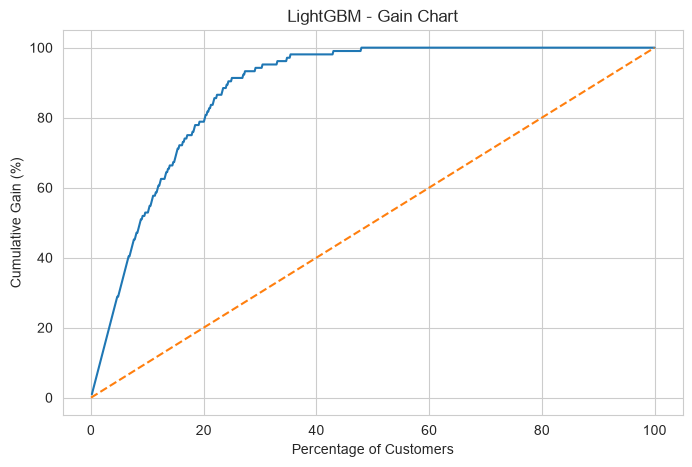

In [117]:
plt.figure(figsize=(8, 5))

plt.plot(
    lgbm_results["Percentage of Customers"] * 100,
    lgbm_results["Cumulative Gain"] * 100
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Percentage of Customers")
plt.ylabel("Cumulative Gain (%)")
plt.title("LightGBM - Gain Chart")

plt.show()

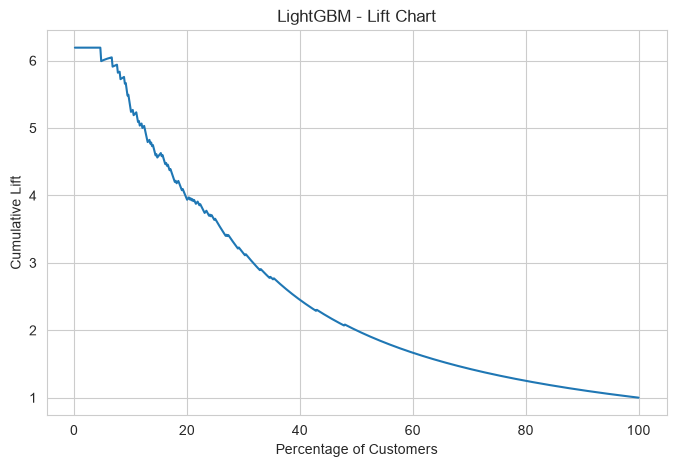

In [118]:
plt.figure(figsize=(8, 5))

plt.plot(
    lgbm_results["Percentage of Customers"] * 100,
    lgbm_results["Cumulative Lift"]
)

plt.xlabel("Percentage of Customers")
plt.ylabel("Cumulative Lift")
plt.title("LightGBM - Lift Chart")

plt.show()

#### 14.5.1 LightGBM Hyperparameter Tuning

RandomizedSearchCV is used to search for a stronger combination of LightGBM hyperparameters.

The tuning uses 5-fold Stratified Cross-Validation.

PR-AUC (Average Precision) is used as the optimization metric because the churn target is imbalanced.

The test set is not used during hyperparameter tuning.


In [119]:
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

from scipy.stats import (
    randint,
    uniform,
    loguniform
)

In [120]:
lgbm_param_distributions = {

    "classifier__n_estimators": randint(
        300,
        1501
    ),

    "classifier__learning_rate": loguniform(
        0.01,
        0.3
    ),

    "classifier__num_leaves": randint(
        15,
        151
    ),

    "classifier__max_depth": [
        -1,
        3,
        5,
        7,
        10,
        12,
        15,
        20
    ],

    "classifier__min_child_samples": randint(
        5,
        101
    ),

    "classifier__subsample": uniform(
        0.6,
        0.4
    ),

    "classifier__colsample_bytree": uniform(
        0.6,
        0.4
    ),

    "classifier__reg_alpha": loguniform(
        1e-8,
        10
    ),

    "classifier__reg_lambda": loguniform(
        0.1,
        20
    )
}

In [121]:
lgbm_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [122]:
lgbm_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            LGBMClassifier(
                objective="binary",
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1
            )
        )
    ]
)

In [123]:
lgbm_random_search = RandomizedSearchCV(
    estimator=lgbm_tuning_pipeline,

    param_distributions=lgbm_param_distributions,

    n_iter=80,

    cv=lgbm_cv,

    scoring="average_precision",

    n_jobs=-1,

    return_train_score=True,

    random_state=RANDOM_STATE,

    verbose=2
)

lgbm_random_search.fit(
    X_train,
    y_train
)

print("LightGBM hyperparameter tuning completed.")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LightGBM hyperparameter tuning completed.


In [124]:
print("Best Cross-Validated PR-AUC:")
print(lgbm_random_search.best_score_)

print("\nBest LightGBM Hyperparameters:")

for parameter, value in (
    lgbm_random_search.best_params_.items()
):
    print(f"{parameter}: {value}")

Best Cross-Validated PR-AUC:
0.834056147178844

Best LightGBM Hyperparameters:
classifier__colsample_bytree: 0.7380284992106732
classifier__learning_rate: 0.08649955121393718
classifier__max_depth: 12
classifier__min_child_samples: 6
classifier__n_estimators: 1376
classifier__num_leaves: 82
classifier__reg_alpha: 5.3417054540145544e-08
classifier__reg_lambda: 0.7089016569132875
classifier__subsample: 0.6968639753109703


In [125]:
best_lgbm_model = (
    lgbm_random_search.best_estimator_
)

print("Best tuned LightGBM model selected.")

Best tuned LightGBM model selected.


In [126]:
y_pred_lgbm_tuned = (
    best_lgbm_model.predict(X_test)
)

y_pred_lgbm_tuned = np.asarray(
    y_pred_lgbm_tuned
).ravel()

y_proba_lgbm_tuned = (
    best_lgbm_model.predict_proba(X_test)[:, 1]
)

print("Tuned LightGBM predictions generated.")

Tuned LightGBM predictions generated.


In [127]:
# 1. Classification Metrics

accuracy_lgbm_tuned = accuracy_score(
    y_test,
    y_pred_lgbm_tuned
)

precision_lgbm_tuned = precision_score(
    y_test,
    y_pred_lgbm_tuned,
    zero_division=0
)

recall_lgbm_tuned = recall_score(
    y_test,
    y_pred_lgbm_tuned,
    zero_division=0
)

f1_lgbm_tuned = f1_score(
    y_test,
    y_pred_lgbm_tuned,
    zero_division=0
)


# 2. Probability Metrics

roc_auc_lgbm_tuned = roc_auc_score(
    y_test,
    y_proba_lgbm_tuned
)

pr_auc_lgbm_tuned = average_precision_score(
    y_test,
    y_proba_lgbm_tuned
)

logloss_lgbm_tuned = log_loss(
    y_test,
    y_proba_lgbm_tuned
)

brier_lgbm_tuned = brier_score_loss(
    y_test,
    y_proba_lgbm_tuned
)


# 3. Confusion Matrix

tn_lgbm_tuned, fp_lgbm_tuned, fn_lgbm_tuned, tp_lgbm_tuned = (
    confusion_matrix(
        y_test,
        y_pred_lgbm_tuned,
        labels=[0, 1]
    ).ravel()
)


# 4. Lift & Gain @ 10%

lgbm_tuned_eval = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": y_pred_lgbm_tuned,
    "Churn_Probability": y_proba_lgbm_tuned
})

lgbm_tuned_eval = lgbm_tuned_eval.sort_values(
    "Churn_Probability",
    ascending=False
).reset_index(drop=True)

top_10_count_lgbm_tuned = max(
    1,
    int(np.ceil(len(lgbm_tuned_eval) * 0.10))
)

top_10_lgbm_tuned = lgbm_tuned_eval.iloc[
    :top_10_count_lgbm_tuned
]

overall_churn_rate_lgbm_tuned = (
    lgbm_tuned_eval["Actual"].mean()
)

top_10_churn_rate_lgbm_tuned = (
    top_10_lgbm_tuned["Actual"].mean()
)

lift_10_lgbm_tuned = (
    top_10_churn_rate_lgbm_tuned
    / overall_churn_rate_lgbm_tuned
    if overall_churn_rate_lgbm_tuned > 0
    else np.nan
)

total_churn_lgbm_tuned = (
    lgbm_tuned_eval["Actual"].sum()
)

gain_10_lgbm_tuned = (
    top_10_lgbm_tuned["Actual"].sum()
    / total_churn_lgbm_tuned
    if total_churn_lgbm_tuned > 0
    else np.nan
)


# 5. Cost-Sensitive Metrics

total_cost_lgbm_tuned = (
    fp_lgbm_tuned * COST_FALSE_POSITIVE
    +
    fn_lgbm_tuned * COST_FALSE_NEGATIVE
)

cost_per_customer_lgbm_tuned = (
    total_cost_lgbm_tuned / len(y_test)
)

# 6. Final Tuned Metrics DataFrame

lgbm_tuned_metrics_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score",
        "True Negatives (TN)",
        "False Positives (FP)",
        "False Negatives (FN)",
        "True Positives (TP)",
        "Lift @ 10%",
        "Gain @ 10%",
        "Total Cost",
        "Cost per Customer"
    ],

    "Value": [
        accuracy_lgbm_tuned,
        precision_lgbm_tuned,
        recall_lgbm_tuned,
        f1_lgbm_tuned,
        roc_auc_lgbm_tuned,
        pr_auc_lgbm_tuned,
        logloss_lgbm_tuned,
        brier_lgbm_tuned,
        tn_lgbm_tuned,
        fp_lgbm_tuned,
        fn_lgbm_tuned,
        tp_lgbm_tuned,
        lift_10_lgbm_tuned,
        gain_10_lgbm_tuned,
        total_cost_lgbm_tuned,
        cost_per_customer_lgbm_tuned
    ]
})

lgbm_tuned_metrics_df

,Metric,Value
0,Accuracy,0.914596
1,Precision,0.795181
2,Recall,0.634615
3,F1-Score,0.705882
4,ROC-AUC,0.961574
5,PR-AUC,0.837963
6,Log Loss,0.294752
7,Brier Score,0.068767
8,True Negatives (TN),523.000000
9,False Positives (FP),17.000000


In [128]:
lgbm_baseline_vs_tuned = pd.DataFrame({

    "Metric": lgbm_metrics_df["Metric"],

    "Normal LightGBM": lgbm_metrics_df["Value"],

    "Tuned LightGBM": lgbm_tuned_metrics_df["Value"]
})

lgbm_baseline_vs_tuned["Improvement"] = (
    lgbm_baseline_vs_tuned["Tuned LightGBM"]
    -
    lgbm_baseline_vs_tuned["Normal LightGBM"]
)

lgbm_baseline_vs_tuned.round(4)

,Metric,Normal LightGBM,Tuned LightGBM,Improvement
0,Accuracy,0.9099,0.9146,0.0047
1,Precision,0.7500,0.7952,0.0452
2,Recall,0.6635,0.6346,-0.0288
3,F1-Score,0.7041,0.7059,0.0018
4,ROC-AUC,0.9564,0.9616,0.0052
5,PR-AUC,0.8353,0.8380,0.0027
6,Log Loss,0.2348,0.2948,0.0600
7,Brier Score,0.0671,0.0688,0.0017
8,True Negatives (TN),517.0000,523.0000,6.0000
9,False Positives (FP),23.0000,17.0000,-6.0000


### 14.6 Extra Trees Classifier

Extra Trees (Extremely Randomized Trees) is an ensemble tree-based classification algorithm. It builds multiple highly randomized decision trees and combines their predictions.

For this churn prediction project, `class_weight="balanced"` is used because the churn dataset has class imbalance.


In [129]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline

extra_trees_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", ExtraTreesClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

extra_trees_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['Age','Gender','City',...,'Satisfaction_Level','Age_Group', 'Contract_Renewal_Status']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

In [130]:
import numpy as np

# Predictions
y_pred_extra_trees = np.asarray(
    extra_trees_model.predict(X_test)
).ravel()

# Probability of Churn = 1
y_proba_extra_trees = extra_trees_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [131]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix
)

# Basic metrics
accuracy_extra_trees = accuracy_score(
    y_test, y_pred_extra_trees
)

precision_extra_trees = precision_score(
    y_test, y_pred_extra_trees,
    zero_division=0
)

recall_extra_trees = recall_score(
    y_test, y_pred_extra_trees,
    zero_division=0
)

f1_extra_trees = f1_score(
    y_test, y_pred_extra_trees,
    zero_division=0
)

roc_auc_extra_trees = roc_auc_score(
    y_test, y_proba_extra_trees
)

pr_auc_extra_trees = average_precision_score(
    y_test, y_proba_extra_trees
)

log_loss_extra_trees = log_loss(
    y_test, y_proba_extra_trees
)

brier_extra_trees = brier_score_loss(
    y_test, y_proba_extra_trees
)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_extra_trees
).ravel()

# Cost-sensitive metrics
COST_FALSE_POSITIVE = 1
COST_FALSE_NEGATIVE = 5

total_cost_extra_trees = (
    fp * COST_FALSE_POSITIVE +
    fn * COST_FALSE_NEGATIVE
)

# Store all metrics in one DataFrame
extra_trees_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score",
        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "True Positive (TP)",
        "False Positive Cost",
        "False Negative Cost",
        "Total Cost"
    ],
    "Value": [
        accuracy_extra_trees,
        precision_extra_trees,
        recall_extra_trees,
        f1_extra_trees,
        roc_auc_extra_trees,
        pr_auc_extra_trees,
        log_loss_extra_trees,
        brier_extra_trees,
        tn,
        fp,
        fn,
        tp,
        fp * COST_FALSE_POSITIVE,
        fn * COST_FALSE_NEGATIVE,
        total_cost_extra_trees
    ]
})

extra_trees_metrics_df

,Metric,Value
0,Accuracy,0.875776
1,Precision,0.750000
2,Recall,0.346154
3,F1-Score,0.473684
4,ROC-AUC,0.827991
5,PR-AUC,0.601546
6,Log Loss,0.323218
7,Brier Score,0.095489
8,True Negative (TN),528.000000
9,False Positive (FP),12.000000


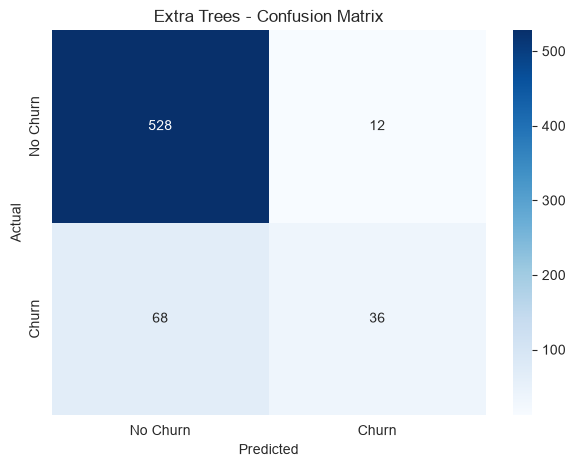

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_extra_trees = confusion_matrix(
    y_test,
    y_pred_extra_trees
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_extra_trees,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Extra Trees - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

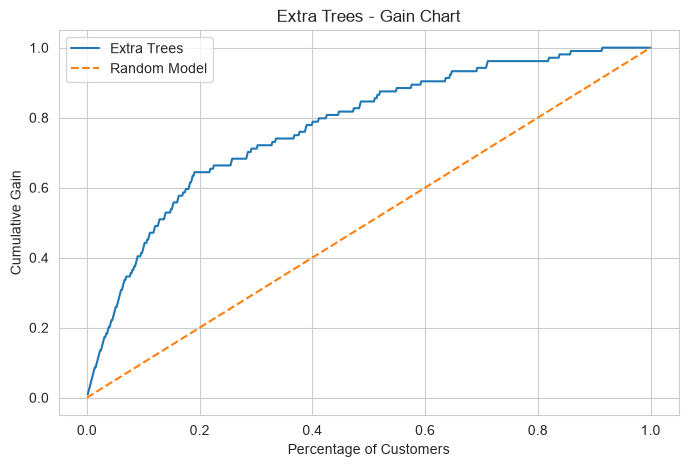

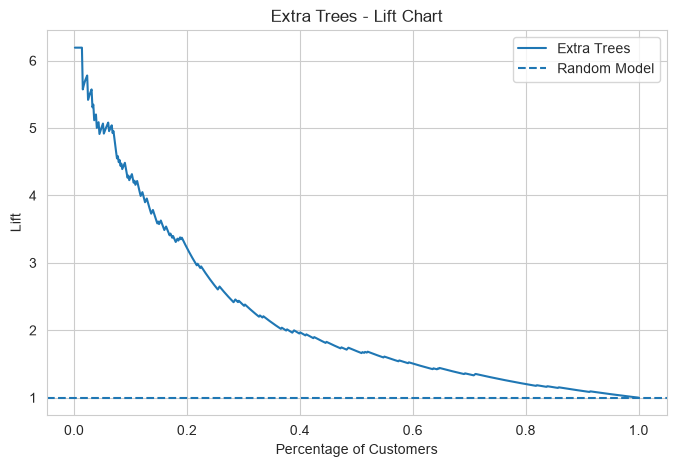

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframe
lift_gain_extra_trees = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Probability": y_proba_extra_trees
})

# Sort by predicted churn probability
lift_gain_extra_trees = lift_gain_extra_trees.sort_values(
    "Probability",
    ascending=False
).reset_index(drop=True)

# Cumulative calculations
lift_gain_extra_trees["Cumulative_Actual"] = (
    lift_gain_extra_trees["Actual"].cumsum()
)

total_churn = lift_gain_extra_trees["Actual"].sum()

lift_gain_extra_trees["Cumulative_Gain"] = (
    lift_gain_extra_trees["Cumulative_Actual"] / total_churn
)

lift_gain_extra_trees["Percentage_Sample"] = (
    np.arange(1, len(lift_gain_extra_trees) + 1)
    / len(lift_gain_extra_trees)
)

lift_gain_extra_trees["Lift"] = (
    lift_gain_extra_trees["Cumulative_Gain"]
    / lift_gain_extra_trees["Percentage_Sample"]
)

# Gain Chart
plt.figure(figsize=(8, 5))

plt.plot(
    lift_gain_extra_trees["Percentage_Sample"],
    lift_gain_extra_trees["Cumulative_Gain"],
    label="Extra Trees"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Model"
)

plt.xlabel("Percentage of Customers")
plt.ylabel("Cumulative Gain")
plt.title("Extra Trees - Gain Chart")
plt.legend()
plt.grid(True)
plt.show()

# Lift Chart
plt.figure(figsize=(8, 5))

plt.plot(
    lift_gain_extra_trees["Percentage_Sample"],
    lift_gain_extra_trees["Lift"],
    label="Extra Trees"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Random Model"
)

plt.xlabel("Percentage of Customers")
plt.ylabel("Lift")
plt.title("Extra Trees - Lift Chart")
plt.legend()
plt.grid(True)
plt.show()

In [134]:
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)
from scipy.stats import randint, uniform

extra_trees_param_distributions = {
    "classifier__n_estimators": randint(300, 1501),
    "classifier__max_depth": [None, 5, 10, 15, 20, 30, 40],
    "classifier__min_samples_split": randint(2, 21),
    "classifier__min_samples_leaf": randint(1, 11),
    "classifier__max_features": ["sqrt", "log2", None, 0.5, 0.7, 1.0],
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__class_weight": [
        "balanced",
        "balanced_subsample",
        None
    ],
    "classifier__bootstrap": [False, True]
}

extra_trees_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", ExtraTreesClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

extra_trees_random_search = RandomizedSearchCV(
    estimator=extra_trees_tuning_pipeline,
    param_distributions=extra_trees_param_distributions,
    n_iter=80,
    scoring="average_precision",
    cv=cv_strategy,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True
)

extra_trees_random_search.fit(
    X_train,
    y_train
)

print("Extra Trees tuning completed.")
print("\nBest PR-AUC CV Score:")
print(extra_trees_random_search.best_score_)

print("\nBest Parameters:")
print(extra_trees_random_search.best_params_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Extra Trees tuning completed.

Best PR-AUC CV Score:
0.7777211115844296

Best Parameters:
{'classifier__bootstrap': False, 'classifier__class_weight': None, 'classifier__criterion': 'gini', 'classifier__max_depth': 40, 'classifier__max_features': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 1325}


In [135]:
# Best tuned model
best_extra_trees_model = extra_trees_random_search.best_estimator_

# Predictions
y_pred_extra_trees_tuned = np.asarray(
    best_extra_trees_model.predict(X_test)
).ravel()

y_proba_extra_trees_tuned = (
    best_extra_trees_model.predict_proba(X_test)[:, 1]
)

# Metrics
accuracy_extra_trees_tuned = accuracy_score(
    y_test,
    y_pred_extra_trees_tuned
)

precision_extra_trees_tuned = precision_score(
    y_test,
    y_pred_extra_trees_tuned,
    zero_division=0
)

recall_extra_trees_tuned = recall_score(
    y_test,
    y_pred_extra_trees_tuned,
    zero_division=0
)

f1_extra_trees_tuned = f1_score(
    y_test,
    y_pred_extra_trees_tuned,
    zero_division=0
)

roc_auc_extra_trees_tuned = roc_auc_score(
    y_test,
    y_proba_extra_trees_tuned
)

pr_auc_extra_trees_tuned = average_precision_score(
    y_test,
    y_proba_extra_trees_tuned
)

log_loss_extra_trees_tuned = log_loss(
    y_test,
    y_proba_extra_trees_tuned
)

brier_extra_trees_tuned = brier_score_loss(
    y_test,
    y_proba_extra_trees_tuned
)

# Confusion matrix
tn_tuned, fp_tuned, fn_tuned, tp_tuned = confusion_matrix(
    y_test,
    y_pred_extra_trees_tuned
).ravel()

# Cost-sensitive evaluation
total_cost_extra_trees_tuned = (
    fp_tuned * COST_FALSE_POSITIVE +
    fn_tuned * COST_FALSE_NEGATIVE
)

# Final evaluation DataFrame
extra_trees_tuned_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score",
        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "True Positive (TP)",
        "False Positive Cost",
        "False Negative Cost",
        "Total Cost"
    ],
    "Value": [
        accuracy_extra_trees_tuned,
        precision_extra_trees_tuned,
        recall_extra_trees_tuned,
        f1_extra_trees_tuned,
        roc_auc_extra_trees_tuned,
        pr_auc_extra_trees_tuned,
        log_loss_extra_trees_tuned,
        brier_extra_trees_tuned,
        tn_tuned,
        fp_tuned,
        fn_tuned,
        tp_tuned,
        fp_tuned * COST_FALSE_POSITIVE,
        fn_tuned * COST_FALSE_NEGATIVE,
        total_cost_extra_trees_tuned
    ]
})

extra_trees_tuned_metrics_df

,Metric,Value
0,Accuracy,0.914596
1,Precision,0.845070
2,Recall,0.576923
3,F1-Score,0.685714
4,ROC-AUC,0.946661
5,PR-AUC,0.826722
6,Log Loss,0.202004
7,Brier Score,0.061282
8,True Negative (TN),529.000000
9,False Positive (FP),11.000000


In [136]:
extra_trees_baseline_vs_tuned = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score"
    ],
    "Baseline": [
        accuracy_extra_trees,
        precision_extra_trees,
        recall_extra_trees,
        f1_extra_trees,
        roc_auc_extra_trees,
        pr_auc_extra_trees,
        log_loss_extra_trees,
        brier_extra_trees
    ],
    "Tuned": [
        accuracy_extra_trees_tuned,
        precision_extra_trees_tuned,
        recall_extra_trees_tuned,
        f1_extra_trees_tuned,
        roc_auc_extra_trees_tuned,
        pr_auc_extra_trees_tuned,
        log_loss_extra_trees_tuned,
        brier_extra_trees_tuned
    ]
})

extra_trees_baseline_vs_tuned["Improvement"] = (
    extra_trees_baseline_vs_tuned["Tuned"]
    -
    extra_trees_baseline_vs_tuned["Baseline"]
)

extra_trees_baseline_vs_tuned

,Metric,Baseline,Tuned,Improvement
0,Accuracy,0.875776,0.914596,0.038820
1,Precision,0.750000,0.845070,0.095070
2,Recall,0.346154,0.576923,0.230769
3,F1-Score,0.473684,0.685714,0.212030
4,ROC-AUC,0.827991,0.946661,0.118670
5,PR-AUC,0.601546,0.826722,0.225176
6,Log Loss,0.323218,0.202004,-0.121214
7,Brier Score,0.095489,0.061282,-0.034207


### 14.7 HistGradientBoosting Classifier

HistGradientBoosting is a gradient boosting algorithm that builds trees sequentially, where each new tree attempts to improve the errors made by the previous trees.

For this churn prediction problem, class weighting is handled through sample weights because `HistGradientBoostingClassifier` does not use the same `class_weight` parameter as Random Forest or Extra Trees.


In [137]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
import numpy as np

# Calculate sample weights for class imbalance
class_counts = y_train.value_counts()

weight_for_0 = len(y_train) / (2 * class_counts[0])
weight_for_1 = len(y_train) / (2 * class_counts[1])

sample_weights = np.where(
    np.asarray(y_train) == 1,
    weight_for_1,
    weight_for_0
)

hist_gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            max_iter=500,
            learning_rate=0.05,
            max_leaf_nodes=31,
            max_depth=None,
            min_samples_leaf=20,
            l2_regularization=1.0,
            random_state=RANDOM_STATE
        ))
    ]
)

# Train the model with sample weights
hist_gradient_boosting_model.fit(
    X_train,
    y_train,
    classifier__sample_weight=sample_weights
)

print("HistGradientBoosting model trained successfully.")

HistGradientBoosting model trained successfully.


In [138]:
y_pred_hgb = np.asarray(
    hist_gradient_boosting_model.predict(X_test)
).ravel()

y_proba_hgb = (
    hist_gradient_boosting_model.predict_proba(X_test)[:, 1]
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [139]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix
)

# Basic metrics
accuracy_hgb = accuracy_score(
    y_test,
    y_pred_hgb
)

precision_hgb = precision_score(
    y_test,
    y_pred_hgb,
    zero_division=0
)

recall_hgb = recall_score(
    y_test,
    y_pred_hgb,
    zero_division=0
)

f1_hgb = f1_score(
    y_test,
    y_pred_hgb,
    zero_division=0
)

roc_auc_hgb = roc_auc_score(
    y_test,
    y_proba_hgb
)

pr_auc_hgb = average_precision_score(
    y_test,
    y_proba_hgb
)

log_loss_hgb = log_loss(
    y_test,
    y_proba_hgb
)

brier_hgb = brier_score_loss(
    y_test,
    y_proba_hgb
)

# Confusion matrix
tn_hgb, fp_hgb, fn_hgb, tp_hgb = confusion_matrix(
    y_test,
    y_pred_hgb
).ravel()

# Cost-sensitive metrics
COST_FALSE_POSITIVE = 1
COST_FALSE_NEGATIVE = 5

total_cost_hgb = (
    fp_hgb * COST_FALSE_POSITIVE +
    fn_hgb * COST_FALSE_NEGATIVE
)

# Store all metrics in one DataFrame
hgb_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score",
        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "True Positive (TP)",
        "False Positive Cost",
        "False Negative Cost",
        "Total Cost"
    ],
    "Value": [
        accuracy_hgb,
        precision_hgb,
        recall_hgb,
        f1_hgb,
        roc_auc_hgb,
        pr_auc_hgb,
        log_loss_hgb,
        brier_hgb,
        tn_hgb,
        fp_hgb,
        fn_hgb,
        tp_hgb,
        fp_hgb * COST_FALSE_POSITIVE,
        fn_hgb * COST_FALSE_NEGATIVE,
        total_cost_hgb
    ]
})

hgb_metrics_df

,Metric,Value
0,Accuracy,0.913043
1,Precision,0.750000
2,Recall,0.692308
3,F1-Score,0.720000
4,ROC-AUC,0.956891
5,PR-AUC,0.839423
6,Log Loss,0.231656
7,Brier Score,0.065694
8,True Negative (TN),516.000000
9,False Positive (FP),24.000000


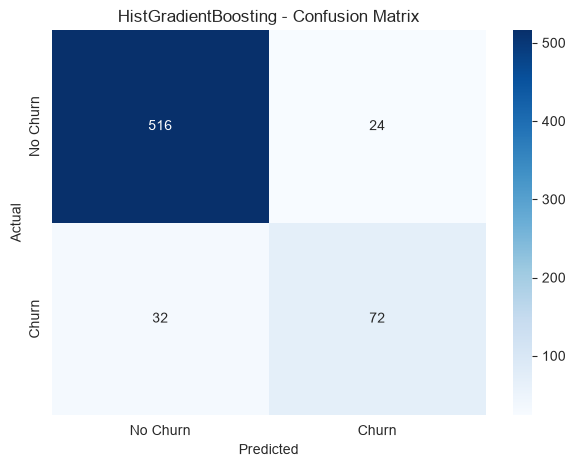

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_hgb = confusion_matrix(
    y_test,
    y_pred_hgb
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_hgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("HistGradientBoosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

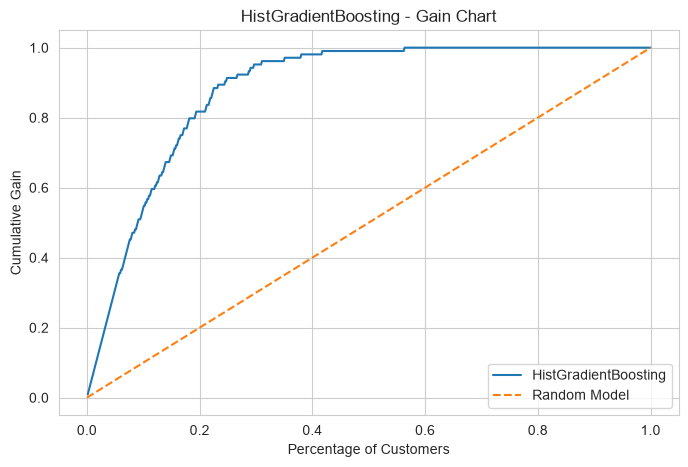

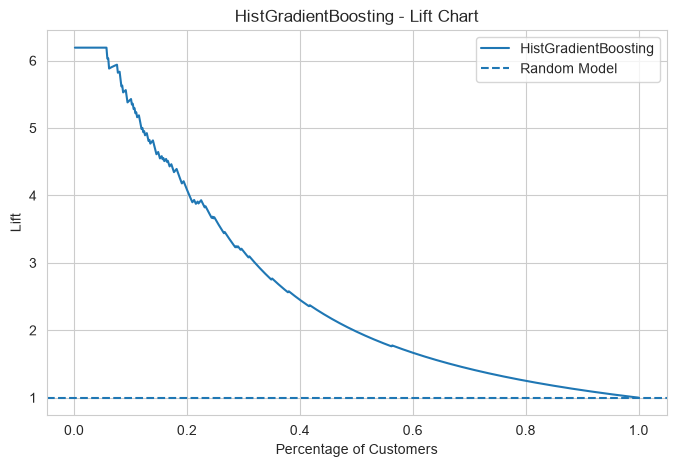

In [141]:
# Create dataframe
lift_gain_hgb = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Probability": y_proba_hgb
})

# Sort by predicted churn probability
lift_gain_hgb = lift_gain_hgb.sort_values(
    "Probability",
    ascending=False
).reset_index(drop=True)

# Cumulative calculations
lift_gain_hgb["Cumulative_Actual"] = (
    lift_gain_hgb["Actual"].cumsum()
)

total_churn_hgb = lift_gain_hgb["Actual"].sum()

lift_gain_hgb["Cumulative_Gain"] = (
    lift_gain_hgb["Cumulative_Actual"]
    / total_churn_hgb
)

lift_gain_hgb["Percentage_Sample"] = (
    np.arange(1, len(lift_gain_hgb) + 1)
    / len(lift_gain_hgb)
)

lift_gain_hgb["Lift"] = (
    lift_gain_hgb["Cumulative_Gain"]
    / lift_gain_hgb["Percentage_Sample"]
)

# Gain Chart
plt.figure(figsize=(8, 5))

plt.plot(
    lift_gain_hgb["Percentage_Sample"],
    lift_gain_hgb["Cumulative_Gain"],
    label="HistGradientBoosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Model"
)

plt.xlabel("Percentage of Customers")
plt.ylabel("Cumulative Gain")
plt.title("HistGradientBoosting - Gain Chart")
plt.legend()
plt.grid(True)
plt.show()

# Lift Chart
plt.figure(figsize=(8, 5))

plt.plot(
    lift_gain_hgb["Percentage_Sample"],
    lift_gain_hgb["Lift"],
    label="HistGradientBoosting"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Random Model"
)

plt.xlabel("Percentage of Customers")
plt.ylabel("Lift")
plt.title("HistGradientBoosting - Lift Chart")
plt.legend()
plt.grid(True)
plt.show()

#### 14.7.1 HistGradientBoosting Hyperparameter Tuning

Randomized Search is used to identify a better combination of HistGradientBoosting hyperparameters.

Because churn is an imbalanced classification problem, `average_precision` (PR-AUC) is used as the tuning objective.


In [142]:
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)
from scipy.stats import randint, loguniform

hgb_param_distributions = {
    "classifier__max_iter": randint(200, 1201),
    "classifier__learning_rate": loguniform(0.01, 0.3),
    "classifier__max_leaf_nodes": randint(10, 101),
    "classifier__max_depth": [None, 3, 5, 7, 10, 15],
    "classifier__min_samples_leaf": randint(5, 101),
    "classifier__l2_regularization": loguniform(1e-8, 20)
}

hgb_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            random_state=RANDOM_STATE
        ))
    ]
)

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

hgb_random_search = RandomizedSearchCV(
    estimator=hgb_tuning_pipeline,
    param_distributions=hgb_param_distributions,
    n_iter=80,
    scoring="average_precision",
    cv=cv_strategy,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True
)

# HistGradientBoosting does not have class_weight,
# so sample weights are passed during fitting.
hgb_random_search.fit(
    X_train,
    y_train,
    classifier__sample_weight=sample_weights
)

print("HistGradientBoosting tuning completed.")

print("\nBest PR-AUC CV Score:")
print(hgb_random_search.best_score_)

print("\nBest Parameters:")
print(hgb_random_search.best_params_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
HistGradientBoosting tuning completed.

Best PR-AUC CV Score:
0.8338119373304096

Best Parameters:
{'classifier__l2_regularization': np.float64(0.7866344159072098), 'classifier__learning_rate': np.float64(0.11643458936511251), 'classifier__max_depth': 15, 'classifier__max_iter': 1070, 'classifier__max_leaf_nodes': 36, 'classifier__min_samples_leaf': 13}


In [143]:
# Best tuned model
best_hgb_model = hgb_random_search.best_estimator_

# Predictions
y_pred_hgb_tuned = np.asarray(
    best_hgb_model.predict(X_test)
).ravel()

y_proba_hgb_tuned = (
    best_hgb_model.predict_proba(X_test)[:, 1]
)

# Metrics
accuracy_hgb_tuned = accuracy_score(
    y_test,
    y_pred_hgb_tuned
)

precision_hgb_tuned = precision_score(
    y_test,
    y_pred_hgb_tuned,
    zero_division=0
)

recall_hgb_tuned = recall_score(
    y_test,
    y_pred_hgb_tuned,
    zero_division=0
)

f1_hgb_tuned = f1_score(
    y_test,
    y_pred_hgb_tuned,
    zero_division=0
)

roc_auc_hgb_tuned = roc_auc_score(
    y_test,
    y_proba_hgb_tuned
)

pr_auc_hgb_tuned = average_precision_score(
    y_test,
    y_proba_hgb_tuned
)

log_loss_hgb_tuned = log_loss(
    y_test,
    y_proba_hgb_tuned
)

brier_hgb_tuned = brier_score_loss(
    y_test,
    y_proba_hgb_tuned
)

# Confusion matrix
tn_hgb_tuned, fp_hgb_tuned, fn_hgb_tuned, tp_hgb_tuned = (
    confusion_matrix(
        y_test,
        y_pred_hgb_tuned
    ).ravel()
)

# Cost-sensitive evaluation
total_cost_hgb_tuned = (
    fp_hgb_tuned * COST_FALSE_POSITIVE +
    fn_hgb_tuned * COST_FALSE_NEGATIVE
)

# Final evaluation DataFrame
hgb_tuned_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score",
        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "True Positive (TP)",
        "False Positive Cost",
        "False Negative Cost",
        "Total Cost"
    ],
    "Value": [
        accuracy_hgb_tuned,
        precision_hgb_tuned,
        recall_hgb_tuned,
        f1_hgb_tuned,
        roc_auc_hgb_tuned,
        pr_auc_hgb_tuned,
        log_loss_hgb_tuned,
        brier_hgb_tuned,
        tn_hgb_tuned,
        fp_hgb_tuned,
        fn_hgb_tuned,
        tp_hgb_tuned,
        fp_hgb_tuned * COST_FALSE_POSITIVE,
        fn_hgb_tuned * COST_FALSE_NEGATIVE,
        total_cost_hgb_tuned
    ]
})

hgb_tuned_metrics_df

,Metric,Value
0,Accuracy,0.913043
1,Precision,0.766667
2,Recall,0.663462
3,F1-Score,0.711340
4,ROC-AUC,0.959313
5,PR-AUC,0.841801
6,Log Loss,0.305338
7,Brier Score,0.071342
8,True Negative (TN),519.000000
9,False Positive (FP),21.000000


In [144]:
hgb_baseline_vs_tuned = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Log Loss",
        "Brier Score"
    ],
    "Baseline": [
        accuracy_hgb,
        precision_hgb,
        recall_hgb,
        f1_hgb,
        roc_auc_hgb,
        pr_auc_hgb,
        log_loss_hgb,
        brier_hgb
    ],
    "Tuned": [
        accuracy_hgb_tuned,
        precision_hgb_tuned,
        recall_hgb_tuned,
        f1_hgb_tuned,
        roc_auc_hgb_tuned,
        pr_auc_hgb_tuned,
        log_loss_hgb_tuned,
        brier_hgb_tuned
    ]
})

hgb_baseline_vs_tuned["Improvement"] = (
    hgb_baseline_vs_tuned["Tuned"]
    -
    hgb_baseline_vs_tuned["Baseline"]
)

hgb_baseline_vs_tuned

,Metric,Baseline,Tuned,Improvement
0,Accuracy,0.913043,0.913043,0.000000
1,Precision,0.750000,0.766667,0.016667
2,Recall,0.692308,0.663462,-0.028846
3,F1-Score,0.720000,0.711340,-0.008660
4,ROC-AUC,0.956891,0.959313,0.002422
5,PR-AUC,0.839423,0.841801,0.002378
6,Log Loss,0.231656,0.305338,0.073682
7,Brier Score,0.065694,0.071342,0.005648


## 15. Final Model Comparison

All tuned classification models are compared using the most important metrics for the churn prediction problem.

Since the dataset is imbalanced, PR-AUC receives the highest weight, followed by Recall, F1-Score, ROC-AUC, and Precision.


- Higher is better → Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Lift, Gain, TN, TP
- Lower is better → Log Loss, Brier Score, FP, FN, Total Cost, Average Cost

In [ ]:
# FINAL MODEL COMPARISON - ALL 7 MODELS + OVERALL RANK

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix
)


# 1. ALL 7 TRAINED / TUNED MODELS

models = {
    "Logistic Regression": best_logistic_model,
    "Random Forest": best_rf_model,
    "XGBoost": best_xgb_model,
    "CatBoost": best_catboost_model,
    "LightGBM": best_lgbm_model,
    "Extra Trees": best_extra_trees_model,
    "HistGradientBoosting": best_hgb_model
}


# 2. CALCULATE ALL METRICS

results = []

for model_name, model in models.items():

    # Predictions
    y_pred = np.asarray(
        model.predict(X_test)
    ).ravel()

    # Probability of Churn = 1
    y_proba = model.predict_proba(X_test)[:, 1]

    # Basic Classification Metrics

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # Probability Metrics

    roc_auc = roc_auc_score(
        y_test,
        y_proba
    )

    pr_auc = average_precision_score(
        y_test,
        y_proba
    )

    log_loss_value = log_loss(
        y_test,
        y_proba
    )

    brier_score = brier_score_loss(
        y_test,
        y_proba
    )

    # Confusion Matrix

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # Lift & Gain @ 10%

    temp_df = pd.DataFrame({
        "Actual": np.asarray(y_test),
        "Probability": y_proba
    })

    temp_df = temp_df.sort_values(
        "Probability",
        ascending=False
    ).reset_index(drop=True)

    top_10_count = max(
        1,
        int(np.ceil(len(temp_df) * 0.10))
    )

    top_10 = temp_df.iloc[:top_10_count]

    overall_churn_rate = temp_df["Actual"].mean()

    top_10_churn_rate = top_10["Actual"].mean()

    # Lift @ 10%
    lift_at_10 = (
        top_10_churn_rate / overall_churn_rate
        if overall_churn_rate > 0
        else np.nan
    )

    # Gain @ 10%
    total_churners = temp_df["Actual"].sum()

    gain_at_10 = (
        (top_10["Actual"].sum() / total_churners) * 100
        if total_churners > 0
        else np.nan
    )

    # Cost-Sensitive Metrics

    # Use the cost values already defined in your notebook
    fp_cost = fp * COST_FALSE_POSITIVE
    fn_cost = fn * COST_FALSE_NEGATIVE

    total_cost = fp_cost + fn_cost

    average_cost = total_cost / len(y_test)

    # Store Results

    results.append({
        "Model": model_name,

        # Classification Metrics
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,

        # Probability Metrics
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Log Loss": log_loss_value,
        "Brier Score": brier_score,

        # Confusion Matrix
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,

        # Lift & Gain
        "Lift @ 10%": lift_at_10,
        "Gain @ 10%": gain_at_10,

        # Cost Metrics
        "FP Cost": fp_cost,
        "FN Cost": fn_cost,
        "Total Cost": total_cost,
        "Average Cost": average_cost
    })


# 3. CREATE COMPARISON DATAFRAME

comparison_df = pd.DataFrame(results)


# 4. CALCULATE RANK FOR EACH METRIC

# Higher = Better
higher_is_better = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC",
    "TN",
    "TP",
    "Lift @ 10%",
    "Gain @ 10%"
]

# Lower = Better
lower_is_better = [
    "Log Loss",
    "Brier Score",
    "FP",
    "FN",
    "FP Cost",
    "FN Cost",
    "Total Cost",
    "Average Cost"
]


# 5. CREATE INDIVIDUAL METRIC RANKS

rank_columns = []

for metric in higher_is_better:

    rank_col = metric + " Rank"

    comparison_df[rank_col] = comparison_df[
        metric
    ].rank(
        ascending=False,
        method="min"
    )

    rank_columns.append(rank_col)


for metric in lower_is_better:

    rank_col = metric + " Rank"

    comparison_df[rank_col] = comparison_df[
        metric
    ].rank(
        ascending=True,
        method="min"
    )

    rank_columns.append(rank_col)


# 6. CALCULATE OVERALL RANK

comparison_df["Average Rank"] = comparison_df[
    rank_columns
].mean(axis=1)

comparison_df["Overall Rank"] = comparison_df[
    "Average Rank"
].rank(
    ascending=True,
    method="min"
).astype(int)


# 7. SORT BY OVERALL RANK

comparison_df = comparison_df.sort_values(
    ["Overall Rank", "Average Rank"]
).reset_index(drop=True)


# 8. ROUND VALUES

comparison_df = comparison_df.round(4)


# 9. FINAL TABLE - ONLY RESULTS + OVERALL RANK

final_comparison = comparison_df[
    [
        "Overall Rank",
        "Model",

        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",

        "ROC-AUC",
        "PR-AUC",

        "Log Loss",
        "Brier Score",

        "TN",
        "FP",
        "FN",
        "TP",

        "Lift @ 10%",
        "Gain @ 10%",

        "FP Cost",
        "FN Cost",
        "Total Cost",
        "Average Cost",

        "Average Rank"
    ]
].copy()


# 10. DISPLAY FINAL COMPARISON

display(final_comparison)

,Overall Rank,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Log Loss,Brier Score,TN,FP,FN,TP,Lift @ 10%,Gain @ 10%,FP Cost,FN Cost,Total Cost,Average Cost,Average Rank
0,1,CatBoost,0.9224,0.7935,0.7019,0.7449,0.9621,0.8619,0.2076,0.0600,521,19,31,73,5.7160,57.6923,19,155,174,0.2702,2.3333
1,2,Random Forest,0.9146,0.8182,0.6058,0.6961,0.9629,0.8544,0.1680,0.0548,526,14,41,63,5.6207,56.7308,14,205,219,0.3401,2.6111
2,3,LightGBM,0.9146,0.7952,0.6346,0.7059,0.9616,0.8380,0.2948,0.0688,523,17,38,66,5.5254,55.7692,17,190,207,0.3214,3.7222
3,4,XGBoost,0.9130,0.8077,0.6058,0.6923,0.9608,0.8489,0.2044,0.0604,525,15,41,63,5.5254,55.7692,15,205,220,0.3416,3.8889
4,5,Extra Trees,0.9146,0.8451,0.5769,0.6857,0.9467,0.8267,0.2020,0.0613,529,11,44,60,5.5254,55.7692,11,220,231,0.3587,4.0000
5,6,HistGradientBoosting,0.9130,0.7667,0.6635,0.7113,0.9593,0.8418,0.3053,0.0713,519,21,35,69,5.5254,55.7692,21,175,196,0.3043,4.1667
6,7,Logistic Regression,0.8913,0.7742,0.4615,0.5783,0.8864,0.6858,0.2793,0.0818,526,14,56,48,4.7633,48.0769,14,280,294,0.4565,6.0000


### 15.1 Model Comparision Visualization

- Higher is better → Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Lift, Gain, TN, TP
- Lower is better → Log Loss, Brier Score, FP, FN, Total Cost, Average Cost

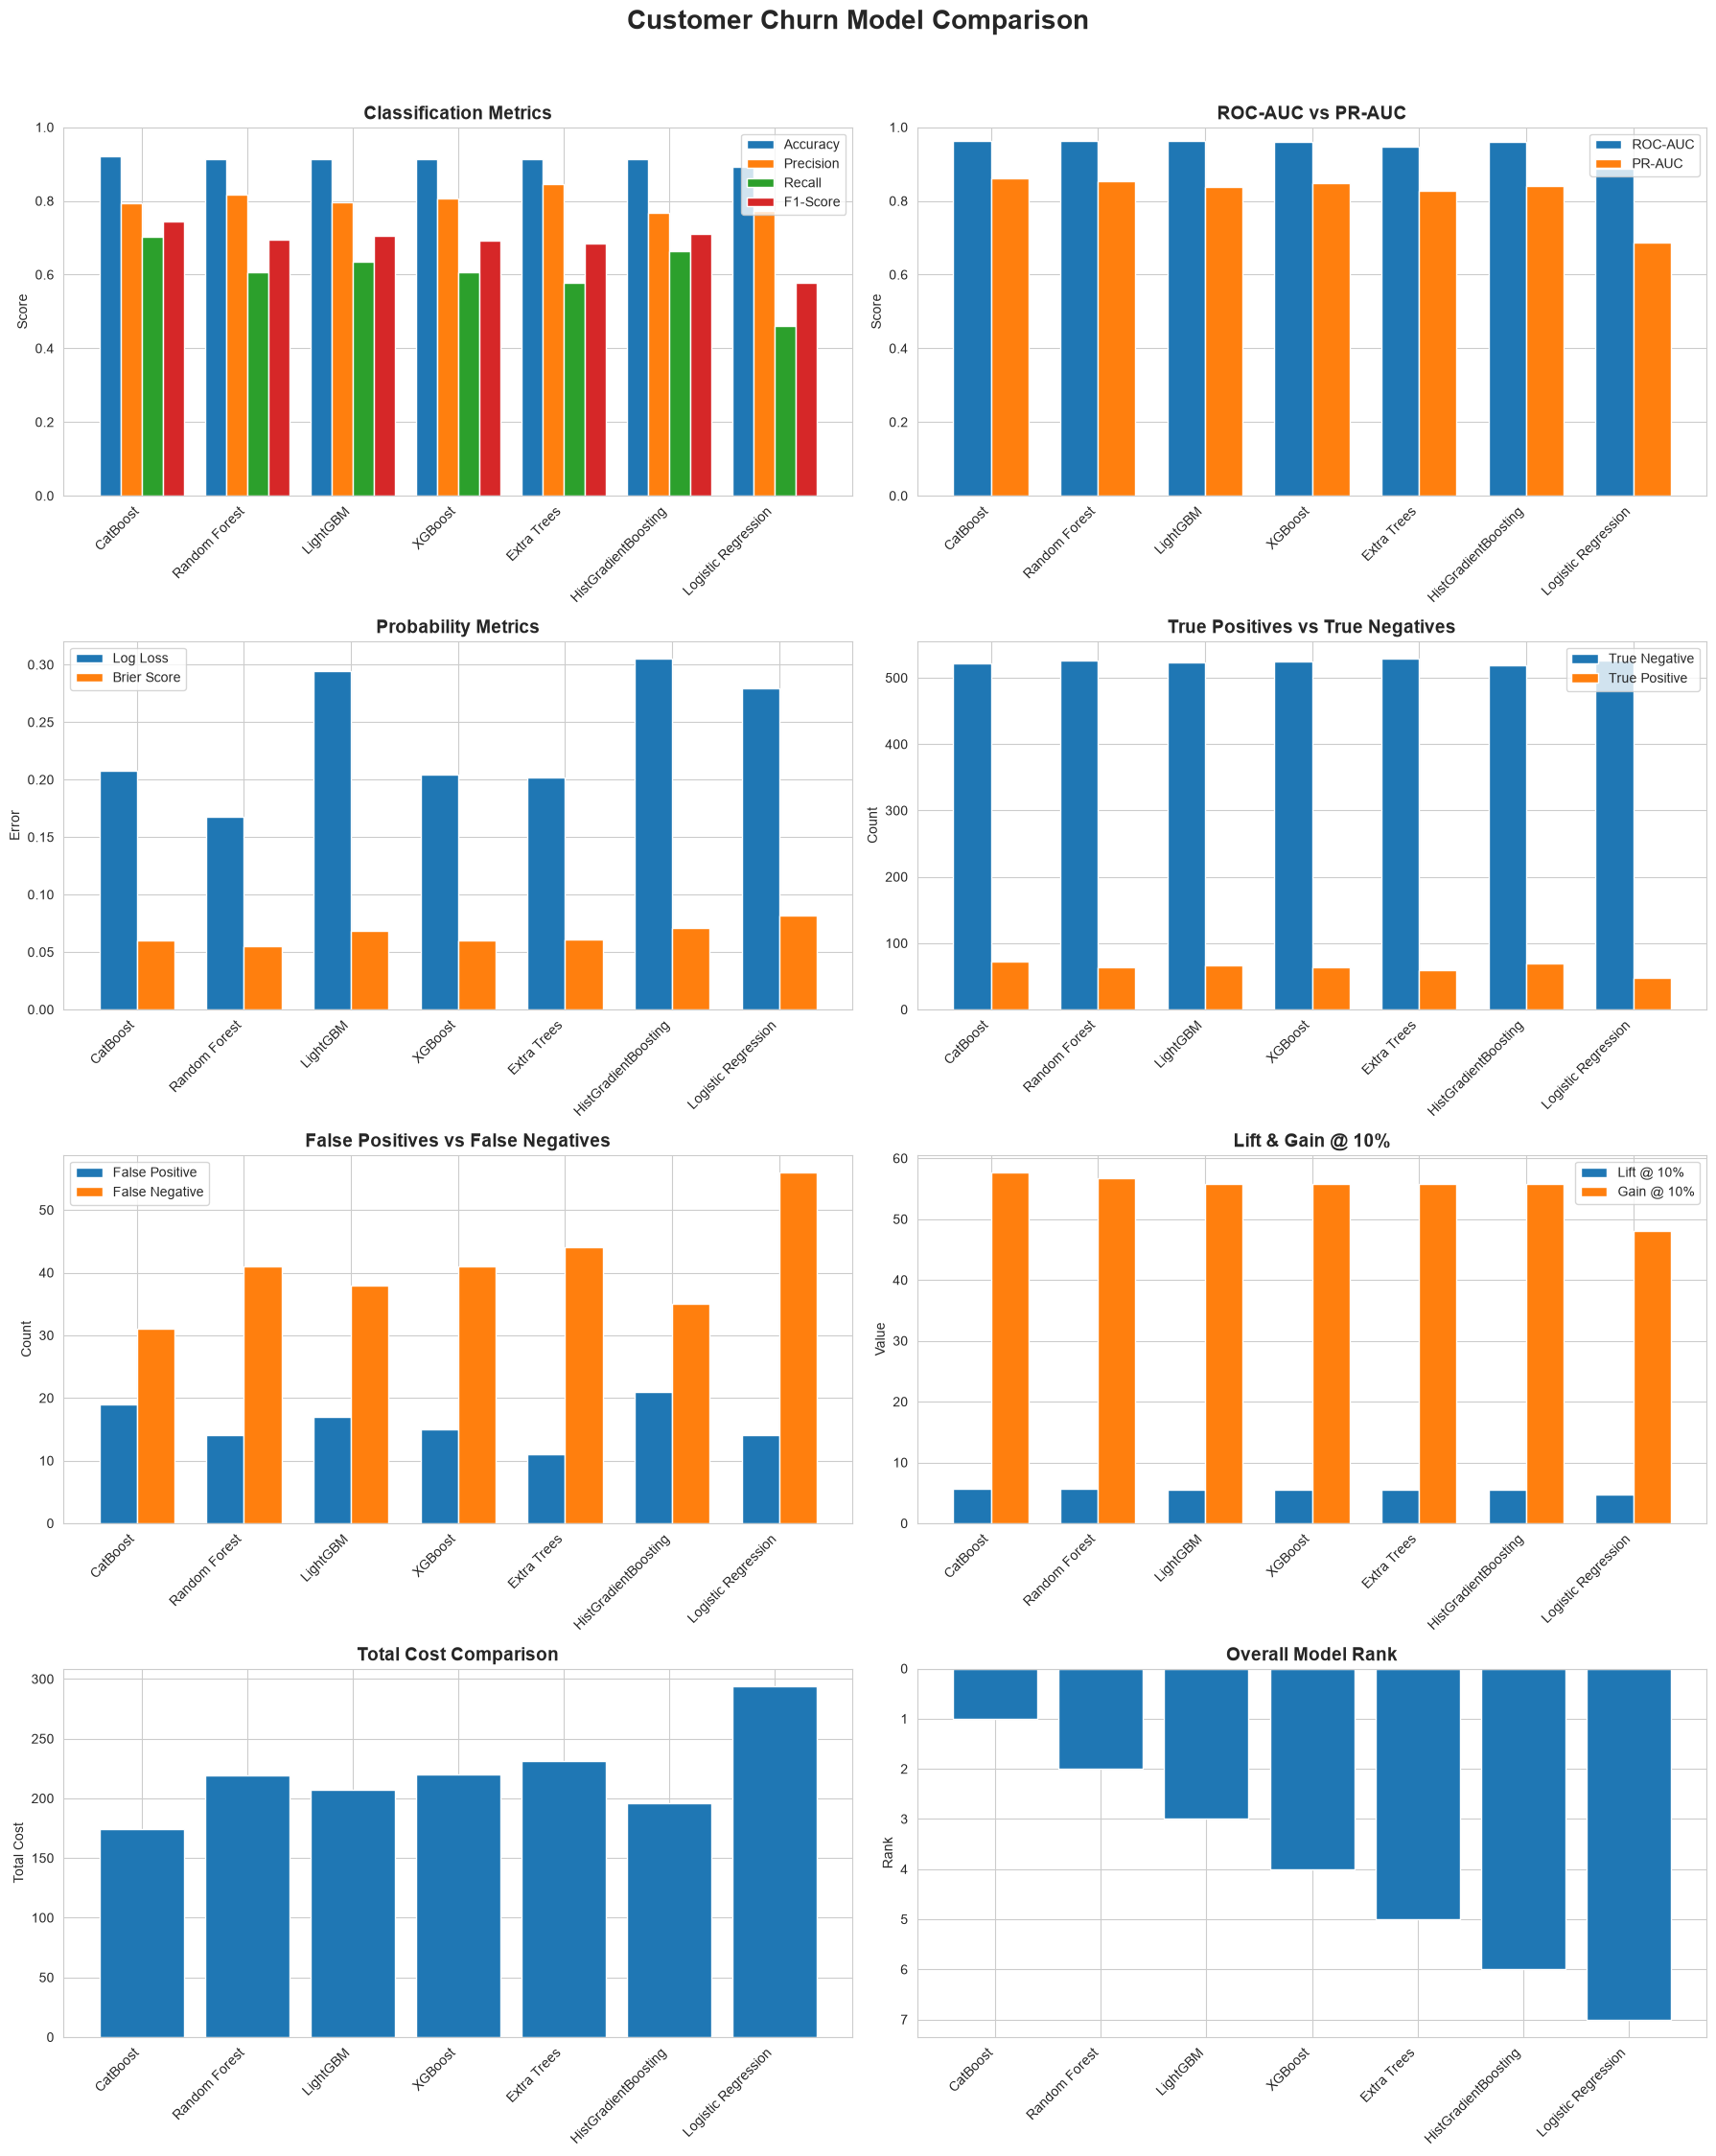

In [156]:
# MODEL COMPARISON VISUALIZATION - SUBPLOTS

import matplotlib.pyplot as plt
import numpy as np

# Use the final comparison dataframe created earlier
plot_df = final_comparison.copy()

# Sort models by Overall Rank
plot_df = plot_df.sort_values("Overall Rank")


# Create 4 x 2 subplot layout

fig, axes = plt.subplots(
    4, 2,
    figsize=(18, 22)
)

axes = axes.flatten()


# 1. Classification Metrics

metrics_1 = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

x = np.arange(len(plot_df))
width = 0.2

for i, metric in enumerate(metrics_1):

    axes[0].bar(
        x + (i - 1.5) * width,
        plot_df[metric],
        width,
        label=metric
    )

axes[0].set_title(
    "Classification Metrics",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_ylabel("Score")
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    plot_df["Model"],
    rotation=45,
    ha="right"
)

axes[0].set_ylim(0, 1)
axes[0].legend()


# 2. ROC-AUC & PR-AUC

x = np.arange(len(plot_df))
width = 0.35

axes[1].bar(
    x - width / 2,
    plot_df["ROC-AUC"],
    width,
    label="ROC-AUC"
)

axes[1].bar(
    x + width / 2,
    plot_df["PR-AUC"],
    width,
    label="PR-AUC"
)

axes[1].set_title(
    "ROC-AUC vs PR-AUC",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_ylabel("Score")
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    plot_df["Model"],
    rotation=45,
    ha="right"
)

axes[1].set_ylim(0, 1)
axes[1].legend()


# 3. Log Loss & Brier Score

axes[2].bar(
    x - width / 2,
    plot_df["Log Loss"],
    width,
    label="Log Loss"
)

axes[2].bar(
    x + width / 2,
    plot_df["Brier Score"],
    width,
    label="Brier Score"
)

axes[2].set_title(
    "Probability Metrics",
    fontsize=14,
    fontweight="bold"
)

axes[2].set_ylabel("Error")
axes[2].set_xticks(x)
axes[2].set_xticklabels(
    plot_df["Model"],
    rotation=45,
    ha="right"
)

axes[2].legend()


# 4. Confusion Matrix - TP & TN

axes[3].bar(
    x - width / 2,
    plot_df["TN"],
    width,
    label="True Negative"
)

axes[3].bar(
    x + width / 2,
    plot_df["TP"],
    width,
    label="True Positive"
)

axes[3].set_title(
    "True Positives vs True Negatives",
    fontsize=14,
    fontweight="bold"
)

axes[3].set_ylabel("Count")
axes[3].set_xticks(x)
axes[3].set_xticklabels(
    plot_df["Model"],
    rotation=45,
    ha="right"
)

axes[3].legend()


# 5. False Positives & False Negatives

axes[4].bar(
    x - width / 2,
    plot_df["FP"],
    width,
    label="False Positive"
)

axes[4].bar(
    x + width / 2,
    plot_df["FN"],
    width,
    label="False Negative"
)

axes[4].set_title(
    "False Positives vs False Negatives",
    fontsize=14,
    fontweight="bold"
)

axes[4].set_ylabel("Count")
axes[4].set_xticks(x)
axes[4].set_xticklabels(
    plot_df["Model"],
    rotation=45,
    ha="right"
)

axes[4].legend()


# 6. Lift & Gain @ 10%

axes[5].bar(
    x - width / 2,
    plot_df["Lift @ 10%"],
    width,
    label="Lift @ 10%"
)

axes[5].bar(
    x + width / 2,
    plot_df["Gain @ 10%"],
    width,
    label="Gain @ 10%"
)

axes[5].set_title(
    "Lift & Gain @ 10%",
    fontsize=14,
    fontweight="bold"
)

axes[5].set_ylabel("Value")
axes[5].set_xticks(x)
axes[5].set_xticklabels(
    plot_df["Model"],
    rotation=45,
    ha="right"
)

axes[5].legend()


# 7. Cost Comparison

axes[6].bar(
    x,
    plot_df["Total Cost"]
)

axes[6].set_title(
    "Total Cost Comparison",
    fontsize=14,
    fontweight="bold"
)

axes[6].set_ylabel("Total Cost")
axes[6].set_xticks(x)
axes[6].set_xticklabels(
    plot_df["Model"],
    rotation=45,
    ha="right"
)


# 8. Overall Rank

axes[7].bar(
    x,
    plot_df["Overall Rank"]
)

axes[7].set_title(
    "Overall Model Rank",
    fontsize=14,
    fontweight="bold"
)

axes[7].set_ylabel("Rank")
axes[7].set_xticks(x)
axes[7].set_xticklabels(
    plot_df["Model"],
    rotation=45,
    ha="right"
)

# Rank 1 should appear at the top
axes[7].invert_yaxis()


# Overall Figure Formatting

fig.suptitle(
    "Customer Churn Model Comparison",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.show()

## 16. Final Model Selection

Based on the comparison table and ranking above, **CatBoost (tuned)** is the best-performing model. We select it as the final model to be saved and used for future predictions.


In [187]:
# Final selected model
final_model = best_catboost_model

print("Final model selected: CatBoost (Tuned)")
print(final_model)


Final model selected: CatBoost (Tuned)
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Tenure_Months',
                                                   'Auto_Renewal_Flag',
                                                   'Usage_Frequency',
                                                   'Days_Since_Last_Activity',
                                                   'Feature_Usage_Count',
                                                   'Avg_Session_Duration_Min',
                                                   'Monthly_Charges',
       

## 17. Feature Importance

Feature importance shows which features have the greatest influence on the final CatBoost model.

In [194]:
# Extract CatBoost classifier and preprocessor
catboost_classifier = final_model.named_steps["classifier"]
catboost_preprocessor = final_model.named_steps["preprocessor"]

# Feature names
feature_names = catboost_preprocessor.get_feature_names_out()

# Feature importance
importance = catboost_classifier.get_feature_importance()

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

display(feature_importance_df.head(15))

,Feature,Importance
12,num__Complaint_Count,27.449573
23,num__Charge_Difference,20.443005
10,num__Late_Payment_Count,7.512957
16,num__Loyalty_Program_Member,5.280928
4,num__Days_Since_Last_Activity,4.518409
14,num__Satisfaction_Score,4.057479
1,num__Tenure_Months,3.656813
59,cat__Payment_Risk_Low,2.654538
39,cat__Contract_Type_Annual,1.890517
17,num__Email_Open_Rate_Pct,1.774895


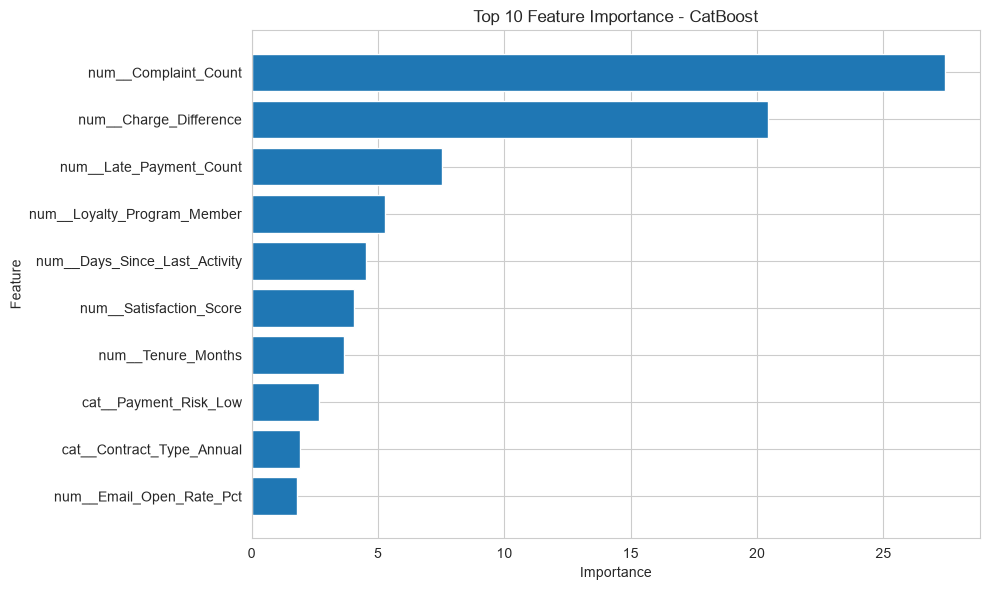

In [195]:
plt.figure(figsize=(10, 6))

top_features = feature_importance_df.head(10).sort_values("Importance")

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - CatBoost")

plt.tight_layout()
plt.show()

## 18. Threshold Analysis

Threshold analysis is used to find how different probability thresholds affect churn classification performance.

The analysis compares Precision, Recall and F1-Score across different thresholds.

In [191]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Churn probabilities from the selected CatBoost model
y_prob = final_model.predict_proba(X_test)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

,Threshold,Precision,Recall,F1-Score
0,0.3,1.0,1.0,1.0
1,0.4,1.0,1.0,1.0
2,0.5,1.0,1.0,1.0
3,0.6,1.0,1.0,1.0
4,0.7,1.0,1.0,1.0


## 19. Model Interpretation (SHAP Explainability)

SHAP is used to understand which features contribute to the model's churn predictions.

In [192]:
import shap

# Get CatBoost classifier and preprocessor
catboost_classifier = final_model.named_steps["classifier"]
catboost_preprocessor = final_model.named_steps["preprocessor"]

# Transform test data
X_test_transformed = catboost_preprocessor.transform(X_test)

# Create SHAP explainer
explainer = shap.TreeExplainer(catboost_classifier)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


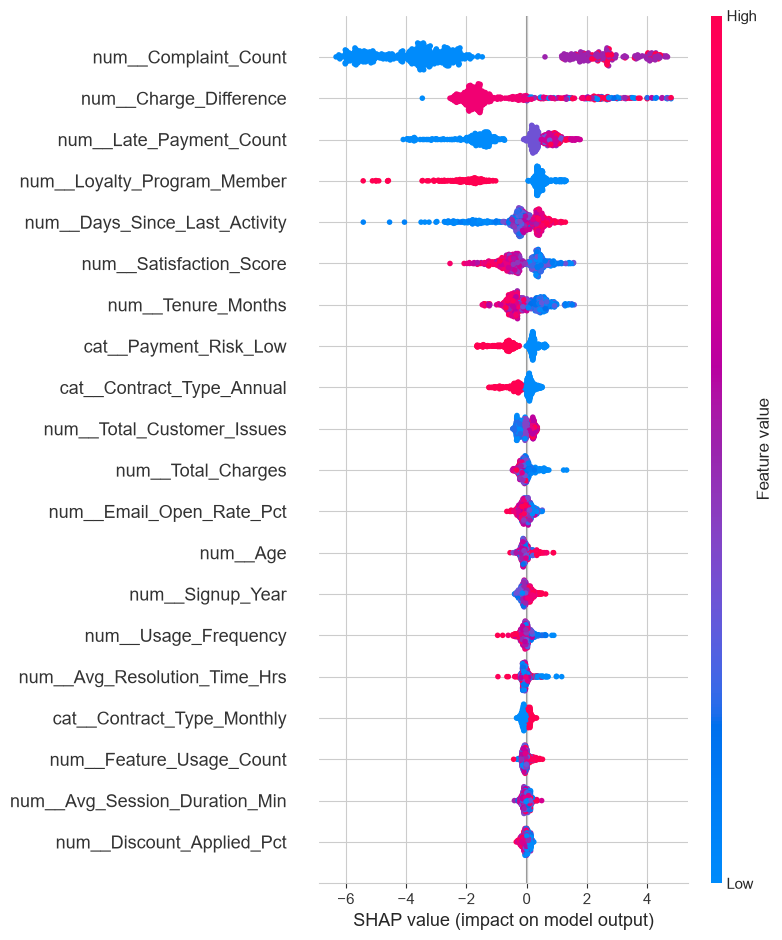

In [193]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=catboost_preprocessor.get_feature_names_out()
)

## 20. Retrain the Best Model - CatBoost Classifier

The best hyperparameters found during CatBoost tuning (`catboost_random_search.best_params_`) are reused to build a fresh pipeline, which is then fit on the **full dataset** (`X`, `y`) instead of just the training split. This gives the final model the benefit of every labeled record before it goes into production.


In [188]:
# Best hyperparameters found earlier for CatBoost
best_catboost_params = {
    k.replace("classifier__", ""): v
    for k, v in catboost_random_search.best_params_.items()
}

# Fresh pipeline using the same preprocessor + best CatBoost hyperparameters
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            CatBoostClassifier(
                **best_catboost_params,
                loss_function="Logloss",
                eval_metric="AUC",
                random_seed=RANDOM_STATE,
                verbose=False,
                thread_count=-1,
                auto_class_weights="Balanced"
            )
        )
    ]
)

# Retrain on the FULL dataset (X, y), not just X_train
final_model.fit(X, y)

print("Final CatBoost model retrained on the full dataset.")


Final CatBoost model retrained on the full dataset.


## 21. Final Churn Probability Prediction

The final model predicts the probability of churn for each customer and converts the probability into a churn prediction using the selected threshold.

In [198]:
# Final Churn Probability Prediction

# Predict churn probability
churn_probability = final_model.predict_proba(X_test)[:, 1]

# Apply threshold
threshold = 0.5
churn_prediction = (churn_probability >= threshold).astype(int)

# Create customer names
customer_names = [f"Customer {i+1}" for i in range(len(X_test))]

# Create final output
final_predictions = pd.DataFrame({
    "Customer": customer_names,
    "Churn Probability": (churn_probability * 100).round(2),
    "Predicted Churn": np.where(
        churn_prediction == 1,
        "Churn",
        "No Churn"
    )
})

display(final_predictions.head(10))

,Customer,Churn Probability,Predicted Churn
0,Customer 1,0.01,No Churn
1,Customer 2,0.00,No Churn
2,Customer 3,0.02,No Churn
3,Customer 4,0.00,No Churn
4,Customer 5,0.02,No Churn
5,Customer 6,0.00,No Churn
6,Customer 7,0.14,No Churn
7,Customer 8,0.06,No Churn
8,Customer 9,0.01,No Churn
9,Customer 10,99.26,Churn


## 22. Save the Final Model

The retrained pipeline (preprocessing + CatBoost classifier) is saved as a single file using `joblib`, so future predictions on new raw data can be made directly, without repeating any preprocessing steps by hand.


In [189]:
import joblib

model_filename = "catboost_churn_model.pkl"
joblib.dump(final_model, model_filename)

print(f"Final model saved successfully as '{model_filename}'")


Final model saved successfully as 'catboost_churn_model.pkl'
